In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import copy
from matplotlib import pyplot
from matplotlib import colors
from matplotlib import font_manager
import matplotlib.ticker as mticker
import numpy
import pandas
from PIL import Image
import random
import xarray as xr

In [2]:
numpy.seterr(invalid="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## Build Game Board

In [3]:
# Define map bounds
Min_Lon = 98
Max_Lon = 160
Min_Lat = 0
Max_Lat = 44

In [4]:
# Create initial map
def Initial_Map(Axis, Min_Lon, Max_Lon, Min_Lat, Max_Lat):
    pyplot.xlim(Min_Lon, Max_Lon)
    pyplot.ylim(Min_Lat, Max_Lat)
    Axis.set_xticks(numpy.arange(100,170,10))
    Axis.set_yticks(numpy.arange(0,50,10))
    Gridline_Major = Axis.gridlines(crs=ccrs.PlateCarree(), linewidth=1.5, color='darkgrey', linestyle='-')
    Gridline_Major.xlocator = mticker.FixedLocator(numpy.arange(100,170,10))
    Gridline_Major.ylocator = mticker.FixedLocator(numpy.arange(0,50,10))
    Gridline_Minor = Axis.gridlines(crs=ccrs.PlateCarree(), linewidth=1, color='darkgrey', linestyle='-')
    Gridline_Minor.xlocator = mticker.FixedLocator(numpy.arange(Min_Lon,Max_Lon,2))
    Gridline_Minor.ylocator = mticker.FixedLocator(numpy.arange(Min_Lat,Max_Lat,2))

In [5]:
# Open map grid file
Map_DF = pandas.read_csv("Map_Pacific.csv", index_col=0)
Map_DF.index = Map_DF.index.astype(int)
Map_DF.columns = Map_DF.columns.astype(int)
Map_Grid = Map_DF.values.astype(int)
Lat_Vals = Map_DF.index.astype(float)
Lon_Vals = Map_DF.columns.astype(float)
Lon_Grid, Lat_Grid = numpy.meshgrid(Lon_Vals, Lat_Vals)

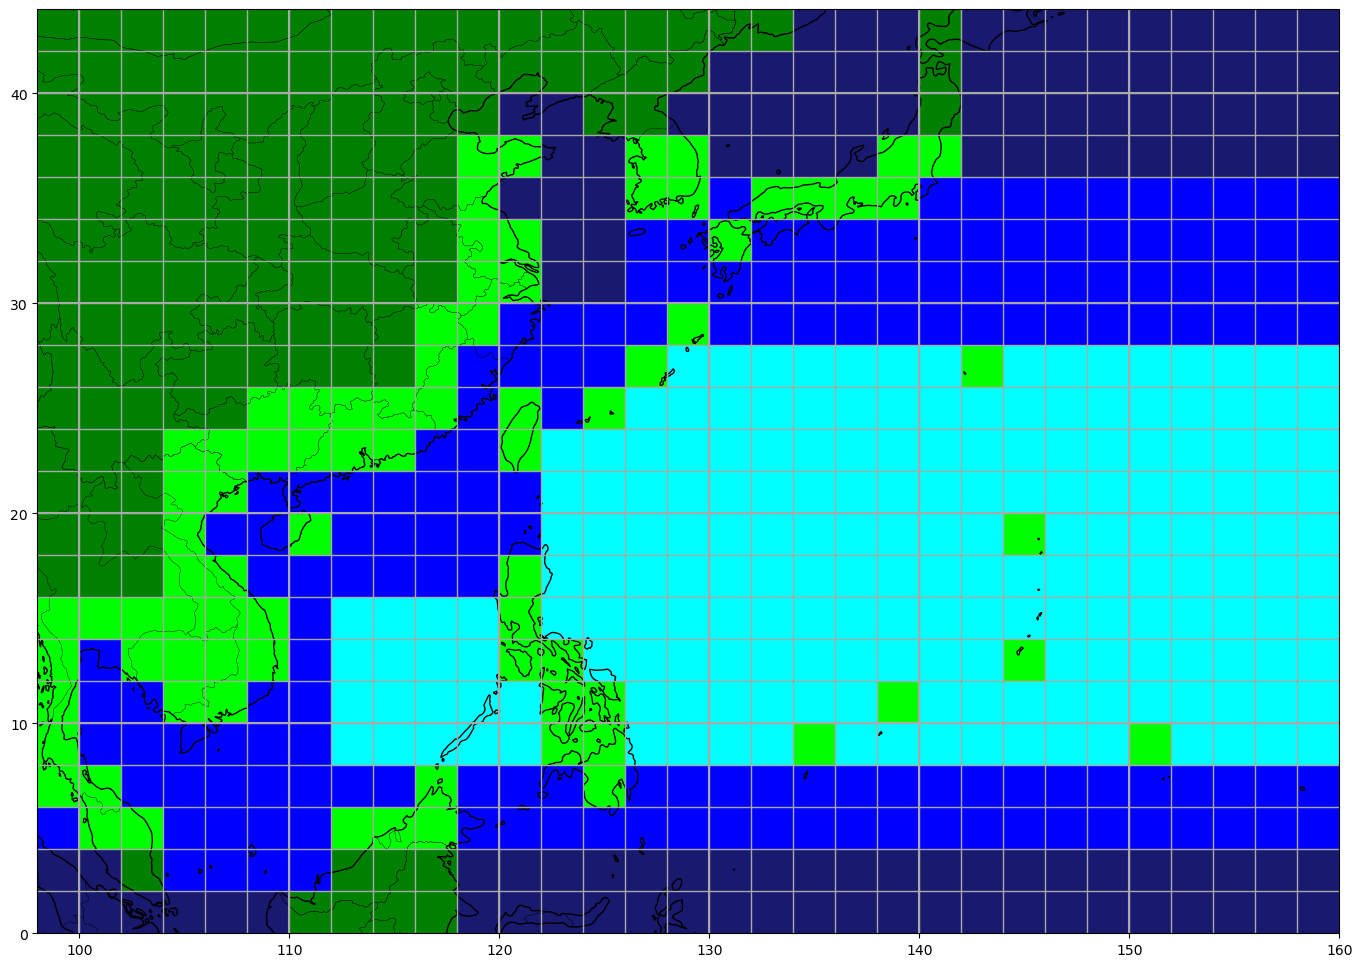

In [6]:
# Plot initial map
Fig = pyplot.figure(figsize=(25,12))
Axis = Fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
Initial_Map(Axis, Min_Lon, Max_Lon, Min_Lat, Max_Lat)
C_Map = colors.ListedColormap(['aqua', 'blue', 'midnightblue', 'lime', 'green'])
Axis.pcolormesh(Lon_Grid, Lat_Grid, Map_Grid, cmap=C_Map, shading='auto', vmin=1, vmax=5)
Axis.coastlines()
Axis.add_feature(cfeature.BORDERS, linewidth=0.3)
Axis.add_feature(cfeature.STATES, linewidth=0.2)

In [7]:
# Open cities file
Cities_DF = pandas.read_csv("Cities_Pacific.csv")

# Open genesis points file
Genesis_DF = pandas.read_csv("Genesis_Pacific.csv")

In [8]:
# City plotting
def City_Plot(Axis, Lon, Lat, Type):
    if Type == "Town":
        Marker, Size, Colour = 'o', 80, 'red'
    elif Type == "Regular":
        Marker, Size, Colour = '^', 160, 'red'
    elif Type == "Metro":
        Marker, Size, Colour = 'p', 320, 'red'
    elif Type == "Mega":
        Marker, Size, Colour = '*', 728, 'red'
    elif Type == "Genesis":
        Marker, Size, Colour = 's', 48, 'gold'
    Axis.scatter(Lon, Lat, marker=Marker, s=Size, c=Colour)

In [9]:
# City labels
def City_Label(Axis, City, Loc, Lon, Lat, Col, Genesis):
    if Genesis == False:
        Size = 14
    else:
        Size = 25
    if Loc == 0:
        Axis.text(Lon, Lat-0.08, City, ha='center', va='center', fontdict={'size':Size}, color=Col)
    elif Loc == 1:
        Axis.text(Lon+0.95, Lat, City, ha='left', va='center', fontdict={'size':Size}, color=Col)
    elif Loc == 2:
        Axis.text(Lon, Lat-1.45, City, ha='center', va='center', fontdict={'size':Size}, color=Col)
    elif Loc == 3:
        Axis.text(Lon-0.95, Lat, City, ha='right', va='center', fontdict={'size':Size}, color=Col)
    elif Loc == 4:
        Axis.text(Lon, Lat+1.38, City, ha='center', va='center', fontdict={'size':Size}, color=Col)

In [10]:
# Legend
def Plot_Legend(Axis):
    Axis.scatter(0,0, marker='s', s=320, c='aqua', label='Zone A (Water)')
    Axis.scatter(0,0, marker='s', s=320, c='blue', label='Zone B (Water)')
    Axis.scatter(0,0, marker='s', s=320, c='midnightblue', label='Zone C (Water)')
    Axis.scatter(0,0, marker='s', s=320, c='lime', label='Zone D (Land)')
    Axis.scatter(0,0, marker='s', s=320, c='green', label='Zone E (Land)')
    Axis.scatter(0,0, marker='*', s=518, c='red', label='Megacity')
    Axis.scatter(0,0, marker='p', s=218, c='red', label='Metropolis')
    Axis.scatter(0,0, marker='^', s=138, c='red', label='Regular City')
    Axis.scatter(0,0, marker='o', s=80, c='red', label='Township')
    Axis.scatter(0,0, marker='s', s=48, c='gold', label='Genesis Points')
    pyplot.legend(loc=2, fontsize=15)

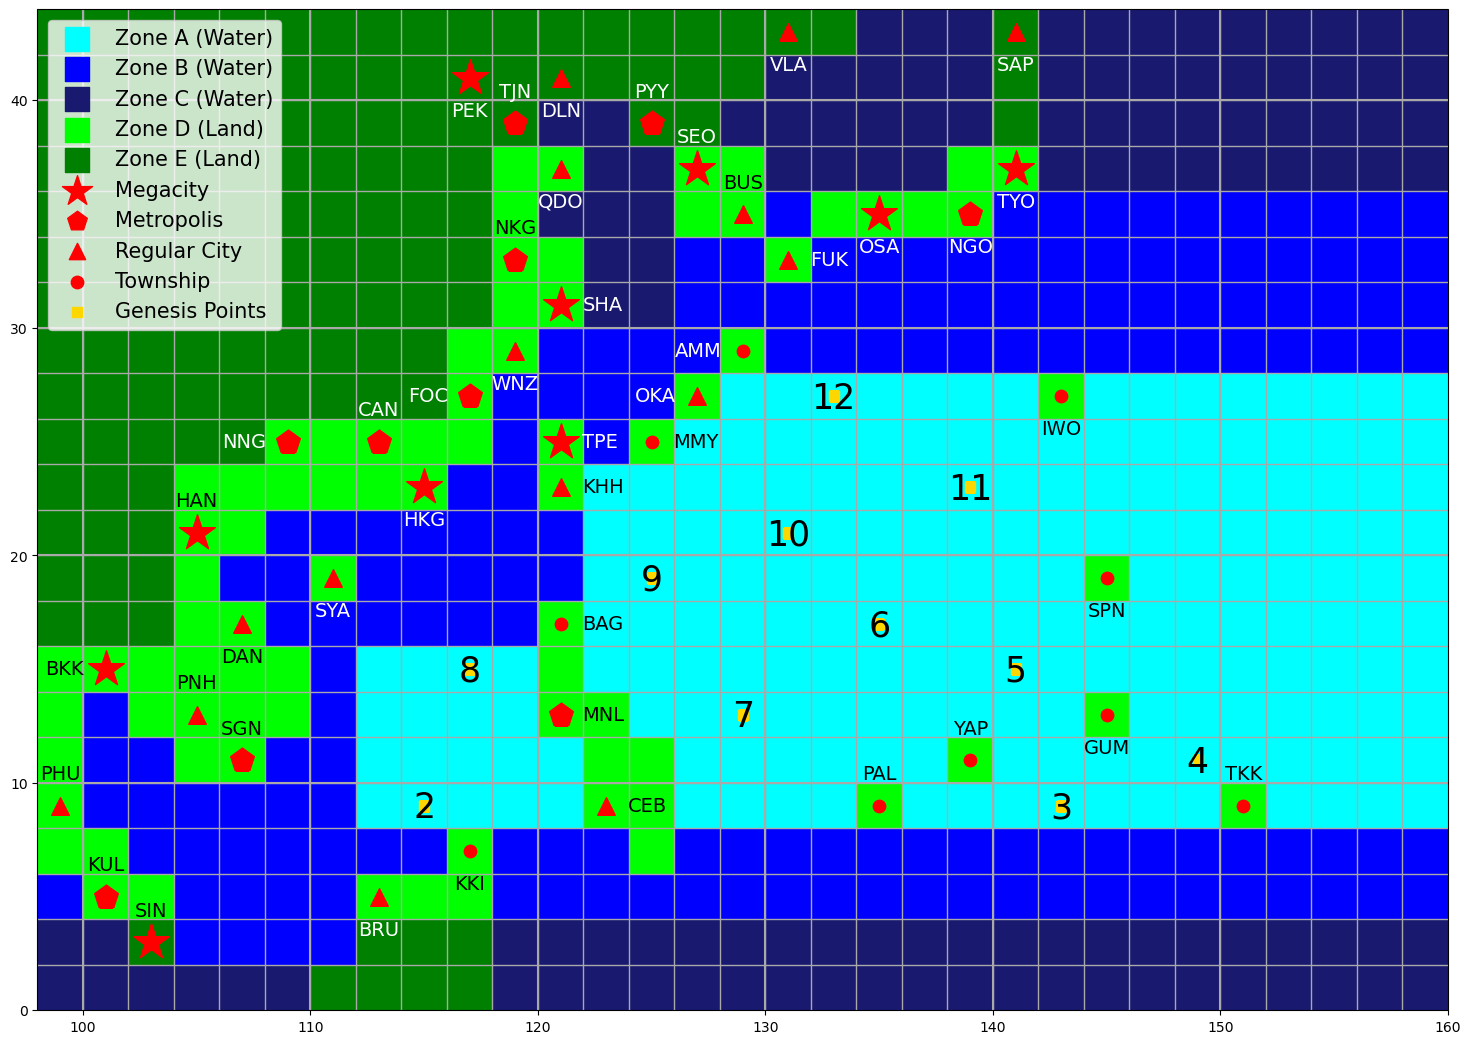

In [11]:
# Plot game board
def Plot_Board(Cities_DF, Genesis_DF, Lon_Grid, Lat_Grid, Map_Grid, C_Map):
    Fig = pyplot.figure(figsize=(25,13))
    Axis = Fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
    Initial_Map(Axis, Min_Lon, Max_Lon, Min_Lat, Max_Lat)
    Axis.pcolormesh(Lon_Grid, Lat_Grid, Map_Grid, cmap=C_Map, shading='auto', vmin=1, vmax=5)
    for i in range(len(Cities_DF)):
        City_Plot(Axis, Cities_DF["Lon"][i], Cities_DF["Lat"][i], Cities_DF["Type"][i])
        City_Label(Axis, Cities_DF["City"][i], Cities_DF["Label Loc"][i], Cities_DF["Lon"][i], Cities_DF["Lat"][i], Cities_DF["Label Colour"][i], False)
    for j in range(len(Genesis_DF)):
        City_Plot(Axis, Genesis_DF["Lon"][j], Genesis_DF["Lat"][j], "Genesis")
        City_Label(Axis, Genesis_DF["Point"][j], Genesis_DF["Label Loc"][j], Genesis_DF["Lon"][j], Genesis_DF["Lat"][j], Genesis_DF["Label Colour"][j], True)
    Plot_Legend(Axis)
    #Compass(Axis)
Plot_Board(Cities_DF, Genesis_DF, Lon_Grid, Lat_Grid, Map_Grid, C_Map)
Fig.savefig('Game_Map_Pacific', bbox_inches='tight')

## Functions

### Game Setup

In [12]:
# Roll dice
def Dice(n):
    Rolls = [numpy.random.randint(1, 6) for _ in range(n)]
    Result = sum(Rolls)
    return (Result)

In [13]:
# Assign genesis points and create player data dictionary
def Assign_Genesis_Points(Player_Names, Player_Colours, Genesis_DF, Map_DF):
    Taken_Positions = set()
    Player_Data = {}
    for Player in Player_Names:
        while True:
# Roll dice
            Roll = Dice(2)
            if Roll not in Taken_Positions:
                Taken_Positions.add(Roll)
                print (f"{Player} rolled {Roll} and is assigned genesis point {Roll}.")
# Find lat lon coordinates of genesis point
                Genesis_Row = Genesis_DF[Genesis_DF["Point"] == Roll]
                Lon = int(Genesis_Row.iloc[0]["Lon"])
                Lat = int(Genesis_Row.iloc[0]["Lat"])
                Zone = Map_DF.loc[Lat, Lon]
# Initialize player data
                Colour = Player_Colours[Player]
                Player_Data[Player] = {"Colour": Colour, "Order": 0, "Round": 0, "Status": "Initialize", \
                                       "Genesis Point": Roll, "Lon": Lon, "Lat": Lat, "Zone": Zone, \
                                       "Hand": [], "Cards Played This Round": [], "Max Cards": 3, "Remainder": 0, \
                                       "Intensity": 25, "Peak Intensity": 25, "ACE": 0, "Landfall Costs": 0, "Landfall Cities": []}
                break
# If roll result is already taken, roll again
            else:
                print (f"{Player} rolled {Roll}, but genesis point {Roll} is already taken. Rolling again...")
# Decide play order based on roll result
    Play_Order = sorted(Player_Names, key=lambda Name: Player_Data[Name]["Genesis Point"], reverse=True)
    Player_Data_Sorted = {Name: Player_Data[Name] for Name in Play_Order}
    for Order, Name in enumerate(Play_Order, start=1):
        Player_Data[Name]["Order"] = Order
    return (Play_Order, Player_Data_Sorted)

In [14]:
# Place pawn on board
def Place_Pawn(Lon, Lat, Colour):
    pyplot.scatter(Lon, Lat, s=383, c=Colour, edgecolors='black', linewidths=3, zorder=5)
# Add Halo Around Pawn
    pyplot.scatter(Lon, Lat, s=728, c='white', edgecolors='black', linewidths=2, zorder=4)

In [15]:
# Plot current board
def Plot_Current_Board(Player_Data):
    Plot_Board(Cities_DF, Genesis_DF, Lon_Grid, Lat_Grid, Map_Grid, C_Map)
    for Player in Player_Data:
        Place_Pawn(Player_Data[Player]["Lon"], Player_Data[Player]["Lat"], Player_Data[Player]["Colour"])
    pyplot.show()

In [16]:
# Shuffle cards
def Shuffle_Cards(Cards):
# Build full deck
    Deck = []
    for _, Row in Cards.iterrows():
        Deck.extend([Row["Card"]] * int(Row["Count"]))
# Shuffle deck
    random.shuffle(Deck)
    return (Deck)

In [17]:
# Deal cards
def Deal_Cards(Deck, Player_Data, Cards_Per_Player):
    for i in range(Cards_Per_Player):
        for Player in Player_Data:
            Player_Data[Player]["Hand"].append(Deck.pop())
    return (Deck)

### Saving Game State

In [18]:
# Save player data and game state history
def Save_State(Player_Data, Game_State, Player_Data_History, Game_State_History):
    Player_Data_History.append(copy.deepcopy(Player_Data))
    Game_State_History.append(copy.deepcopy(Game_State))

In [19]:
# Reset board
def Reset(Player_Data_History, Game_State_History):
    Player_Data = copy.deepcopy(Player_Data_History[0])
    Game_State = copy.deepcopy(Game_State_History[0])
    return (Player_Data, Game_State)

In [20]:
# Undo round
def Undo(Player_Data_History, Game_State_History):
    if len(Player_Data_History) > 1:
        Player_Data = copy.deepcopy(Player_Data_History[-1])
        Game_State = copy.deepcopy(Game_State_History[-1])
    else:
        Player_Data = copy.deepcopy(Player_Data_History[0])
        Game_State = copy.deepcopy(Game_State_History[0])
    return (Player_Data, Game_State)

### Running Each Round

In [35]:
# Function for each round of a player
def Run_Round(Round, Player_Pos, Player_Data, Game_State, Player_Data_History, Game_State_History):
# Initialize
    Game_State["Round"] = Round
    Game_State["Player Position"] = Player_Pos
    Game_State["Status"] = "Begin Round"
    Player_Name = Play_Order[Player_Pos-1]
    Player_Data[Player_Name]["Round"] = Round
    Player_Data[Player_Name]["Status"] = "Begin Round"
#
# Print initial info
    print (f"\n--- Round {Round}: {Player_Name}'s turn ---")
    Plot_Current_Board(Player_Data)
    print (f"Intensity: {Player_Data[Player_Name]["Intensity"]} knots")
    print (f"ACE: {Player_Data[Player_Name]["ACE"]} kJ")
    print (f"Landfall Costs: ${Player_Data[Player_Name]["Landfall Costs"]} M")
    print ("Hand:")
    for i, Card in enumerate(Player_Data[Player_Name]["Hand"]):
        print (f"{Card}")
#
# Draw cards
    if Round > 1:
        Draw_Cards(Player_Name, Player_Data, Game_State)
        Game_State["Status"] = "Drew Cards"
        Player_Data[Player_Name]["Status"] = "Drew Cards"
#
# Play cards
    Play_Cards(Player_Name, Player_Data, Game_State)
    Game_State["Status"] = "Played Cards"
    Player_Data[Player_Name]["Status"] = "Played Cards"
#
# End round
    End_Round(Player_Name, Player_Data, Game_State)
    Game_State["Status"] = "End Round"
    Player_Data[Player_Name]["Status"] = "End Round"
    Save_State(Player_Data, Game_State, Player_Data_History, Game_State_History)
#
# Plot current board
    Plot_Current_Board(Player_Data)

In [36]:
# Function for players to draw cards
def Draw_Cards(Player_Name, Player_Data, Game_State):
# Initialize
    Hand = Player_Data[Player_Name]["Hand"]
    Round = Game_State["Round"]
    Cards_Drawn = 0
    Action_Chosen = False
#
# Print current info
    print (f"\n--- Round {Round}: {Player_Name}'s draw phase ---")
    while Cards_Drawn < 2:
        if Action_Chosen == False:
            Decks = ["Movement Deck", "Intensity Deck", "Action Deck"]
        else:
            Decks = ["Movement Deck", "Intensity Deck"]
        for i, Deck in enumerate(Decks):
            print(f"{i}: {Deck} ({len(Game_State[Deck])} cards left)")
#
# Ask for input
        Index = Request_Index_Input("Choose a deck by index:", len(Decks)-1)
#
# Draw card
        Chosen_Deck = Decks[Index]
        Drawn_Card = Game_State[Chosen_Deck].pop(0)
        Hand.append(Drawn_Card)
        print (f"{Player_Name} drew: {Drawn_Card} from {Chosen_Deck}.")
        print ("")
        if Chosen_Deck == "Action Deck":
            Action_Chosen = True
        Cards_Drawn += 1

In [37]:
# Function for requesting index input
def Request_Index_Input(Input_Message, Max_Index):
    while True:
        Choice = input(Input_Message)
        try:
            Index = int(Choice)
        except ValueError:
            print ("Invalid input. Please enter a number.")
            continue
        if Index < 0 or Index > Max_Index:
            print ("Invalid index. Please try again.")
            continue
        return (Index)

In [38]:
# Function for players to play cards
def Play_Cards(Player_Name, Player_Data, Game_State):
# Initialize
    Hand = Player_Data[Player_Name]["Hand"]
    Round = Game_State["Round"]
    Played_This_Round = []
    Player_Data[Player_Name]["Cards Played This Round"] = Played_This_Round
    Max_Cards = 3
    Player_Data[Player_Name]["Max Cards"] = Max_Cards
#
# Print current info
    while len(Played_This_Round) < Max_Cards:
        print (f"\n--- Round {Round}: {Player_Name}'s playing phase ---")
        print (f"Cards played this round: {len(Played_This_Round)} / {Max_Cards}")
#
# If no cards left
        if len(Hand) == 0:
            print ("No cards left in hand.")
            break
#
# Get playable indices
        Playable_Indices = [i for i, Card in enumerate(Hand) if Is_Card_Playable(Card, Player_Name, Player_Data, Game_State)]
        if len(Playable_Indices) == 0:
            print("No playable cards available.")
            break
#
# Print hand
        print ("Hand:")
        for i, Card in enumerate(Hand):
            if i in Playable_Indices:
                print (f"{i}: {Card}")
            else:
                print (f"{i}: {Card} (cannot play)")
#
# Passing is only allowed after at least 1 card played
        if len(Played_This_Round) >= 1:
            print ("Enter 'p' to pass.")
#
# Ask for input
        Choice = input(f"Choose a card by index to play: ")
        if Choice.lower() == "p":
            if len(Played_This_Round) >= 1:
                print (f"{Player_Name} passes.")
                break
            else:
                print ("You must play at least 1 card before passing.")
                continue
        try:
            Index = int(Choice)
        except ValueError:
            print ("Invalid input. Please enter a number or 'p'.")
            continue
        if Index < 0 or Index >= len(Hand):
            print ("Invalid index. Please try again.")
            continue
        Card = Hand[Index]
        if not Is_Card_Playable(Card, Player_Name, Player_Data, Game_State):
            print (f"{Card} cannot currently be played. Please try again.")
            continue
#
# Play card
        Played_Card = Hand.pop(Index)
        Played_This_Round.append(Played_Card)
        print (f"{Player_Name} played: {Played_Card}")
        print ("")
        Find_Card_Type(Played_Card, Player_Name, Player_Data, Game_State, True)

In [39]:
# Function to find card type
def Find_Card_Type(Card_Name, Player_Name, Player_Data, Game_State, Play_Card):
    Card_Type, Card_Info = Card_Lookup[Card_Name]
# Play movement card
    if Card_Type == "Movement":
        if Play_Card == True:
            Play_Movement_Cards(Card_Name, Card_Info, Player_Name, Player_Data)
        Game_State["Movement Discard"].append(Card_Name)
# Play intensity card
    elif Card_Type == "Intensity":
        if Play_Card == True:
            Play_Intensity_Cards(Card_Name, Card_Info, Player_Name, Player_Data)
        Game_State["Intensity Discard"].append(Card_Name)
# Play action card
    elif Card_Type == "Action":
        if Play_Card == True:
            Play_Action_Cards(Card_Name, Card_Info, Player_Name, Player_Data, Game_State)
        Game_State["Action Discard"].append(Card_Name)

### Playing Movement Cards

In [40]:
# Function for playing movement cards
def Play_Movement_Cards(Card_Name, Card_Info, Player_Name, Player_Data):
# Find movement velocity
    if Card_Info.iloc[0]["Roll"] == False and Card_Info.iloc[0]["Option"] == False:
        Lon_Change = (Card_Info.iloc[0]["E"] - Card_Info.iloc[0]["W"]) * 2
        Lat_Change = (Card_Info.iloc[0]["N"] - Card_Info.iloc[0]["S"]) * 2
# Roll dice to find movement velocity
    elif Card_Info.iloc[0]["Roll"] == True:
        Roll = Dice(1)
        Lon_Change = (Card_Info.iloc[0]["E"] - Card_Info.iloc[0]["W"]) * 2 * Roll
        Lat_Change = (Card_Info.iloc[0]["N"] - Card_Info.iloc[0]["S"]) * 2 * Roll
        print (f"{Player_Name} rolled {Roll}: {Card_Name[0]} {Roll}")
# Movement wildcards: ask player to choose movement direction
    elif Card_Info.iloc[0]["Option"] == True:
        if Card_Name == "W/E 1":
            Lon_Change, Lat_Change = Request_Wildcard_Input("Choose W or E: ", ["W", "E"])
        elif Card_Name == "N/S 1":
            Lon_Change, Lat_Change = Request_Wildcard_Input("Choose N or S: ", ["N", "S"])
        elif Card_Name == "W/E/N/S 1":
            Lon_Change, Lat_Change = Request_Wildcard_Input("Choose W, E, N or S: ", ["W", "E", "N", "S"])
#
# Move storm
    Player_Data[Player_Name]["Lon"] += Lon_Change
    Player_Data[Player_Name]["Lat"] += Lat_Change
    Player_Data[Player_Name]["Zone"] = Map_DF.loc[Player_Data[Player_Name]["Lat"], Player_Data[Player_Name]["Lon"]]
#
# Plot current board
    Plot_Current_Board(Player_Data)
#
# Detect landfall
    Landfall_Row = Cities_DF[(Cities_DF["Lon"] == Player_Data[Player_Name]["Lon"]) & (Cities_DF["Lat"] == Player_Data[Player_Name]["Lat"])]
    if len(Landfall_Row) > 0:
        Landfall(Player_Name, Player_Data, Game_State, Landfall_Row)

In [41]:
# Movement wildcards choice
def Movement_Choice(Choice):
    if Choice == "W":
        Lon_Change, Lat_Change = -2, 0
    elif Choice == "E":
        Lon_Change, Lat_Change = 2, 0
    elif Choice == "N":
        Lon_Change, Lat_Change = 0, 2
    elif Choice == "S":
        Lon_Change, Lat_Change = 0, -2
    return (Lon_Change, Lat_Change)

In [42]:
# Function for requesting movement wildcard input
def Request_Wildcard_Input(Input_Message, Options):
    while True:
        Choice = input(Input_Message)
        if Choice in Options:
            Lon_Change, Lat_Change = Movement_Choice(Choice)
            return (Lon_Change, Lat_Change)
        else:
            print ("Invalid choice. Please try again.")

In [43]:
# Function for landfall
def Landfall(Player_Name, Player_Data, Game_State, Landfall_Row):
    Landfall_City = Landfall_Row.iloc[0]["City"]
# Calculate landfall cost
    Landfall_Cost = Player_Data[Player_Name]["Intensity"] * Landfall_Row.iloc[0]["Landfall Cost per kt"]
# If player has never made landfall at this city yet
    if Landfall_City not in Player_Data[Player_Name]["Landfall Cities"]:
# If remaining city budget less than landfall cost
        if Game_State["Cities Budget"][Landfall_City] < Landfall_Cost:
            Landfall_Cost = Game_State["Cities Budget"][Landfall_City]
# Deduct landfall cost from city budget
        Game_State["Cities Budget"][Landfall_City] -= Landfall_Cost
# Add landfall cost to player
        Player_Data[Player_Name]["Landfall Costs"] += Landfall_Cost
        Player_Data[Player_Name]["Landfall Cities"].append(Landfall_City)
# Print message
        City_Name = Landfall_Row.iloc[0]["City Name"]
        if Landfall_Cost > 0:
            print (f"{Player_Name} has made landfall at {Landfall_City} ({City_Name}) and gains ${Landfall_Cost}M!")
            print (f"Remaining budget of {Landfall_City} ({City_Name}): ${Game_State["Cities Budget"][Landfall_City]}M")
        else:
            print (f"{Player_Name} has made landfall at {Landfall_City} ({City_Name}), but {Landfall_City} is already bankrupt. $0M gained.")
#
# If player has already made landfall at this city
    else:
        City_Name = Landfall_Row.iloc[0]["City Name"]
        print (f"{Player_Name} has already made landfall at {Landfall_City} ({City_Name}) previously. $0M gained.")

### Playing Intensity Cards

In [44]:
# Function for playing intensity cards
def Play_Intensity_Cards(Card_Name, Card_Info, Player_Name, Player_Data):
# Find W/m^2 amount
    if Card_Info.iloc[0]["Roll"] == False:
        Wm2 = Card_Info.iloc[0]["W/m^2"]
# Roll dice to find W/m^2 amount
    else:
        Roll = Dice(1)
        Wm2 = Roll * 5
        print (f"{Player_Name} rolled {Roll}: + {Wm2} W/m^2")
#
# Get current intensity and zone
    Current_Intensity = Player_Data[Player_Name]["Intensity"]
    Rem = Player_Data[Player_Name]["Remainder"]
    Zone = Player_Data[Player_Name]["Zone"]
#
# Intensification
    Intensity, Remainder = Intensify(Current_Intensity, Wm2, Rem, Zone)
#
# Print message
    if Intensity > Current_Intensity:
        print (f"{Player_Name} has intensified to {Intensity} knots!")
    else:
        print (f"{Player_Name} remains at {Intensity} knots.")
#
# Store data
    Player_Data[Player_Name]["Intensity"] = Intensity
    if Intensity > Player_Data[Player_Name]["Peak Intensity"]:
        Player_Data[Player_Name]["Peak Intensity"] = Intensity
    Player_Data[Player_Name]["Remainder"] = Remainder

In [45]:
# Calculate intensification amount
def Intensify(Intensity, Wm2_New, Rem, Zone):
    Wm2 = Wm2_New + Rem
    while True:
        if Intensity < 65:
            if Zone <= 2:
                Cost = 5
            elif Zone == 3:
                Cost = 10
        elif Intensity < 100:
            Cost = 5 * Zone
        elif Intensity < 140:
            Cost = 5 * Zone + 5
        else:
            if Zone <= 2:
                Cost = 5 * Zone + 10
            elif Zone == 3:
                Cost = 30
        if Wm2 < Cost:
            break
        Intensity += 5
        Wm2 -= Cost
    return (Intensity, Wm2)

### Play Action Cards

In [46]:
# Function for playing action cards
def Play_Action_Cards(Card_Name, Card_Info, Player_Name, Player_Data, Game_State):
    if len (Player_Data[Player_Name]["Cards Played This Round"]) > 1:
        Prev_Card = Player_Data[Player_Name]["Cards Played This Round"][-2]
    Opponents = [Name for Name in Player_Data if Name != Player_Name]
#
# Rapid Intensification: Doubles the effect of an intensity card
    if Card_Name == "Rapid Intensification":
        Play_Intensity_Cards(Prev_Card, Card_Lookup[Prev_Card][1], Player_Name, Player_Data)
#
# Cyclone Express: Doubles the effect of a movement card
    elif Card_Name == "Cyclone Express":
        Play_Movement_Cards(Prev_Card, Card_Lookup[Prev_Card][1], Player_Name, Player_Data)
#
# Wrong Way Round: Move in the opposite direction of a movement card
    elif Card_Name == "Wrong Way Round":
        Card_Type, Card_Info = Card_Lookup[Prev_Card]
        Lon_Change = (Card_Info.iloc[0]["E"] - Card_Info.iloc[0]["W"]) * 2 * -2
        Lat_Change = (Card_Info.iloc[0]["N"] - Card_Info.iloc[0]["S"]) * 2 * -2
        Player_Data[Player_Name]["Lon"] += Lon_Change
        Player_Data[Player_Name]["Lat"] += Lat_Change
        Player_Data[Player_Name]["Zone"] = Map_DF.loc[Player_Data[Player_Name]["Lat"], Player_Data[Player_Name]["Lon"]]
        Plot_Current_Board(Player_Data)
        Landfall(Player_Name, Player_Data, Game_State, Cities_DF)
#
# Survival of the Fittest: Become immune from any weakening for the next 3 rounds
    elif Card_Name == "Survival of the Fittest":
        Game_State["Effects"].append({"Effect": Card_Name, "Type": "Positive", "Player": Player_Name, "Rounds Left": 3})
        print (f"{Player_Name} is immune from any weakening for the next 3 rounds.")
#
# Eyewall Replacement: Stop one opponent of your choice from intensifying for 3 rounds
    elif Card_Name == "Eyewall Replacement":
        for i, Opponent in enumerate(Opponents):
            print(f"{i}: {Opponent}")
        Index = Request_Index_Input("Select an opponent:", len(Opponents)-1)
        Opponent = Opponents[Index]
        Game_State["Effects"].append({"Effect": Card_Name, "Type": "Negative", "Player": Opponent, "Rounds Left": 3})
        print (f"{Opponent} will not be able to intensify for the next 3 rounds.")
#
# Vertical Wind Shear: Weaken every opponent by 10 knots
    elif Card_Name == "Vertical Wind Shear":
        for Opponent in Opponents:
            if Has_Effect(Opponent, "Survival of the Fittest", Game_State) == False:
                Player_Data[Opponent]["Intensity"] -= 10
                if Player_Data[Opponent]["Intensity"] < 25:
                    Player_Data[Opponent]["Intensity"] = 25
                print (f"{Opponent} has weakened to {Player_Data[Opponent]["Intensity"]} knots.")
#
# City Fortress: Protect one city of your choice from being impacted by any opponent for 3 rounds
    elif Card_Name == "City Fortress":
        while True:
            Choice = input(f"Select a city by inputting its three letter code:")
            if Choice in list(Cities_DF["City"]):
                Chosen_City = Choice
            else:
                print ("Invalid input. Please input the three letter code of a city on the map.")
                continue
        for Opponent in Opponents:
            Game_State["Effects"].append({"Effect": Card_Name, "Type": "Negative", "Player": Opponent, "City": Chosen_City, "Rounds Left": 3})
        print (f"{Choice} is protected from being impacted by any opponent for the next 3 rounds.")
#
# Expand Circulation: Impact one city of your choice at an adjacent grid box
    elif Card_Name == "Expand Circulation":
        # Find adjacent cities
        Adj_Cities = Find_Adj_Cities(Player_Data[Player_Name]["Lon"], Player_Data[Player_Name]["Lat"])
        # If more than one adjacent city, ask for input
        if len(Adj_Cities) > 1:
            Index = Request_Index_Input("Select a city by index:", len(Adj_Cities)-1)
            Chosen_City = Adj_Cities[Index]
        else:
            Chosen_City = Adj_Cities[0]
        Landfall_Row = Cities_DF[Cities_DF["City"] == Chosen_City]
        Landfall(Player_Name, Player_Data, Game_State, Landfall_Row)
#
# Random Teleportation: Roll the dice and teleport to that genesis point
    elif Card_Name == "Random Teleportation":
        Roll = Dice(2)
        Genesis_Row = Genesis_DF[Genesis_DF["Point"] == Roll]
        Player_Data[Player_Name]["Lon"] = int(Genesis_Row.iloc[0]["Lon"])
        Player_Data[Player_Name]["Lat"] = int(Genesis_Row.iloc[0]["Lat"])
        Player_Data[Player_Name]["Zone"] = Map_DF.loc[Player_Data[Player_Name]["Lat"], Player_Data[Player_Name]["Lon"]]
        print (f"{Player} rolled {Roll} and is teleported to genesis point {Roll}.")
        Plot_Current_Board(Player_Data)
#
# Factory Reset: Discard all your current cards and take 10 new cards from the deck
    elif Card_Name == "Factory Reset":
        # Discard old hand
        Old_Hand = Player_Data[Player_Name]["Hand"]
        for Card_Name in Old_Hand:
            Find_Card_Type(Card_Name, Player_Name, Player_Data, Game_State, Play_Card)
        # Get new hand
        This_Player_Data = {Player_Name: Player_Data[Player_Name]}
        Movement_Deck = Deal_Cards(Movement_Deck, This_Player_Data, 4)
        Intensity_Deck = Deal_Cards(Intensity_Deck, This_Player_Data, 4)
        Action_Deck = Deal_Cards(Action_Deck, This_Player_Data, 2)
        print (f"{Player} has discarded all current cards and received a new hand.")
        print ("Hand:")
        for i, Card in enumerate(Player_Data[Player_Name]["Hand"]):
            print (f"{Card}")
#
# Extra Time: Be able to use 6 cards within this round
    elif Card_Name == "Extra Time":
        Player_Data[Player_Name]["Max Cards"] = 6
        print (f"{Player_Name} is able to use 6 cards within this round.")
#
# Breaking Free: Remove all negative effects affecting yourself
    elif Card_Name == "Breaking Free":
        Game_State["Effects"] = [Effect for Effect in Game_State["Effects"] \
                                 if not (Effect["Target"] == Player_Name and Effect["Type"] == "Negative")]
        print (f"All negative effects removed from {Player_Name}.")

In [47]:
# Find if a player has a effect
def Has_Effect(Player_Name, Effect_Name, Game_State):
    for Effect in Game_State["Effects"]:
        if Effect["Effect"] == Effect_Name and Effect["Player"] == Player_Name:
            return (True)
    return (False)

In [48]:
# Find adjacent cities
def Find_Adj_Cities(Player_Lon, Player_Lat):
    Adj_Lons = [Player_Lon + 2, Player_Lon, Player_Lon - 2, Player_Lon]
    Adj_Lats = [Player_Lat, Player_Lat - 2, Player_Lat, Player_Lat + 2]
    Adj_Cities = []
    for i in range(4):
        Adj_DF = Cities_DF[(Cities_DF["Lon"] == Adj_Lons[i]) & (Cities_DF["Lat"] == Adj_Lats[i])]
        if len(Adj_DF) > 0:
            Adj_Cities.append(Adj_DF.iloc[0]["City"])
    return (Adj_Cities)

In [49]:
# Function for deciding if a card is playable
def Is_Card_Playable(Card_Name, Player_Name, Player_Data, Game_State):
# Find previous card
    if len(Player_Data[Player_Name]["Cards Played This Round"]) > 0:
        Prev_Card = Player_Data[Player_Name]["Cards Played This Round"][-1]
    else:
        Prev_Card = None
#
# Intensity cards cannot be used on land
    if Card_Lookup[Card_Name][0] == "Intensity":
        if Player_Data[Player_Name]["Zone"] >= 4:
            return (False)
#
# Intensity cards cannot be used when vertical wind shear in effect
        if Has_Effect(Player_Name, "Vertical Wind Shear", Game_State) == True:
            return (False)
#
# Rapid intensification can only be used when previous card is an intensity card
    elif Card_Lookup[Card_Name][0] == "Action":
        if Card_Name == "Rapid Intensification":
            if Prev_Card == None or Card_Lookup[Prev_Card][0] != "Intensity":
                return (False)
#
# Cyclone express can only be used when previous card is a movement card
        elif Card_Name == "Cyclone Express":
            if Prev_Card == None or Card_Lookup[Prev_Card][0] != "Movement":
                return (False)
#
# Wrong way round can only be used when previous card is a regular movement card
        elif Card_Name == "Wrong Way Round":
            if Prev_Card == None or Card_Lookup[Prev_Card][0] != "Movement":
                return (False)
            elif Card_Lookup[Prev_Card][1].iloc[0]["Option"] == True or Card_Lookup[Prev_Card][1].iloc[0]["Roll"] == True:
                return (False)
#
# Expand circulation can only be used when there is at least one adjacent city
        elif Card_Name == "Expand Circulation":
            if len(Find_Adj_Cities(Player_Data[Player_Name]["Lon"], Player_Data[Player_Name]["Lat"])) == 0:
                return (False)
#
# Breaking free can only be used when there is at least one negative effect
        elif Card_Name == "Breaking Free":
            if any(Effect["Target"] == Player_Name and Effect["Type"] == "Negative" for Effect in Game_State["Effects"]) == False:
                return (False)
#
# Else return true
    return (True)

### Ending Round

In [50]:
# End round
def End_Round(Player_Name, Player_Data, Game_State):
# Reset round data
    Player_Data[Player_Name]["Cards Played This Round"] = []
    Player_Data[Player_Name]["Remainder"] = 0
    Player_Data[Player_Name]["Max Cards"] = 3
#
# Calculate ACE
    Intensity = Player_Data[Player_Name]["Intensity"]
    ACE = Calc_ACE(Intensity)
    Player_Data[Player_Name]["ACE"] += ACE
    Game_State["Ocean ACE"] -= ACE
    print ("")
    print (f"--- End of {Player_Name}'s turn ---")
    print (f"{Player_Name}'s current intensity: {Intensity} knots.")
    print (f"{Player_Name} has gained {ACE} kJ. Current ACE: {Player_Data[Player_Name]["ACE"]} kJ.")
    print (f"The ocean has {Game_State["Ocean ACE"]} kJ of energy remaining.")
#
# Weaken storm if in zones of unfavourable environment (Zones C, D, E)
    Zone = Map_DF.loc[Player_Data[Player_Name]["Lat"], Player_Data[Player_Name]["Lon"]]
    if Zone >= 3:
        if Has_Effect(Player_Name, "Survival of the Fittest", Game_State) == False:
            if Zone == 3 or Zone == 4:
                Player_Data[Player_Name]["Intensity"] -= 5
            elif Zone == 5:
                Player_Data[Player_Name]["Intensity"] -= 10
            Player_Data[Player_Name]["Intensity"] = max(25, Player_Data[Player_Name]["Intensity"])
            print (f"{Player_Name} has weakened to {Player_Data[Player_Name]["Intensity"]} knots.")

In [51]:
# Function to calculate ACE
def Calc_ACE(Intensity):
    Intensity_Bins = numpy.array([35, 65, 85, 100, 120, 140])
    ACE_Bins = numpy.array([0, 10, 20, 30, 50, 70, 100])
    Bin = numpy.digitize(Intensity, bins=Intensity_Bins, right=False)
    ACE = ACE_Bins[Bin]
    return (ACE)

## Game Setup

In [21]:
# Open cards files
Movement_Cards = pandas.read_csv("Cards_Movement_Pacific.csv")
Intensity_Cards = pandas.read_csv("Cards_Intensity_Pacific.csv")
Action_Cards = pandas.read_csv("Cards_Action_Pacific.csv")

In [22]:
# Create card lookup dictionary
Card_Lookup = {}
for Card in Movement_Cards["Card"]:
    Card_Lookup[Card] = ("Movement", Movement_Cards[Movement_Cards["Card"] == Card])
for Card in Intensity_Cards["Card"]:
    Card_Lookup[Card] = ("Intensity", Intensity_Cards[Intensity_Cards["Card"] == Card])
for Card in Action_Cards["Card"]:
    Card_Lookup[Card] = ("Action", Action_Cards[Action_Cards["Card"] == Card])

In [24]:
# Define players
n_Players = 4
Player_Names = ["Kinen", "Demi", "Jin", "Jason"]
Player_Colours = {"Kinen": "limegreen", "Demi": "magenta", "Jin": "darkorange", "Jason": "white"}

In [27]:
# Assign genesis points and decide play order
Play_Order, Player_Data = Assign_Genesis_Points(Player_Names, Player_Colours, Genesis_DF, Map_DF)
Play_Order

Kinen rolled 7 and is assigned genesis point 7.
Demi rolled 8 and is assigned genesis point 8.
Jin rolled 7, but genesis point 7 is already taken. Rolling again...
Jin rolled 6 and is assigned genesis point 6.
Jason rolled 6, but genesis point 6 is already taken. Rolling again...
Jason rolled 3 and is assigned genesis point 3.


['Demi', 'Kinen', 'Jin', 'Jason']

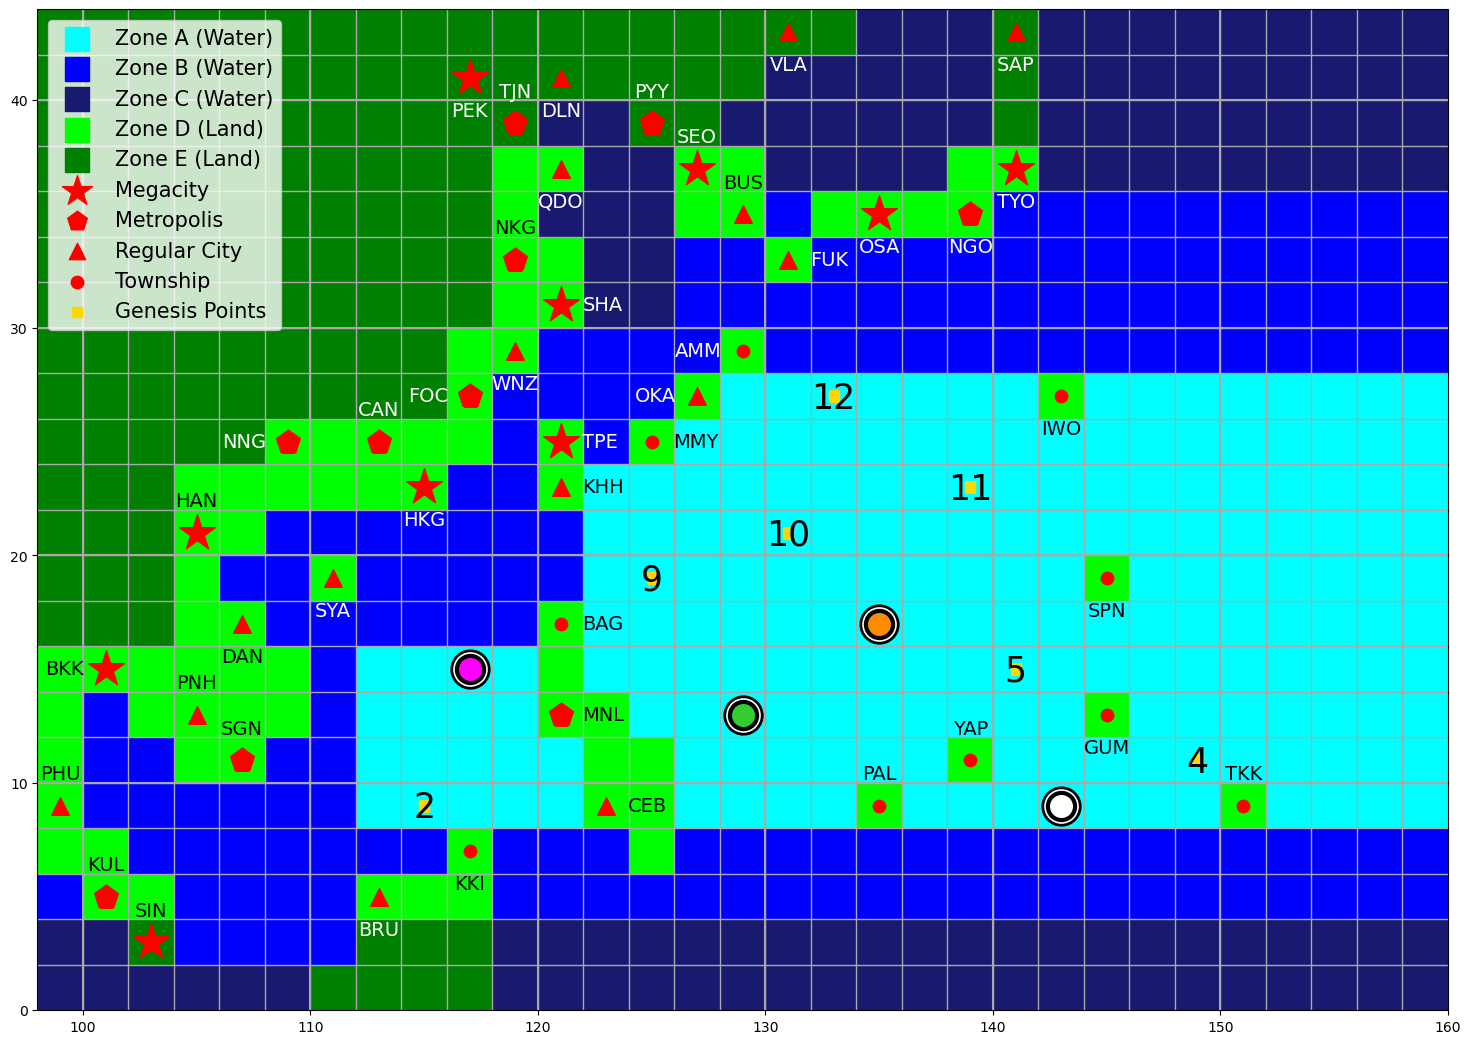

In [28]:
# Plot initial board
Plot_Current_Board(Player_Data)

In [29]:
# Shuffle cards
Movement_Deck = Shuffle_Cards(Movement_Cards)
Intensity_Deck = Shuffle_Cards(Intensity_Cards)
Action_Deck = Shuffle_Cards(Action_Cards)

In [30]:
# Deal cards
Movement_Deck = Deal_Cards(Movement_Deck, Player_Data, 4)
Intensity_Deck = Deal_Cards(Intensity_Deck, Player_Data, 4)
Action_Deck = Deal_Cards(Action_Deck, Player_Data, 2)

In [31]:
# Define game state
Game_State = {"Round": 0, "Player Position": 0, "Status": "Initialize", \
"Movement Deck": Movement_Deck, "Intensity Deck": Intensity_Deck, "Action Deck": Action_Deck, \
"Movement Discard": [], "Intensity Discard": [], "Action Discard": [], \
"Ocean ACE": 250 * n_Players, "Cities Budget": {}, "Effects": []}
#
# Define cities budget
for i in range(len(Cities_DF)):
    Game_State["Cities Budget"][Cities_DF.iloc[i]["City"]] = Cities_DF.iloc[i]["Initial Budget"]

In [32]:
# Save player data and game state history
Player_Data_History = []
Game_State_History = []
Save_State(Player_Data, Game_State, Player_Data_History, Game_State_History)

### Backup Material

In [ ]:
Game_State

In [ ]:
Player_Data

In [ ]:
#Player_Data, Game_State = Reset(Player_Data_History, Game_State_History)

In [ ]:
#Player_Data, Game_State = Undo(Player_Data_History, Game_State_History)

In [ ]:
#Player_Data_History.pop()

In [ ]:
#Game_State_History.pop()

## Play Game


--- Round 1: Demi's turn ---


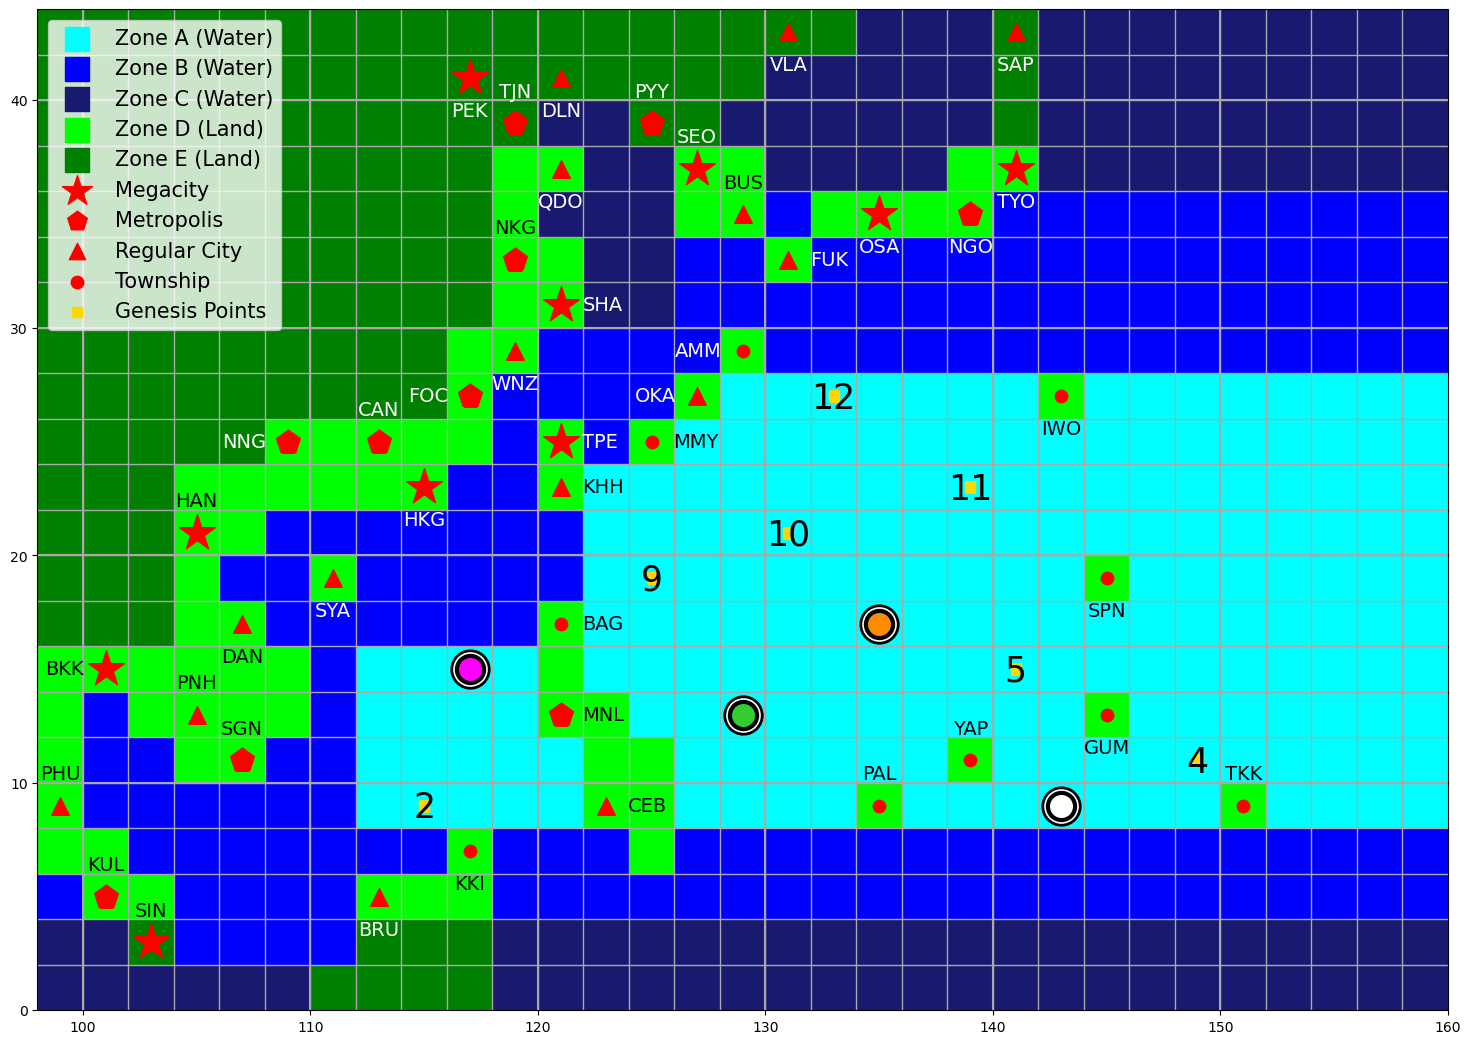

Intensity: 25 knots
ACE: 0 kJ
Landfall Costs: $0 M
Hand:
E 1 N 1
W 1 S 1
N ?
W 2
+5 W/m^2
+10 W/m^2
+10 W/m^2
+20 W/m^2
City Fortress
Survival of the Fittest

--- Round 1: Demi's playing phase ---
Cards played this round: 0 / 3
Hand:
0: E 1 N 1
1: W 1 S 1
2: N ?
3: W 2
4: +5 W/m^2
5: +10 W/m^2
6: +10 W/m^2
7: +20 W/m^2
8: City Fortress
9: Survival of the Fittest


Choose a card by index to play:  7


Demi played: +20 W/m^2

Demi has intensified to 45 knots!

--- Round 1: Demi's playing phase ---
Cards played this round: 1 / 3
Hand:
0: E 1 N 1
1: W 1 S 1
2: N ?
3: W 2
4: +5 W/m^2
5: +10 W/m^2
6: +10 W/m^2
7: City Fortress
8: Survival of the Fittest
Enter 'p' to pass.


Choose a card by index to play:  6


Demi played: +10 W/m^2

Demi has intensified to 55 knots!

--- Round 1: Demi's playing phase ---
Cards played this round: 2 / 3
Hand:
0: E 1 N 1
1: W 1 S 1
2: N ?
3: W 2
4: +5 W/m^2
5: +10 W/m^2
6: City Fortress
7: Survival of the Fittest
Enter 'p' to pass.


Choose a card by index to play:  5


Demi played: +10 W/m^2

Demi has intensified to 65 knots!

--- End of Demi's turn ---
Demi's current intensity: 65 knots.
Demi has gained 20 kJ. Current ACE: 20 kJ.
The ocean has 980 kJ of energy remaining.


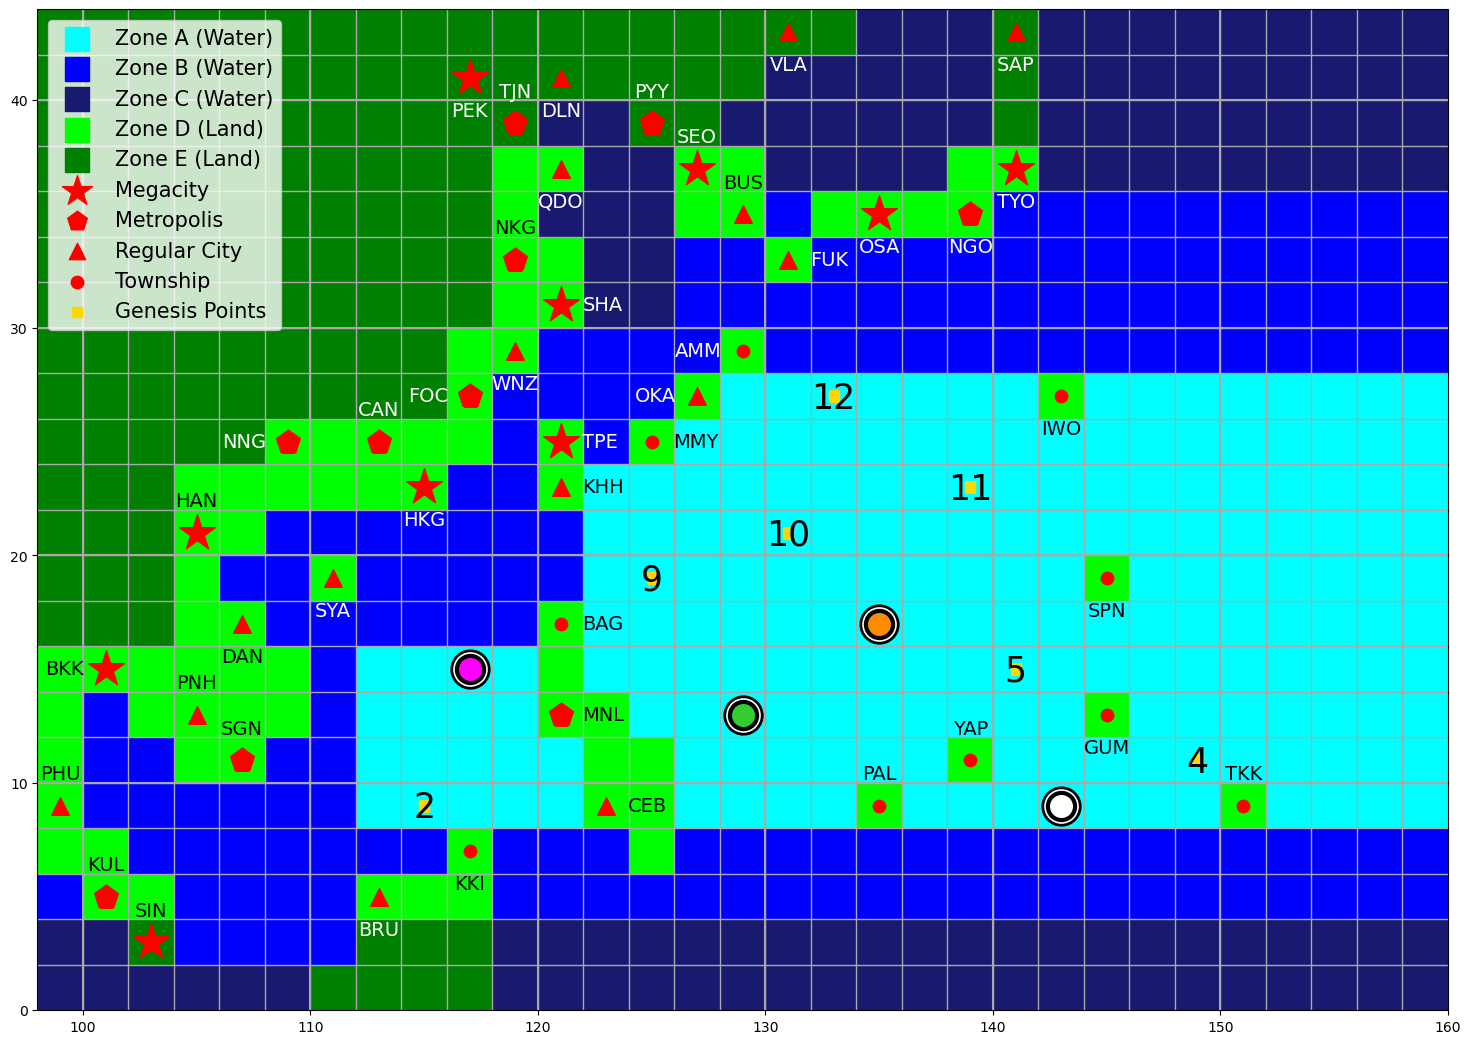

In [52]:
Run_Round(1, 1, Player_Data, Game_State, Player_Data_History, Game_State_History)


--- Round 1: Kinen's turn ---


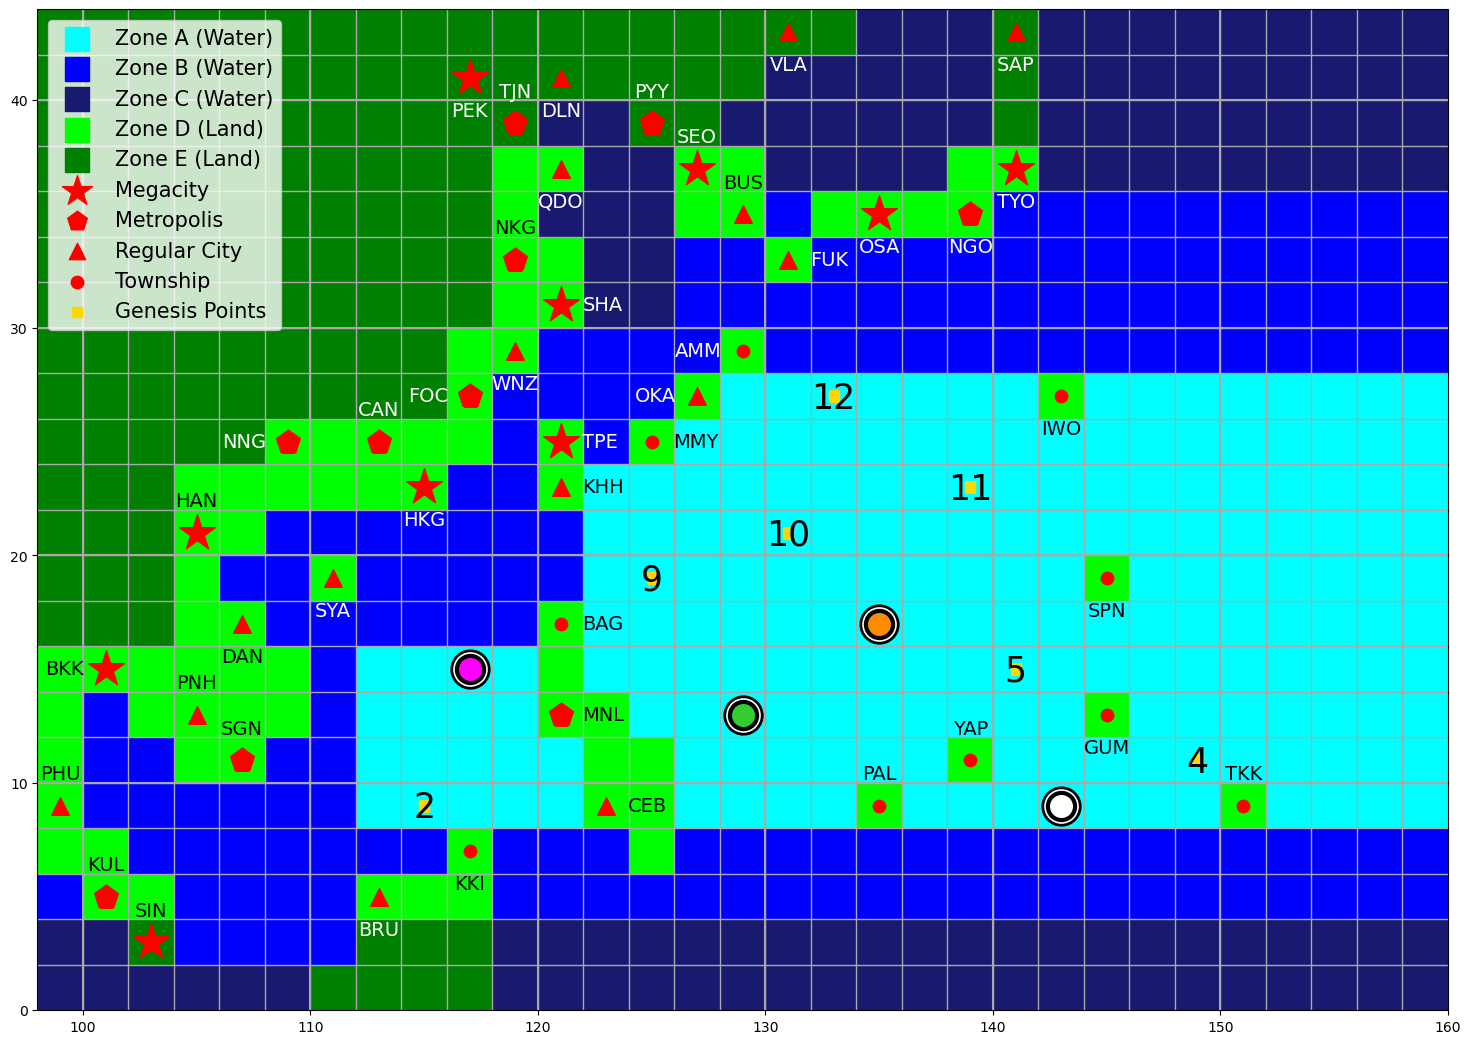

Intensity: 25 knots
ACE: 0 kJ
Landfall Costs: $0 M
Hand:
N 5
N 1
E 1 N 1
W 3
+ ? W/m^2
+25 W/m^2
+20 W/m^2
+25 W/m^2
Rapid Intensification
Factory Reset

--- Round 1: Kinen's playing phase ---
Cards played this round: 0 / 3
Hand:
0: N 5
1: N 1
2: E 1 N 1
3: W 3
4: + ? W/m^2
5: +25 W/m^2
6: +20 W/m^2
7: +25 W/m^2
8: Rapid Intensification (cannot play)
9: Factory Reset


Choose a card by index to play:  5


Kinen played: +25 W/m^2

Kinen has intensified to 50 knots!

--- Round 1: Kinen's playing phase ---
Cards played this round: 1 / 3
Hand:
0: N 5
1: N 1
2: E 1 N 1
3: W 3
4: + ? W/m^2
5: +20 W/m^2
6: +25 W/m^2
7: Rapid Intensification
8: Factory Reset
Enter 'p' to pass.


Choose a card by index to play:  7


Kinen played: Rapid Intensification

Kinen has intensified to 75 knots!

--- Round 1: Kinen's playing phase ---
Cards played this round: 2 / 3
Hand:
0: N 5
1: N 1
2: E 1 N 1
3: W 3
4: + ? W/m^2
5: +20 W/m^2
6: +25 W/m^2
7: Factory Reset
Enter 'p' to pass.


Choose a card by index to play:  4


Kinen played: + ? W/m^2

Kinen rolled 1: + 5 W/m^2
Kinen has intensified to 80 knots!

--- End of Kinen's turn ---
Kinen's current intensity: 80 knots.
Kinen has gained 20 kJ. Current ACE: 20 kJ.
The ocean has 960 kJ of energy remaining.


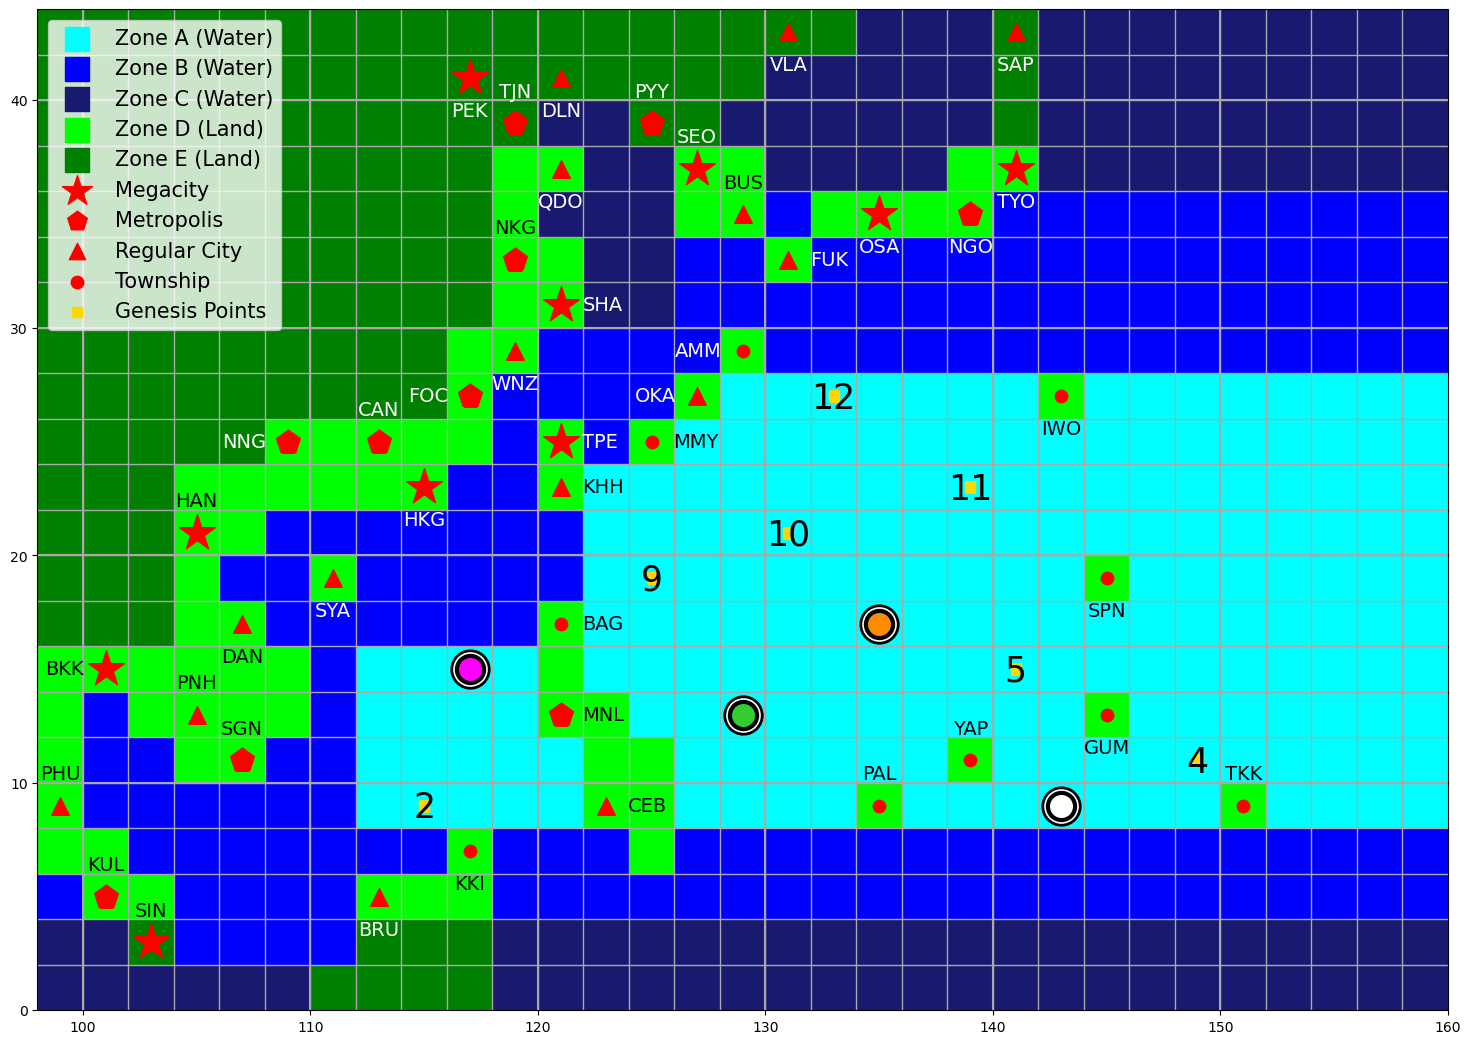

In [53]:
Run_Round(1, 2, Player_Data, Game_State, Player_Data_History, Game_State_History)


--- Round 1: Jin's turn ---


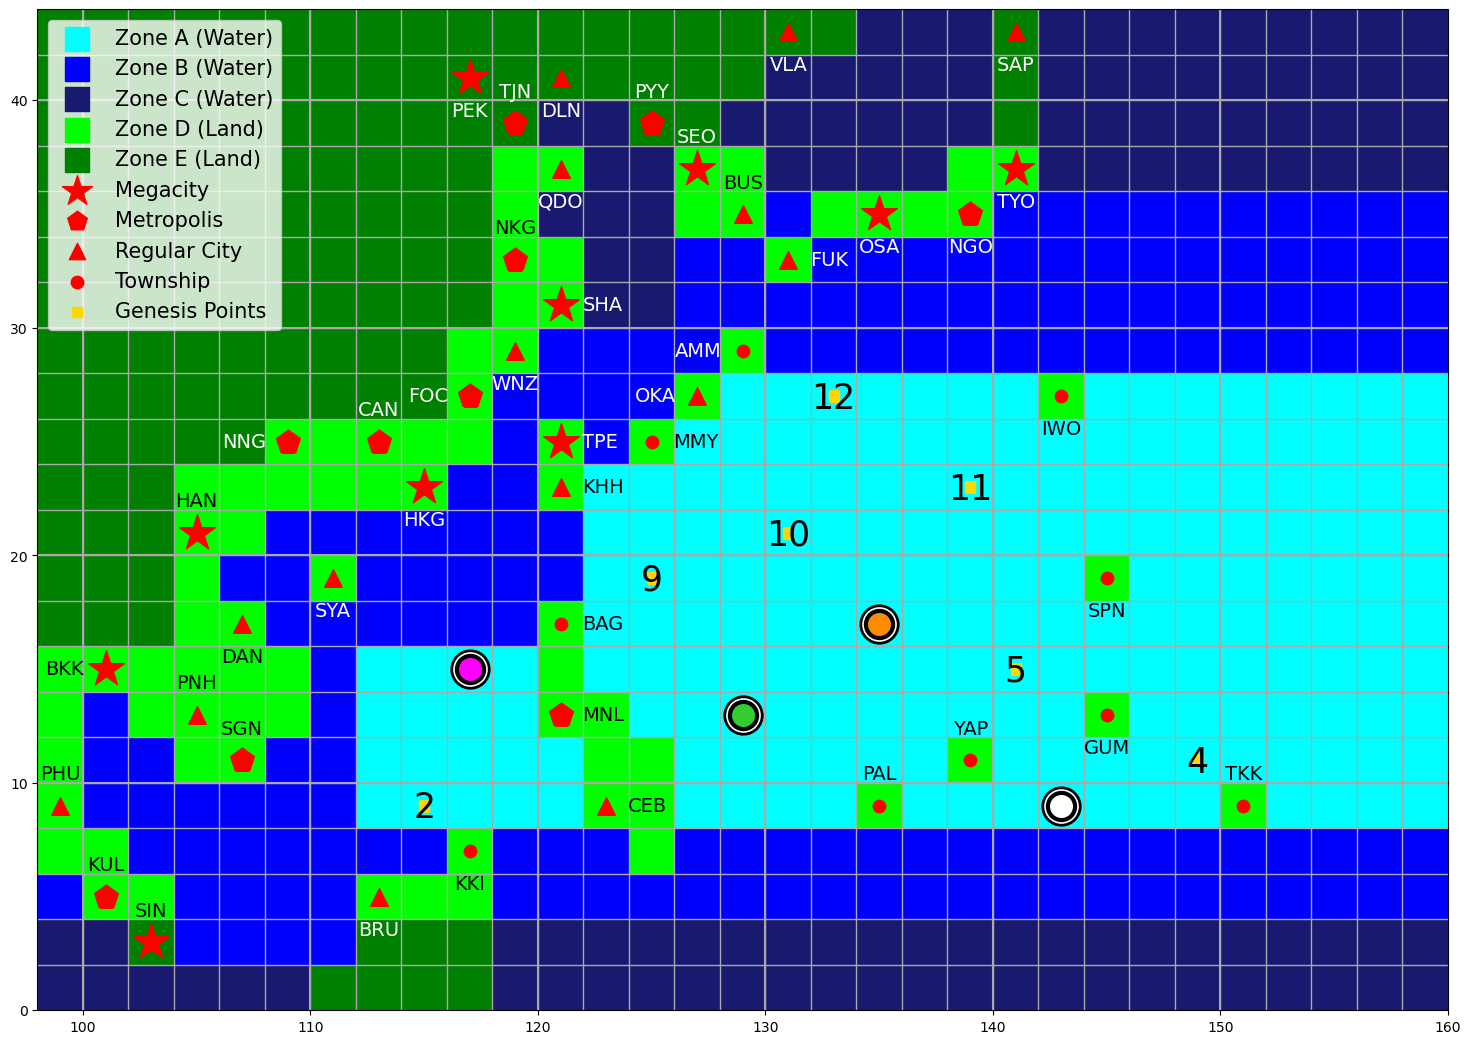

Intensity: 25 knots
ACE: 0 kJ
Landfall Costs: $0 M
Hand:
W 2
W/E 1
N 1
W ?
+5 W/m^2
+20 W/m^2
+20 W/m^2
+10 W/m^2
Random Teleportation
Extra Time

--- Round 1: Jin's playing phase ---
Cards played this round: 0 / 3
Hand:
0: W 2
1: W/E 1
2: N 1
3: W ?
4: +5 W/m^2
5: +20 W/m^2
6: +20 W/m^2
7: +10 W/m^2
8: Random Teleportation
9: Extra Time


Choose a card by index to play:  5


Jin played: +20 W/m^2

Jin has intensified to 45 knots!

--- Round 1: Jin's playing phase ---
Cards played this round: 1 / 3
Hand:
0: W 2
1: W/E 1
2: N 1
3: W ?
4: +5 W/m^2
5: +20 W/m^2
6: +10 W/m^2
7: Random Teleportation
8: Extra Time
Enter 'p' to pass.


Choose a card by index to play:  5


Jin played: +20 W/m^2

Jin has intensified to 65 knots!

--- Round 1: Jin's playing phase ---
Cards played this round: 2 / 3
Hand:
0: W 2
1: W/E 1
2: N 1
3: W ?
4: +5 W/m^2
5: +10 W/m^2
6: Random Teleportation
7: Extra Time
Enter 'p' to pass.


Choose a card by index to play:  0


Jin played: W 2



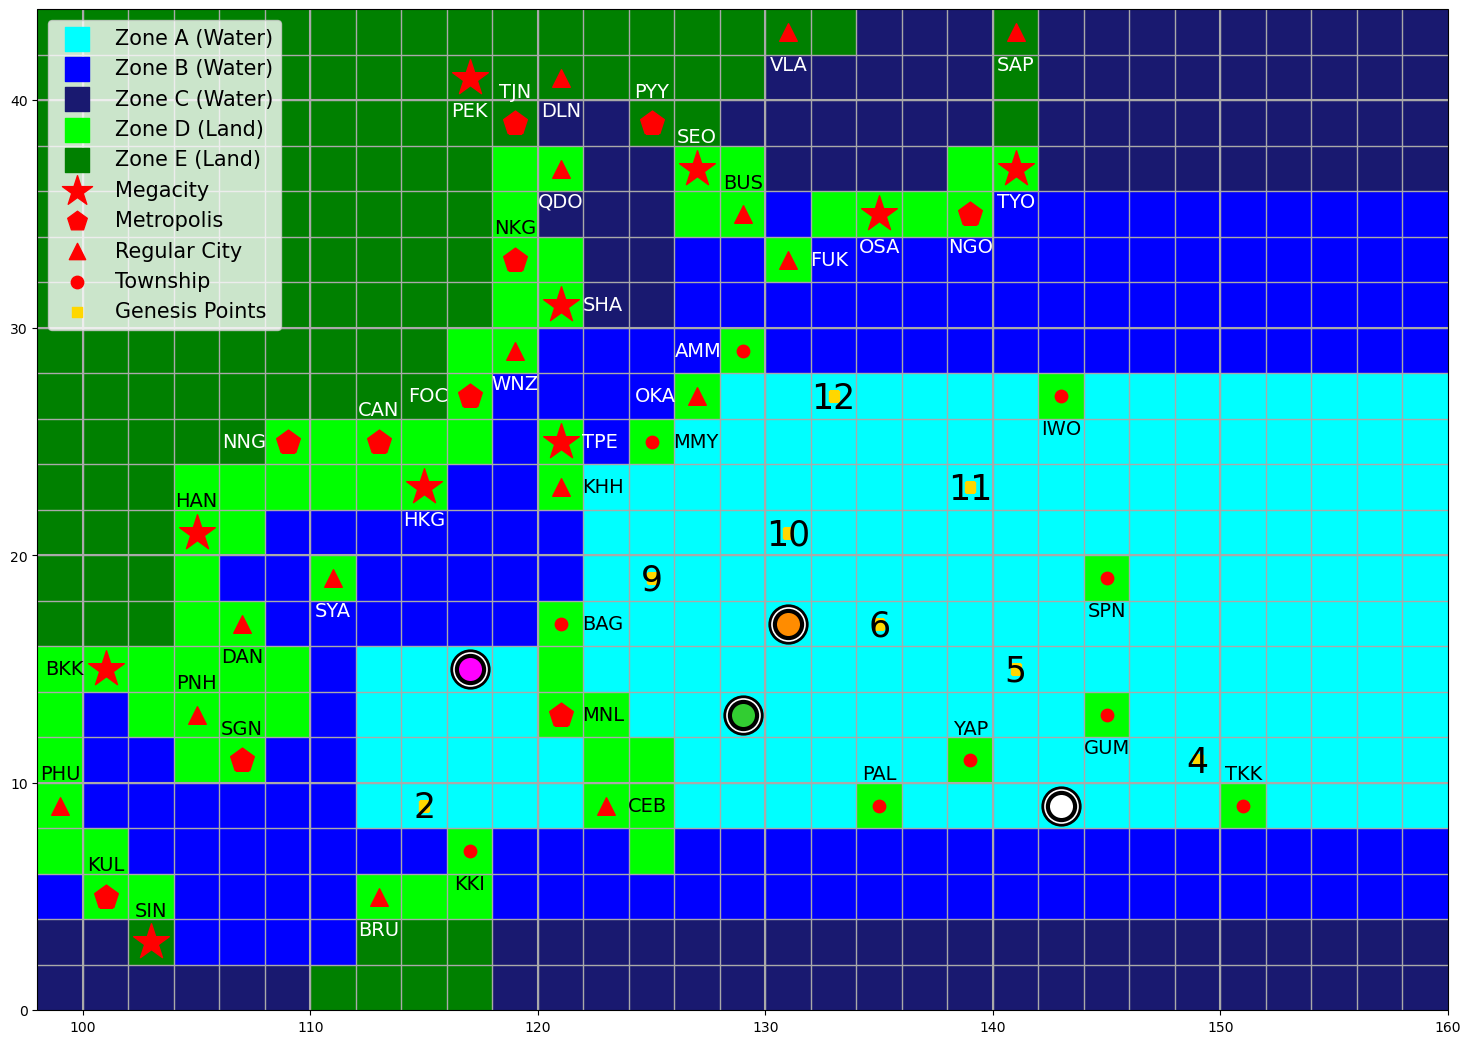


--- End of Jin's turn ---
Jin's current intensity: 65 knots.
Jin has gained 20 kJ. Current ACE: 20 kJ.
The ocean has 940 kJ of energy remaining.


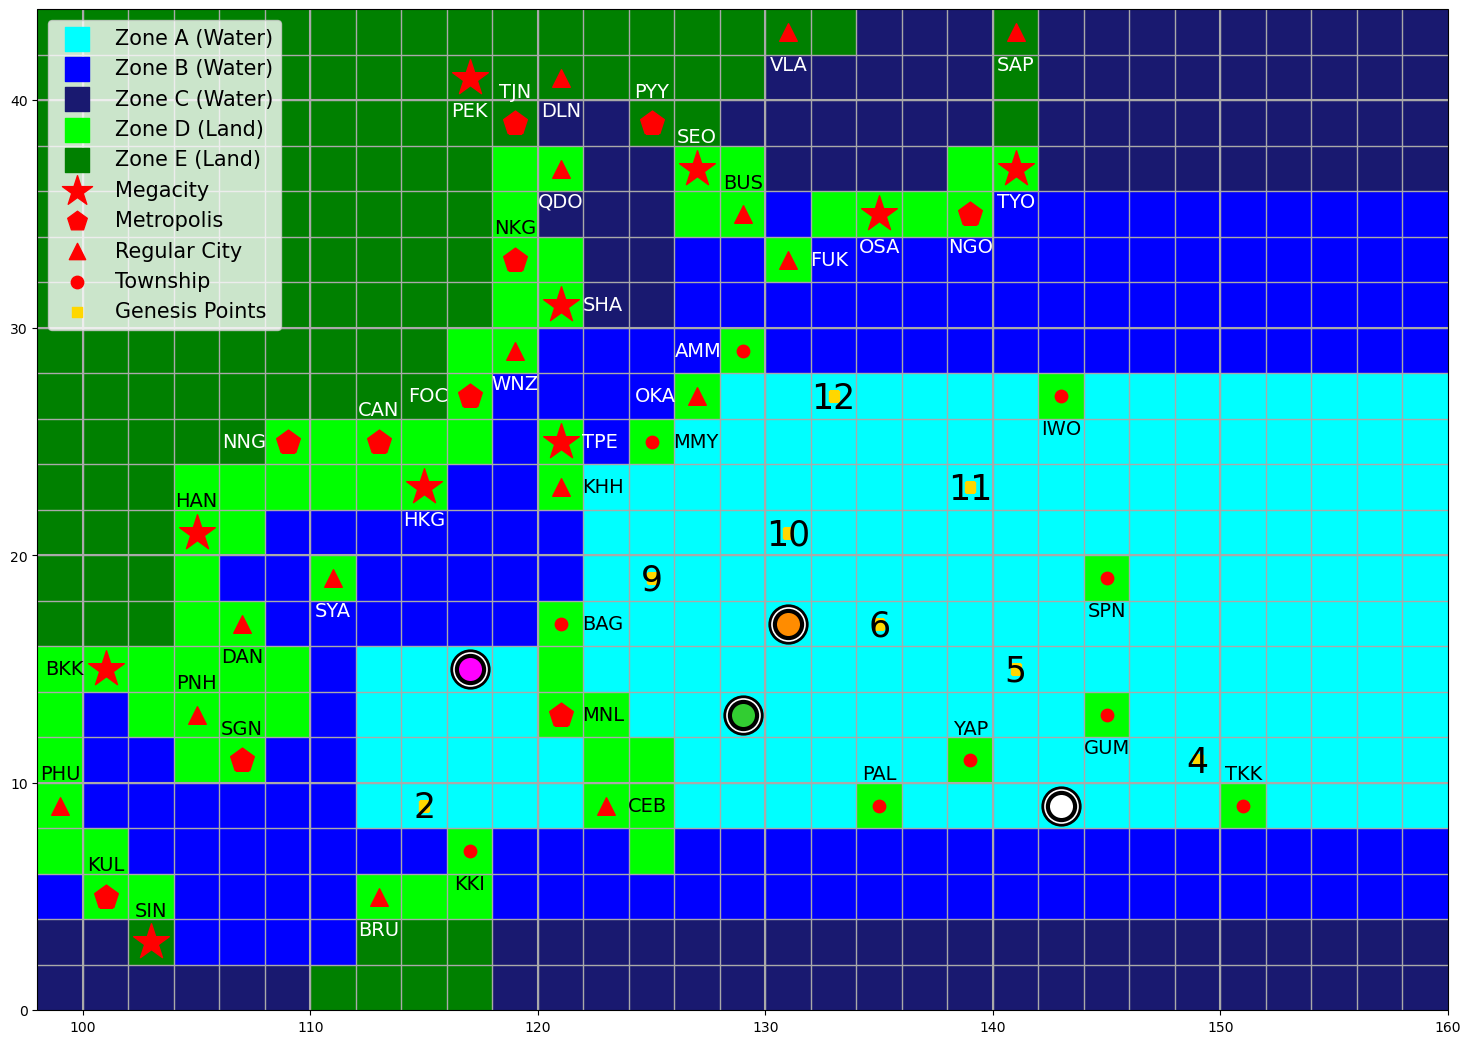

In [54]:
Run_Round(1, 3, Player_Data, Game_State, Player_Data_History, Game_State_History)


--- Round 1: Jason's turn ---


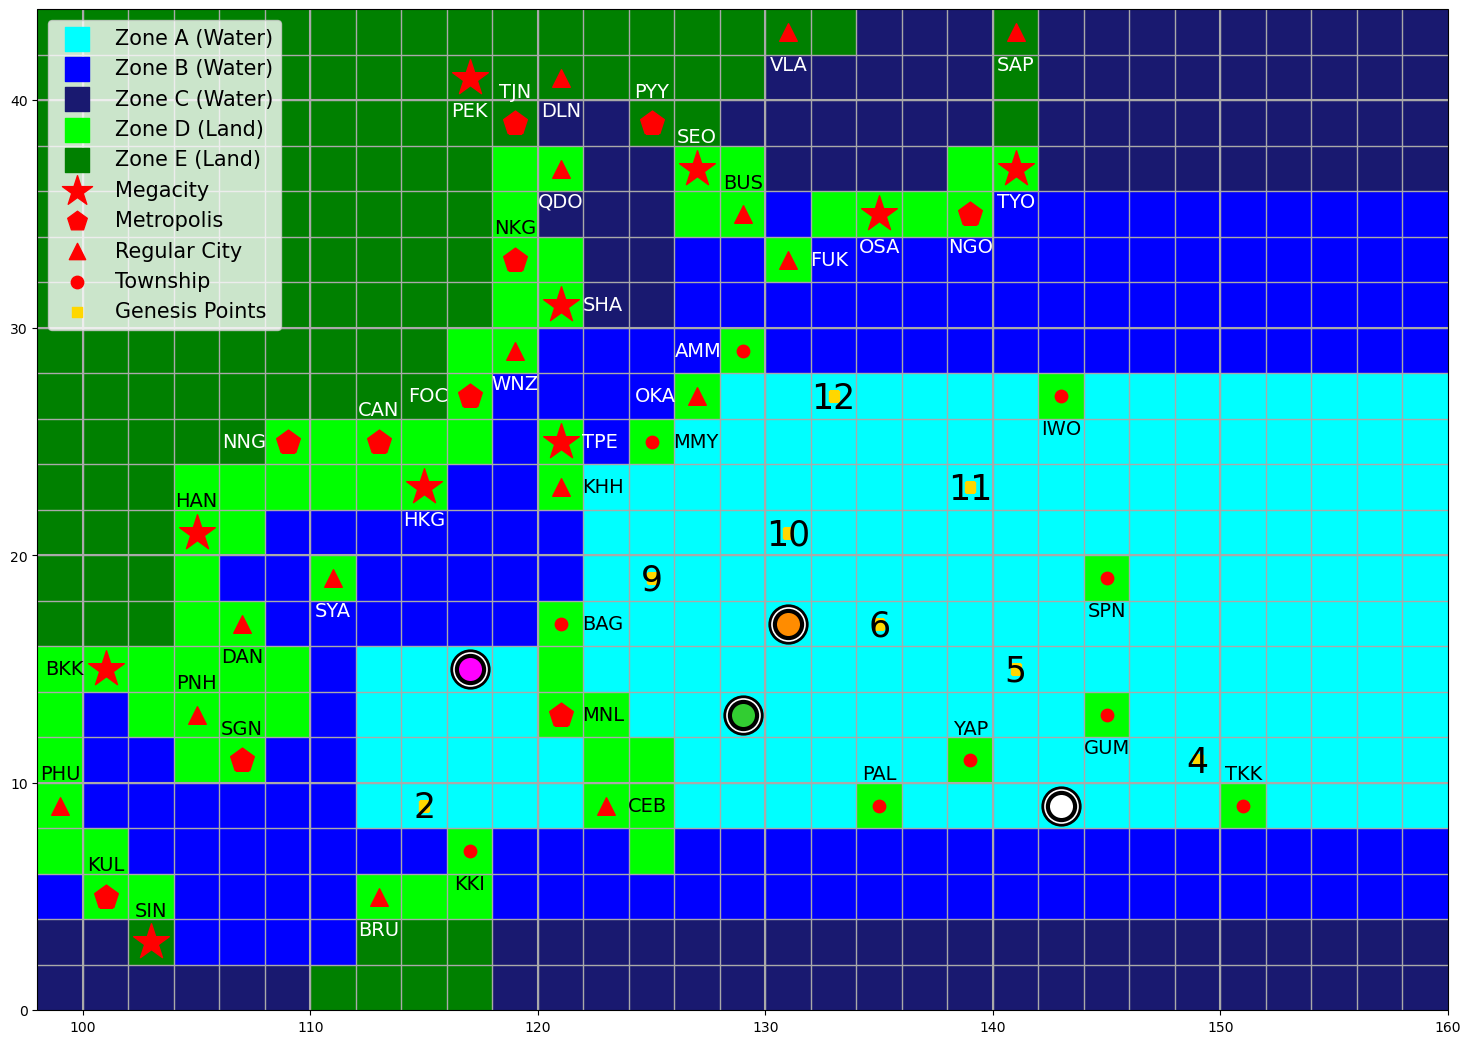

Intensity: 25 knots
ACE: 0 kJ
Landfall Costs: $0 M
Hand:
E 1
W/E/N/S 1
E 1
W 1 N 1
+10 W/m^2
+5 W/m^2
+10 W/m^2
+5 W/m^2
Cyclone Express
Rapid Intensification

--- Round 1: Jason's playing phase ---
Cards played this round: 0 / 3
Hand:
0: E 1
1: W/E/N/S 1
2: E 1
3: W 1 N 1
4: +10 W/m^2
5: +5 W/m^2
6: +10 W/m^2
7: +5 W/m^2
8: Cyclone Express (cannot play)
9: Rapid Intensification (cannot play)


Choose a card by index to play:  4


Jason played: +10 W/m^2

Jason has intensified to 35 knots!

--- Round 1: Jason's playing phase ---
Cards played this round: 1 / 3
Hand:
0: E 1
1: W/E/N/S 1
2: E 1
3: W 1 N 1
4: +5 W/m^2
5: +10 W/m^2
6: +5 W/m^2
7: Cyclone Express (cannot play)
8: Rapid Intensification
Enter 'p' to pass.


Choose a card by index to play:  5


Jason played: +10 W/m^2

Jason has intensified to 45 knots!

--- Round 1: Jason's playing phase ---
Cards played this round: 2 / 3
Hand:
0: E 1
1: W/E/N/S 1
2: E 1
3: W 1 N 1
4: +5 W/m^2
5: +5 W/m^2
6: Cyclone Express (cannot play)
7: Rapid Intensification
Enter 'p' to pass.


Choose a card by index to play:  3


Jason played: W 1 N 1



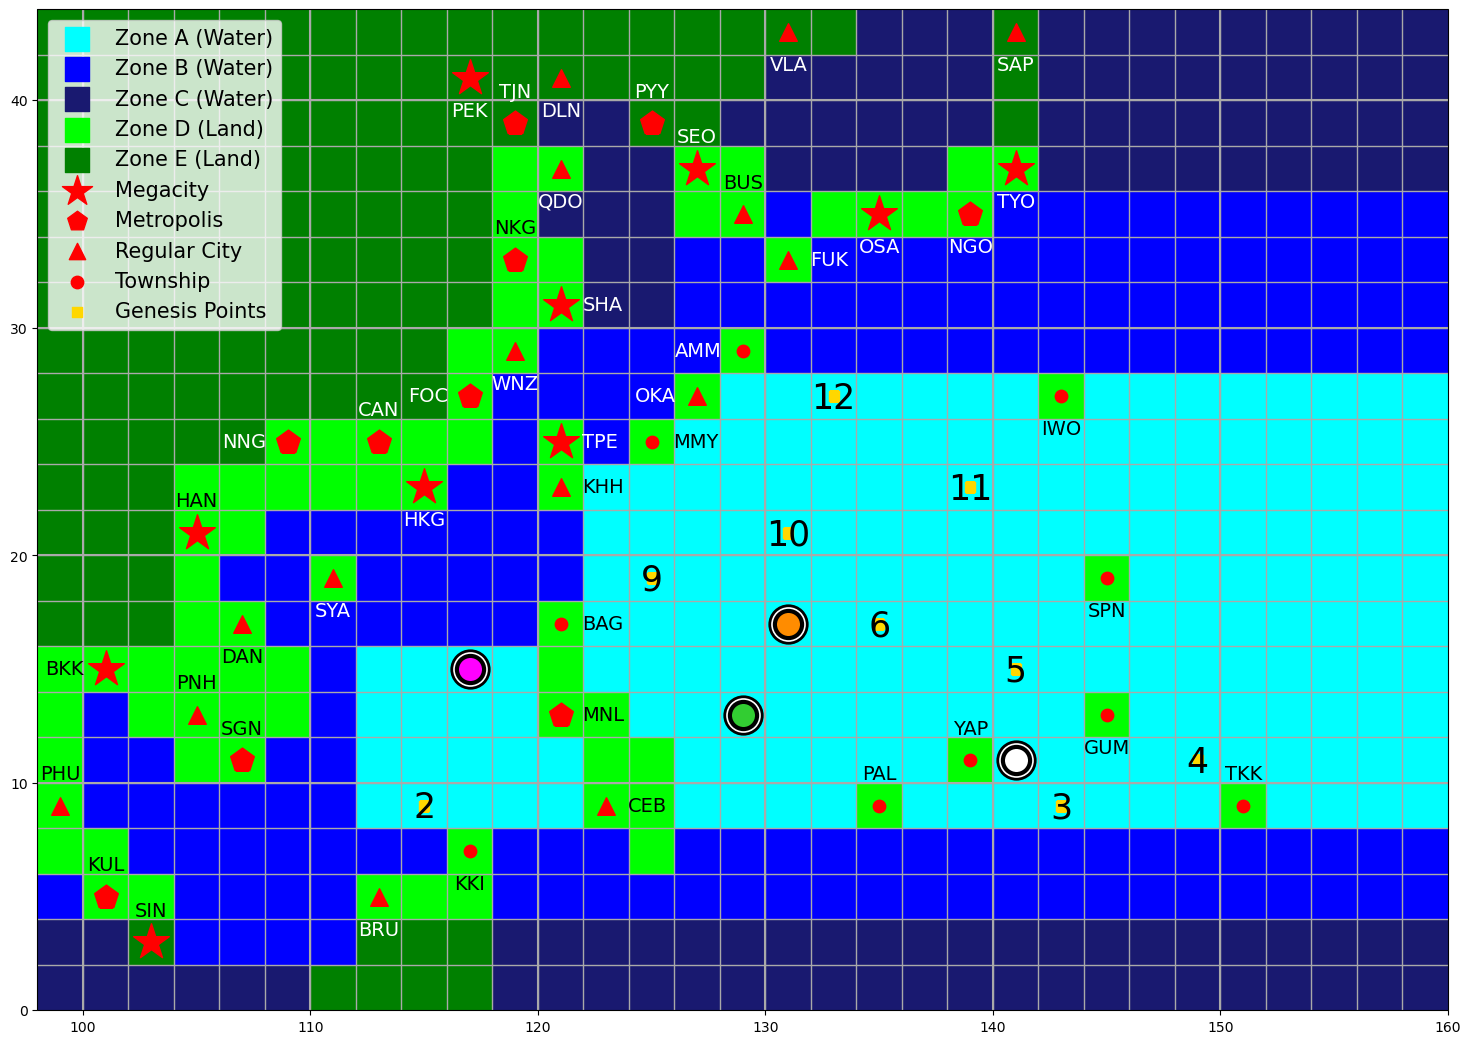


--- End of Jason's turn ---
Jason's current intensity: 45 knots.
Jason has gained 10 kJ. Current ACE: 10 kJ.
The ocean has 930 kJ of energy remaining.


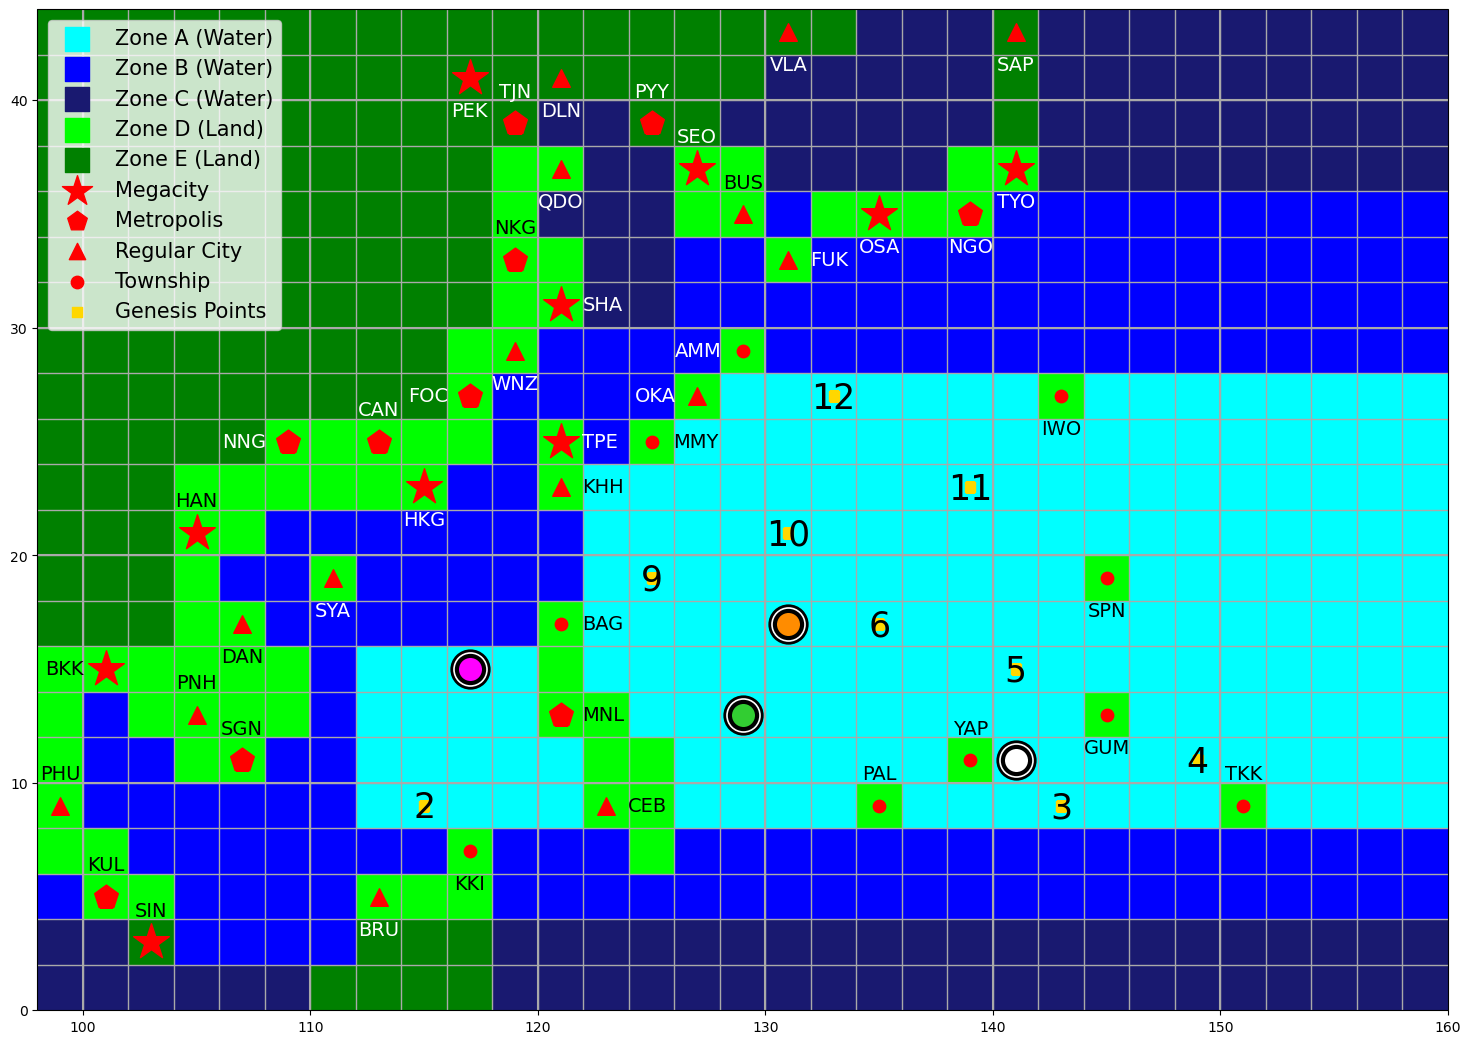

In [55]:
Run_Round(1, 4, Player_Data, Game_State, Player_Data_History, Game_State_History)


--- Round 2: Demi's turn ---


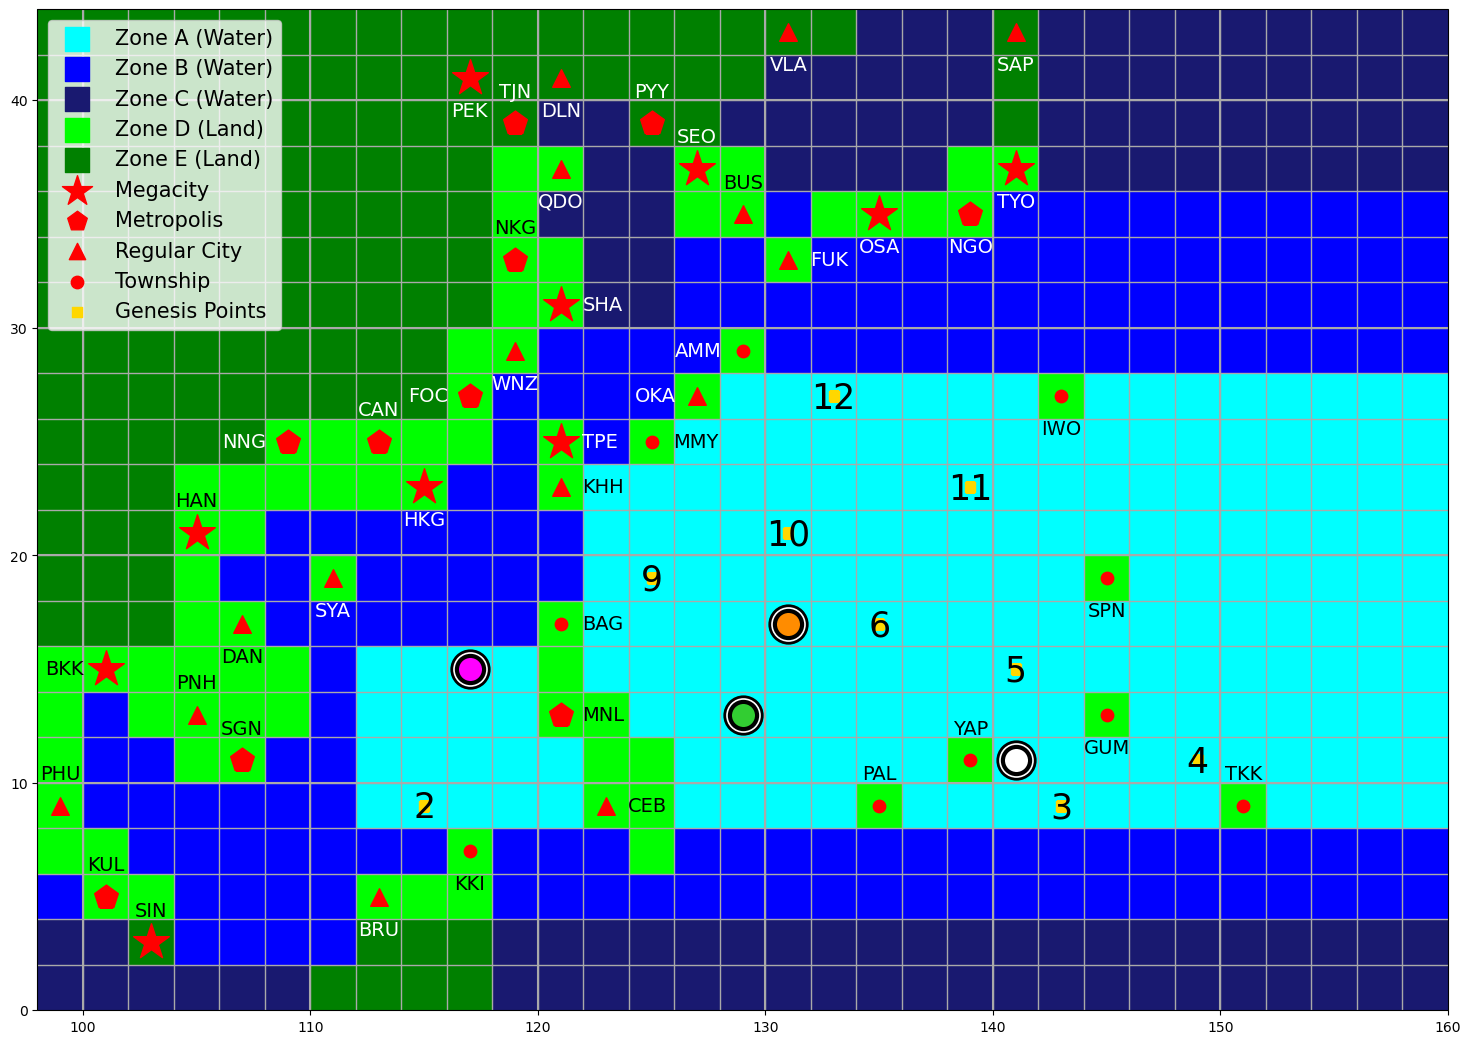

Intensity: 65 knots
ACE: 20 kJ
Landfall Costs: $0 M
Hand:
E 1 N 1
W 1 S 1
N ?
W 2
+5 W/m^2
City Fortress
Survival of the Fittest

--- Round 2: Demi's draw phase ---
0: Movement Deck (59 cards left)
1: Intensity Deck (59 cards left)
2: Action Deck (22 cards left)


Choose a deck by index: 0


Demi drew: E 2 from Movement Deck.

0: Movement Deck (58 cards left)
1: Intensity Deck (59 cards left)
2: Action Deck (22 cards left)


Choose a deck by index: 0


Demi drew: W 1 N 2 from Movement Deck.


--- Round 2: Demi's playing phase ---
Cards played this round: 0 / 3
Hand:
0: E 1 N 1
1: W 1 S 1
2: N ?
3: W 2
4: +5 W/m^2
5: City Fortress
6: Survival of the Fittest
7: E 2
8: W 1 N 2


Choose a card by index to play:  8


Demi played: W 1 N 2



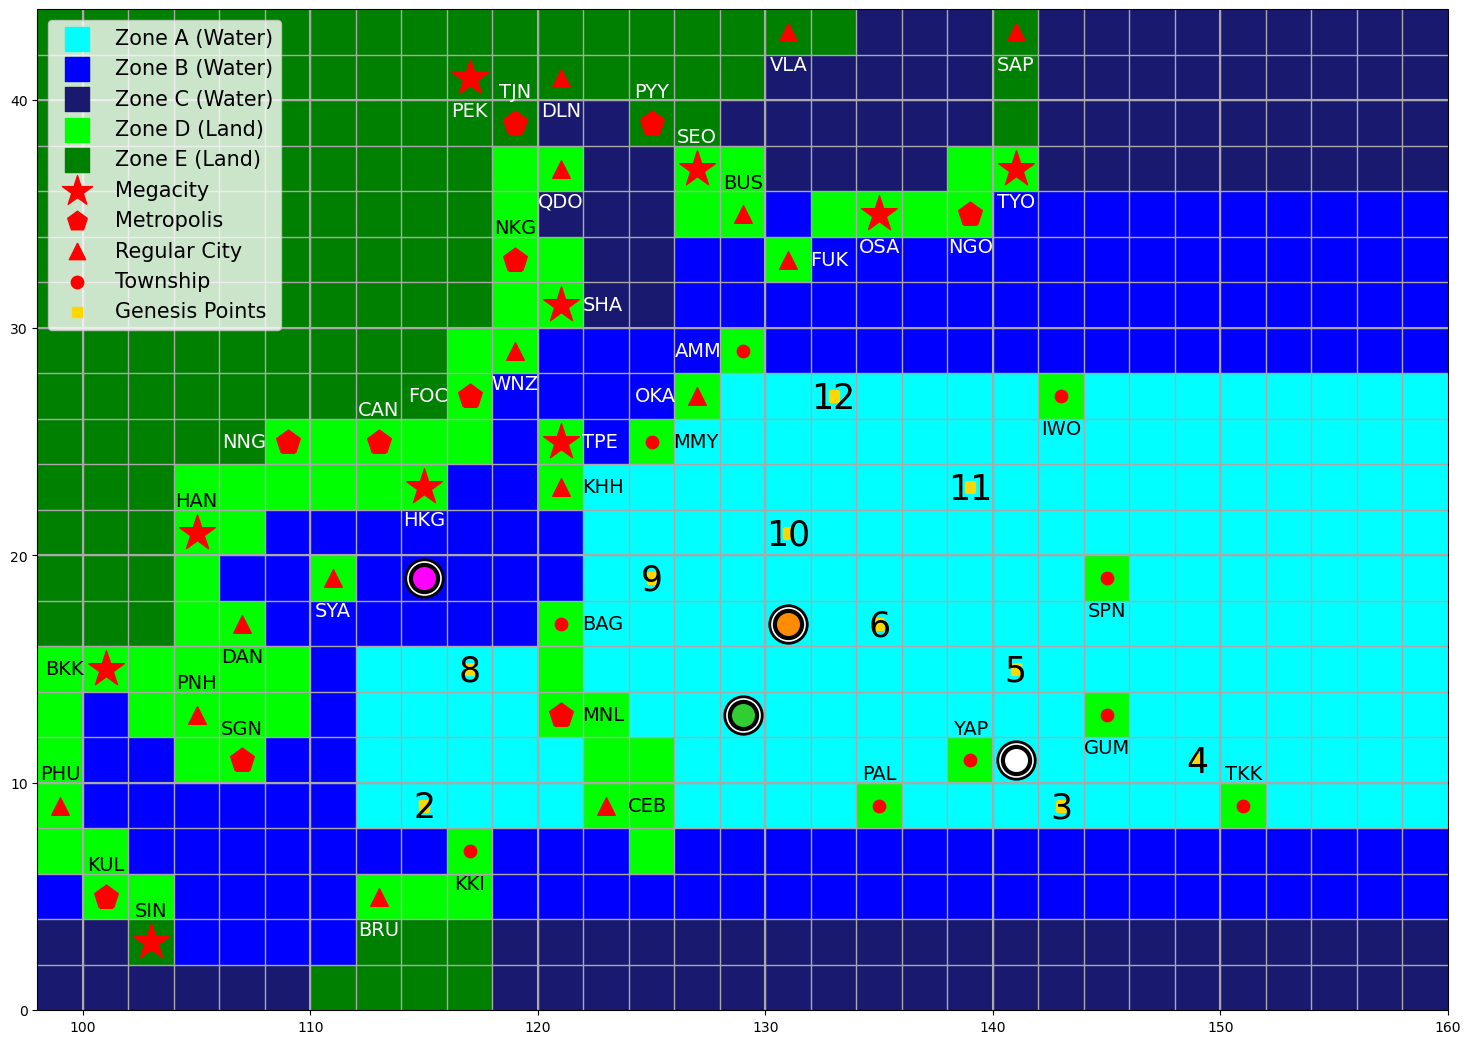


--- Round 2: Demi's playing phase ---
Cards played this round: 1 / 3
Hand:
0: E 1 N 1
1: W 1 S 1
2: N ?
3: W 2
4: +5 W/m^2
5: City Fortress
6: Survival of the Fittest
7: E 2
Enter 'p' to pass.


Choose a card by index to play:  3


Demi played: W 2



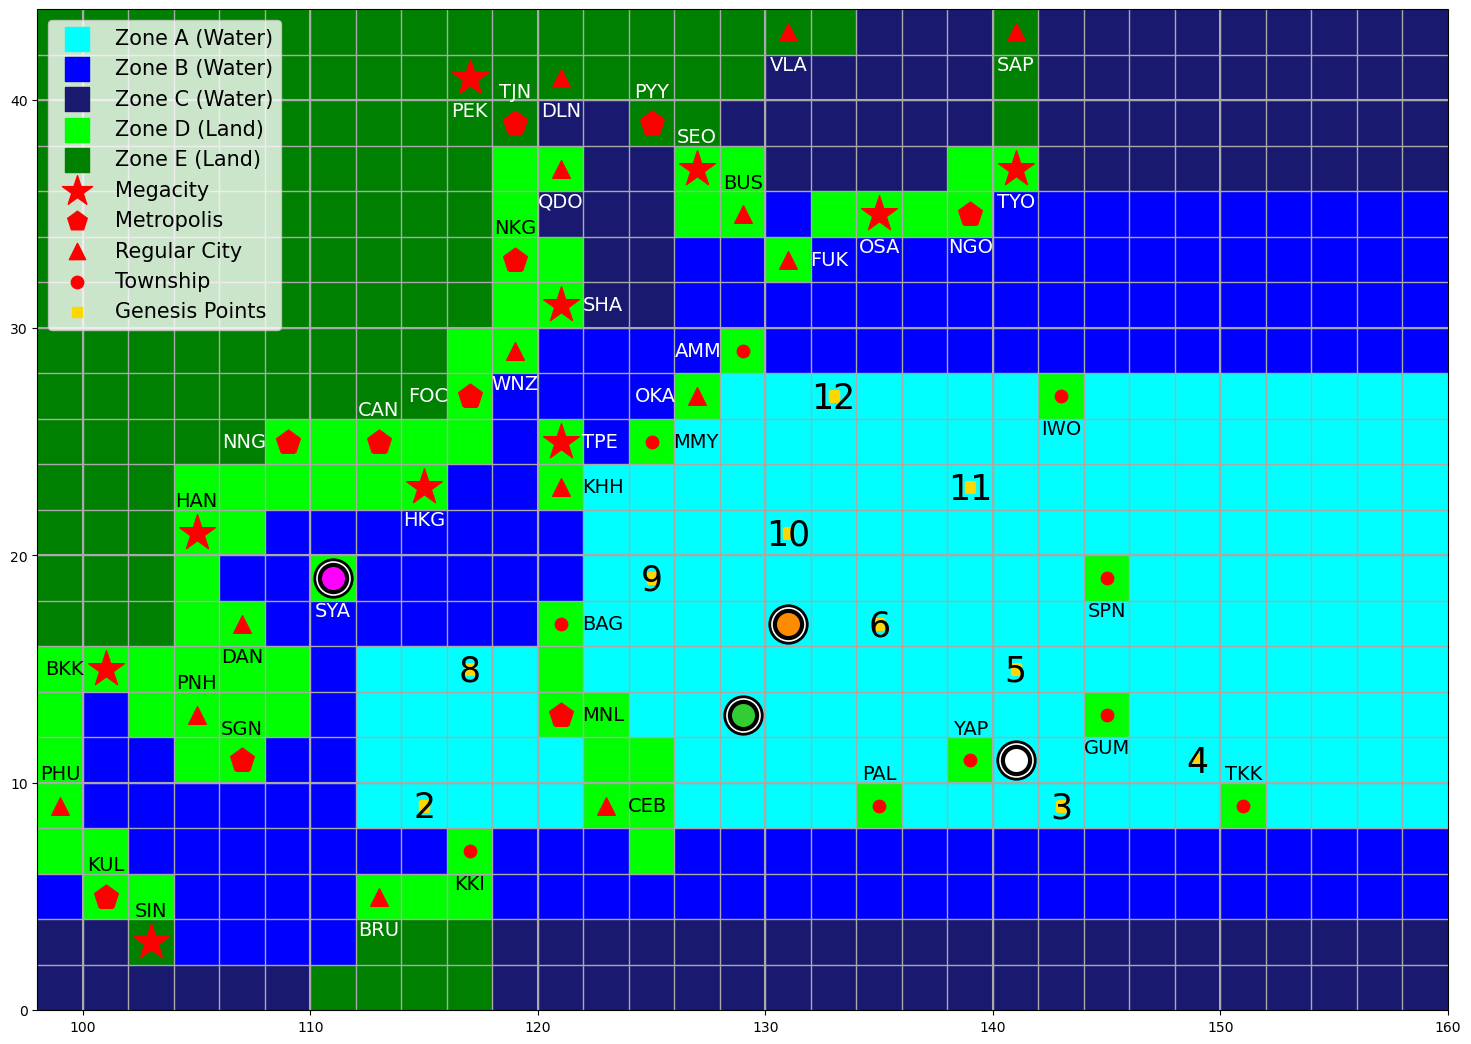

Demi has made landfall at SYA (Sanya) and gains $130M!
Remaining budget of SYA (Sanya): $270M

--- Round 2: Demi's playing phase ---
Cards played this round: 2 / 3
Hand:
0: E 1 N 1
1: W 1 S 1
2: N ?
3: +5 W/m^2 (cannot play)
4: City Fortress
5: Survival of the Fittest
6: E 2
Enter 'p' to pass.


Choose a card by index to play:  6


Demi played: E 2



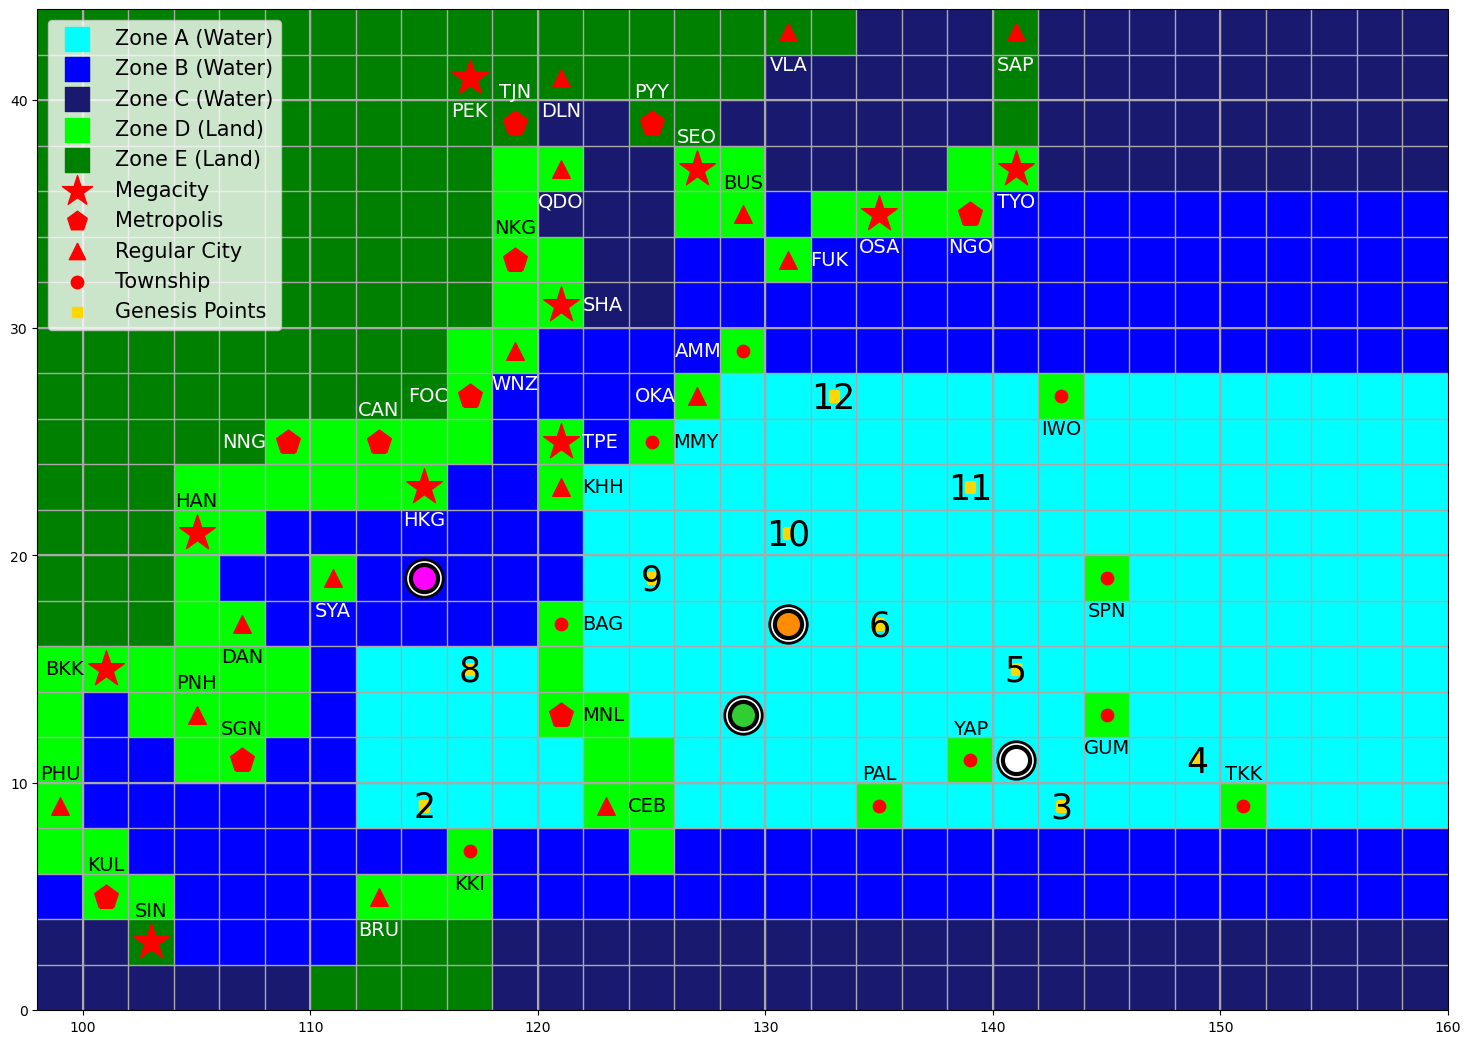


--- End of Demi's turn ---
Demi's current intensity: 65 knots.
Demi has gained 20 kJ. Current ACE: 40 kJ.
The ocean has 910 kJ of energy remaining.


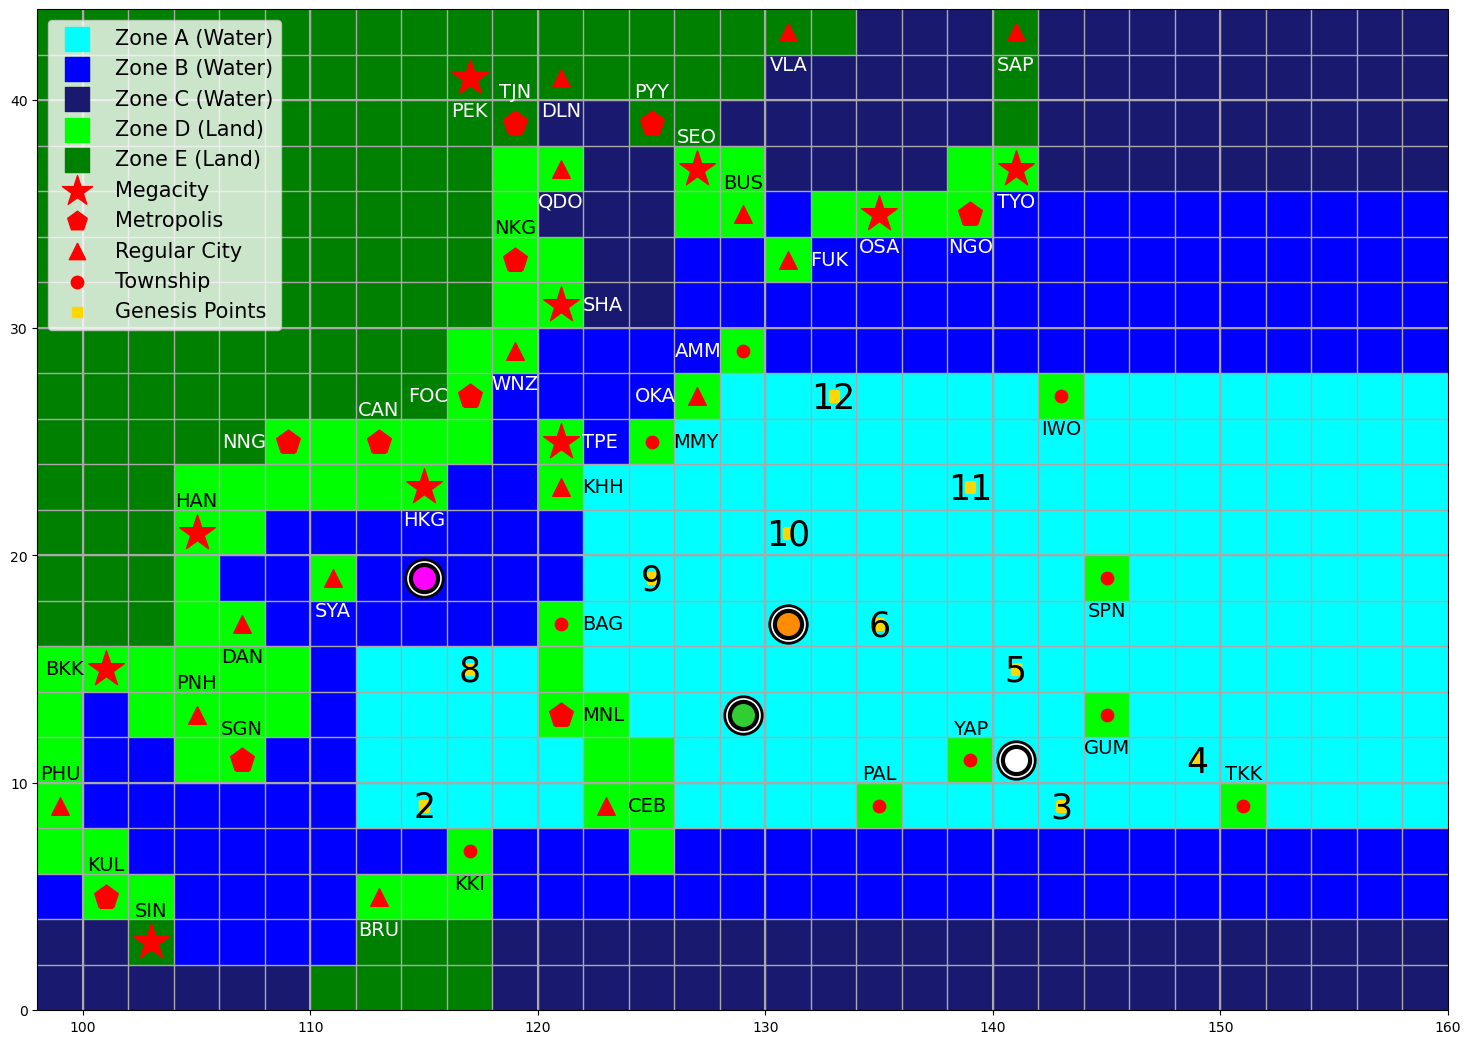

In [56]:
Run_Round(2, 1, Player_Data, Game_State, Player_Data_History, Game_State_History)


--- Round 2: Kinen's turn ---


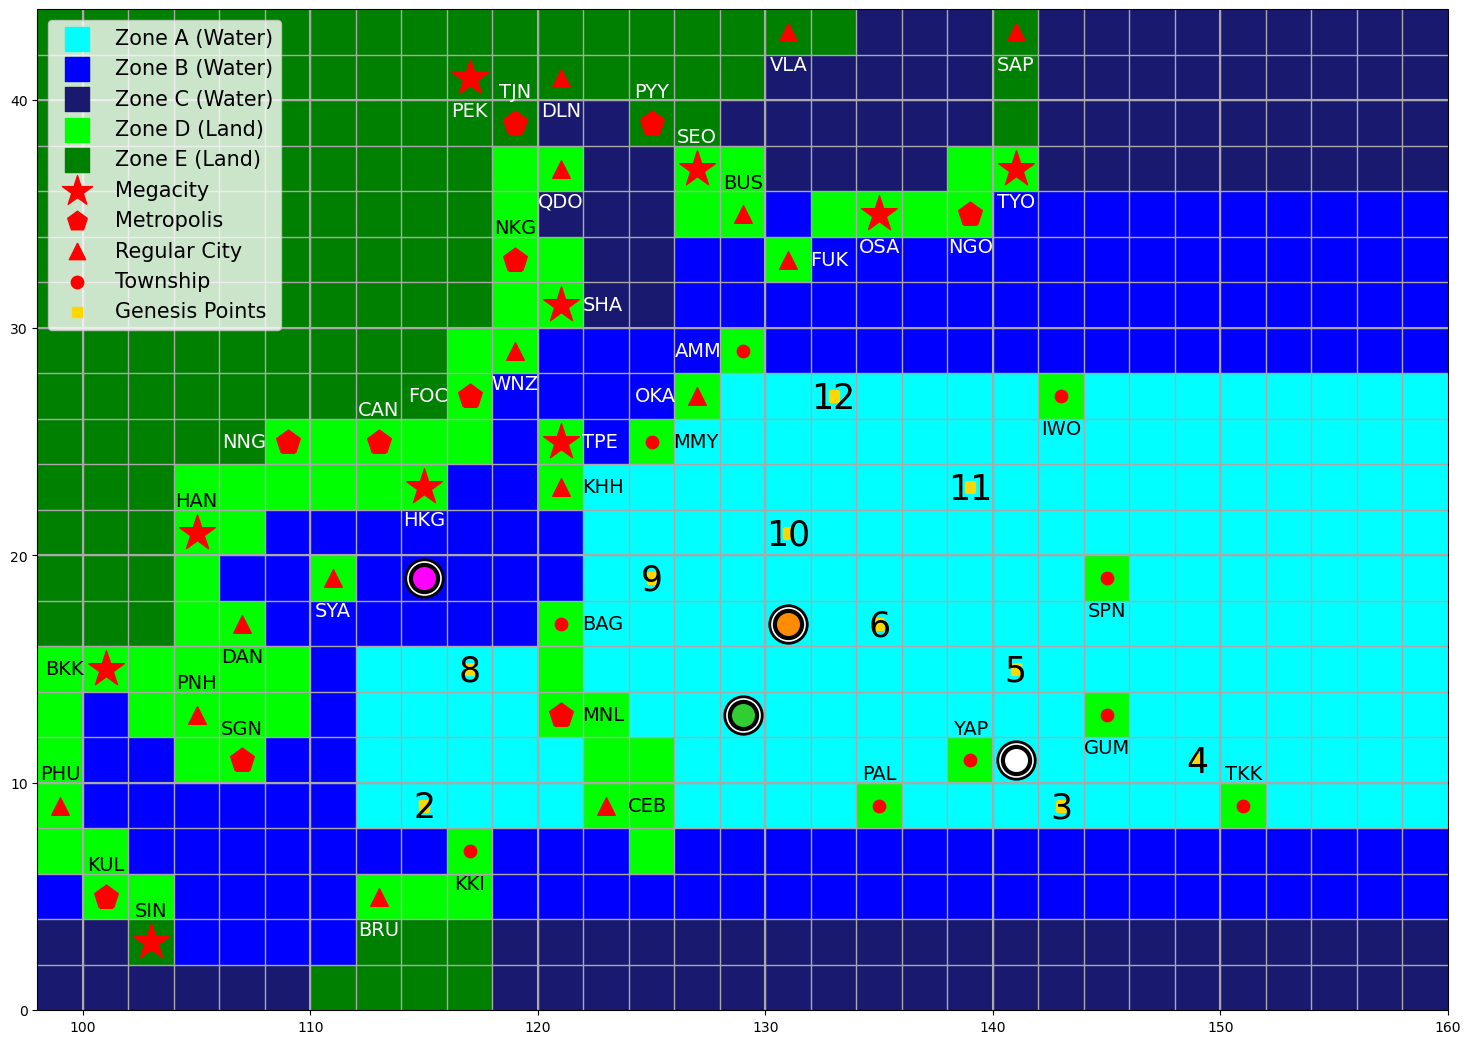

Intensity: 80 knots
ACE: 20 kJ
Landfall Costs: $0 M
Hand:
N 5
N 1
E 1 N 1
W 3
+20 W/m^2
+25 W/m^2
Factory Reset

--- Round 2: Kinen's draw phase ---
0: Movement Deck (57 cards left)
1: Intensity Deck (59 cards left)
2: Action Deck (22 cards left)


Choose a deck by index: 0


Kinen drew: E 2 S 1 from Movement Deck.

0: Movement Deck (56 cards left)
1: Intensity Deck (59 cards left)
2: Action Deck (22 cards left)


Choose a deck by index: 0


Kinen drew: W/E/N/S 1 from Movement Deck.


--- Round 2: Kinen's playing phase ---
Cards played this round: 0 / 3
Hand:
0: N 5
1: N 1
2: E 1 N 1
3: W 3
4: +20 W/m^2
5: +25 W/m^2
6: Factory Reset
7: E 2 S 1
8: W/E/N/S 1


Choose a card by index to play:  5


Kinen played: +25 W/m^2

Kinen has intensified to 100 knots!

--- Round 2: Kinen's playing phase ---
Cards played this round: 1 / 3
Hand:
0: N 5
1: N 1
2: E 1 N 1
3: W 3
4: +20 W/m^2
5: Factory Reset
6: E 2 S 1
7: W/E/N/S 1
Enter 'p' to pass.


Choose a card by index to play:  3


Kinen played: W 3



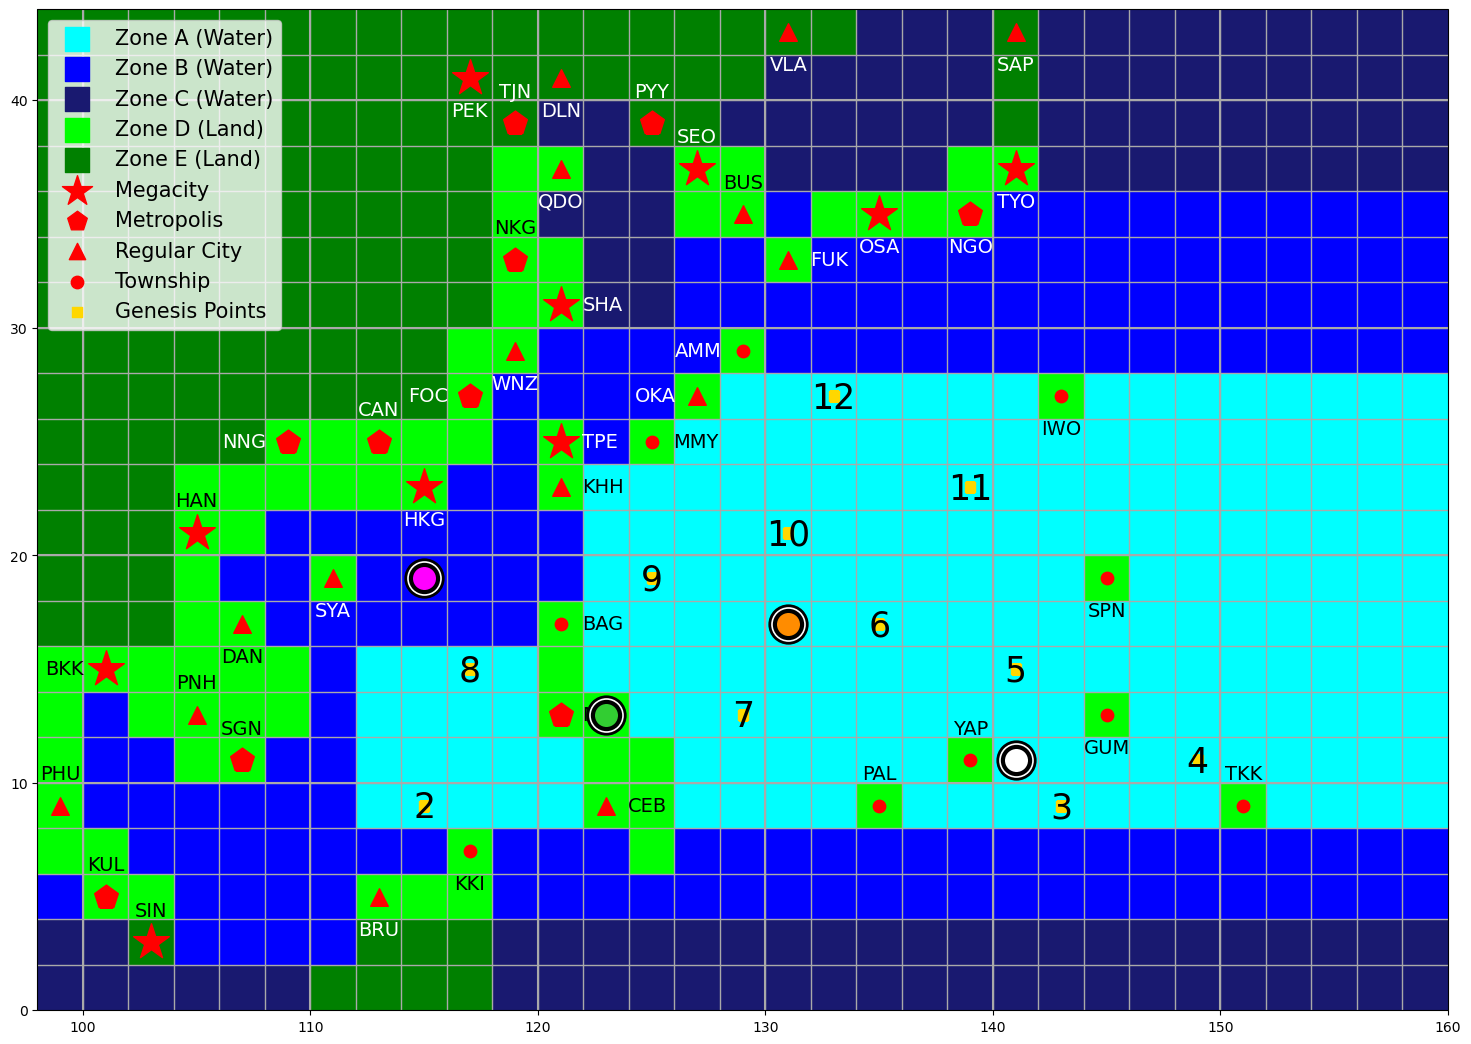


--- Round 2: Kinen's playing phase ---
Cards played this round: 2 / 3
Hand:
0: N 5
1: N 1
2: E 1 N 1
3: +20 W/m^2 (cannot play)
4: Factory Reset
5: E 2 S 1
6: W/E/N/S 1
Enter 'p' to pass.


Choose a card by index to play:  6


Kinen played: W/E/N/S 1



Choose W, E, N or S:  W


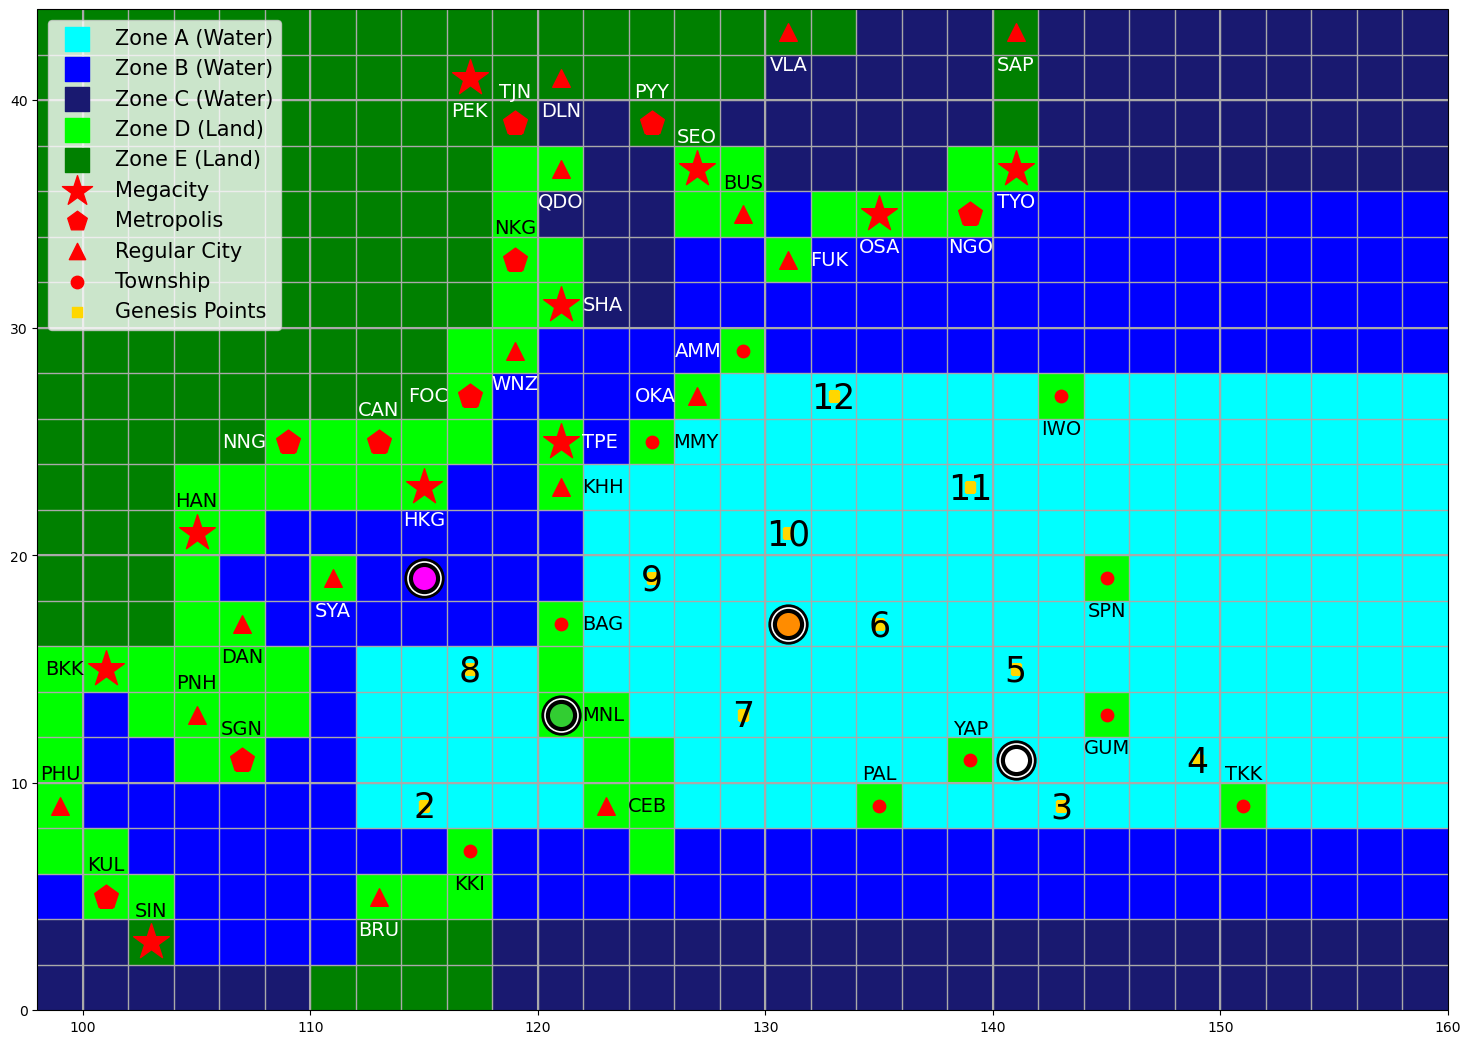

Kinen has made landfall at MNL (Manila) and gains $300M!
Remaining budget of MNL (Manila): $450M

--- End of Kinen's turn ---
Kinen's current intensity: 100 knots.
Kinen has gained 50 kJ. Current ACE: 70 kJ.
The ocean has 860 kJ of energy remaining.
Kinen has weakened to 95 knots.


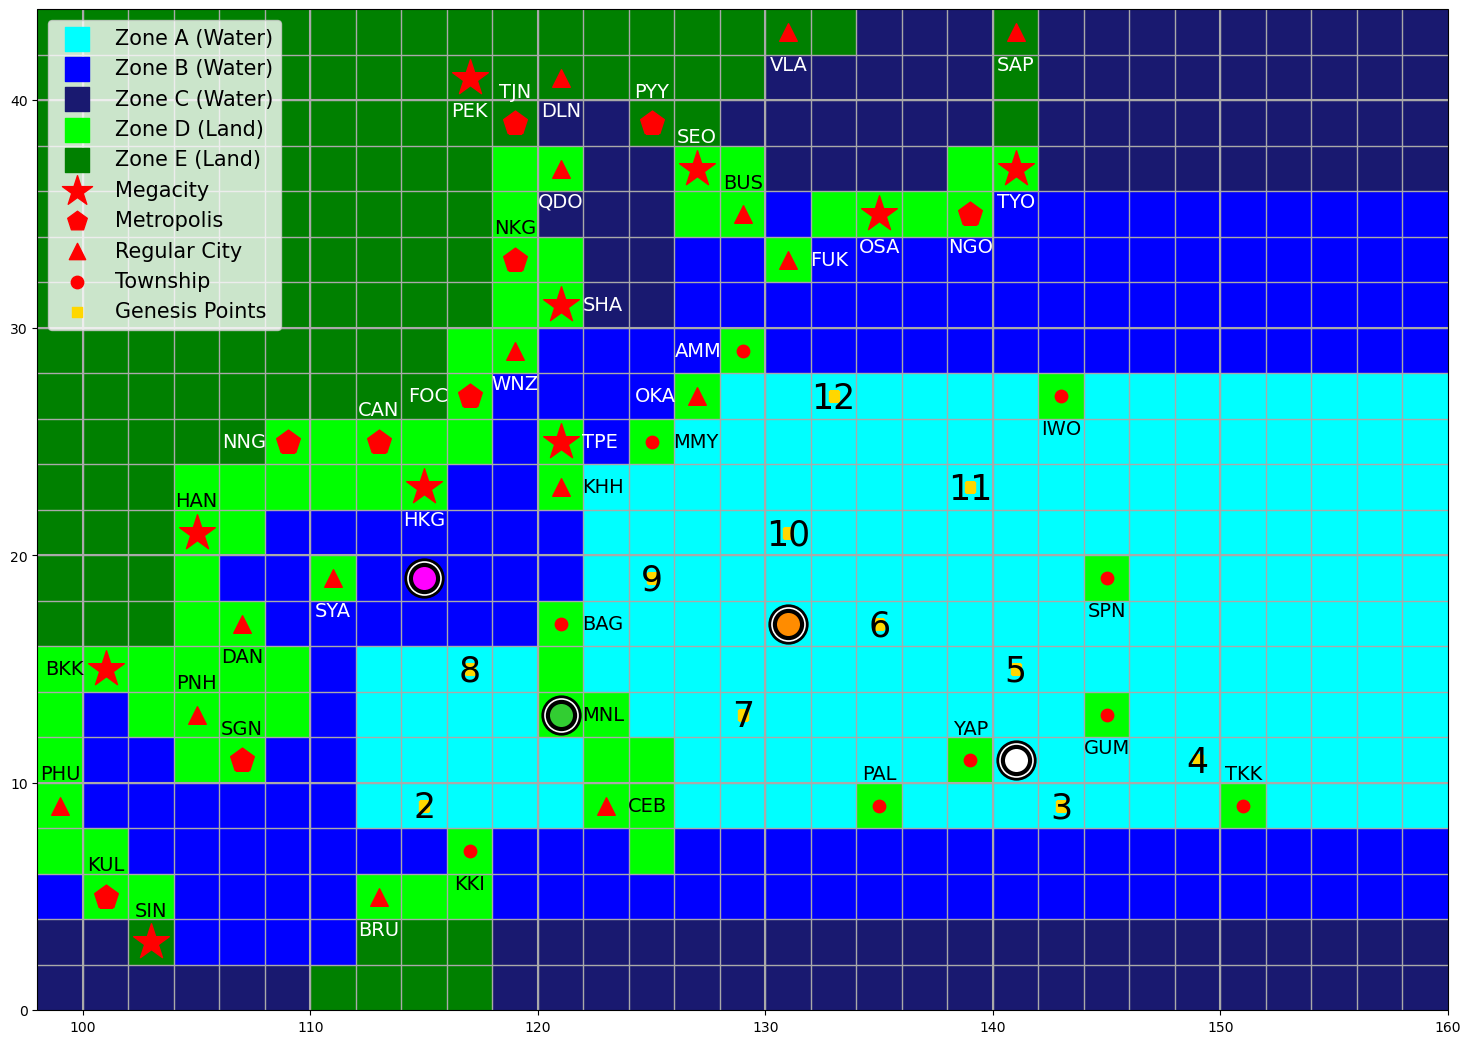

In [57]:
Run_Round(2, 2, Player_Data, Game_State, Player_Data_History, Game_State_History)


--- Round 2: Jin's turn ---


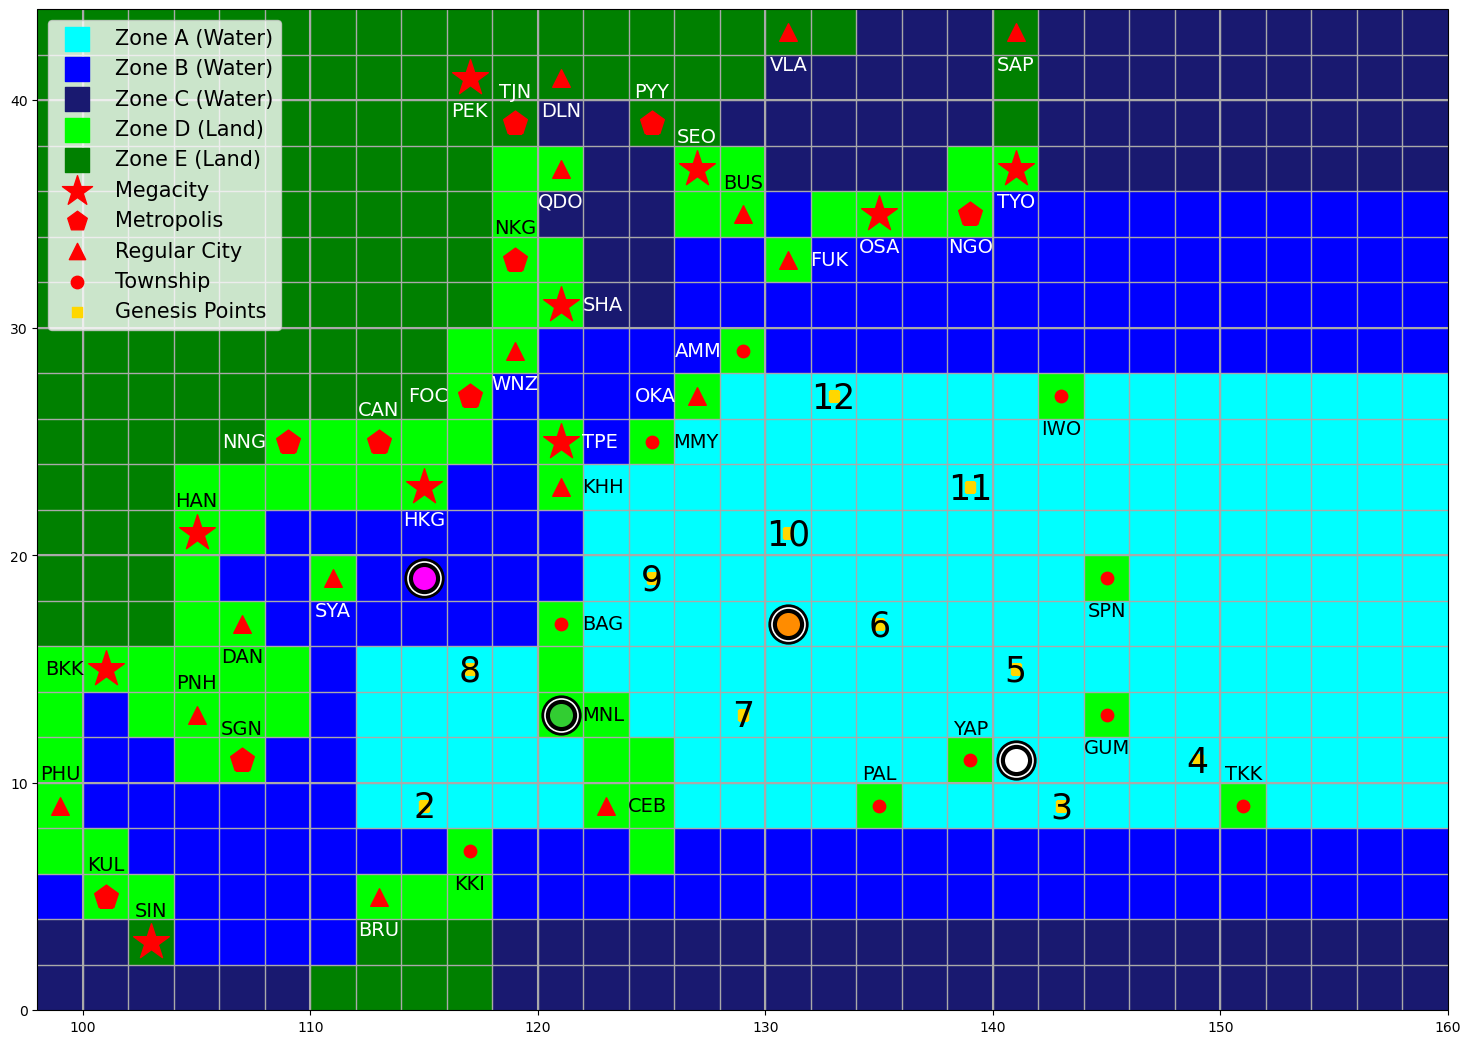

Intensity: 65 knots
ACE: 20 kJ
Landfall Costs: $0 M
Hand:
W/E 1
N 1
W ?
+5 W/m^2
+10 W/m^2
Random Teleportation
Extra Time

--- Round 2: Jin's draw phase ---
0: Movement Deck (55 cards left)
1: Intensity Deck (59 cards left)
2: Action Deck (22 cards left)


Choose a deck by index: 0


Jin drew: E 1 S 1 from Movement Deck.

0: Movement Deck (54 cards left)
1: Intensity Deck (59 cards left)
2: Action Deck (22 cards left)


Choose a deck by index: 2


Jin drew: Wrong Way Round from Action Deck.


--- Round 2: Jin's playing phase ---
Cards played this round: 0 / 3
Hand:
0: W/E 1
1: N 1
2: W ?
3: +5 W/m^2
4: +10 W/m^2
5: Random Teleportation
6: Extra Time
7: E 1 S 1
8: Wrong Way Round (cannot play)


Choose a card by index to play:  2


Jin played: W ?

Jin rolled 1: W 1


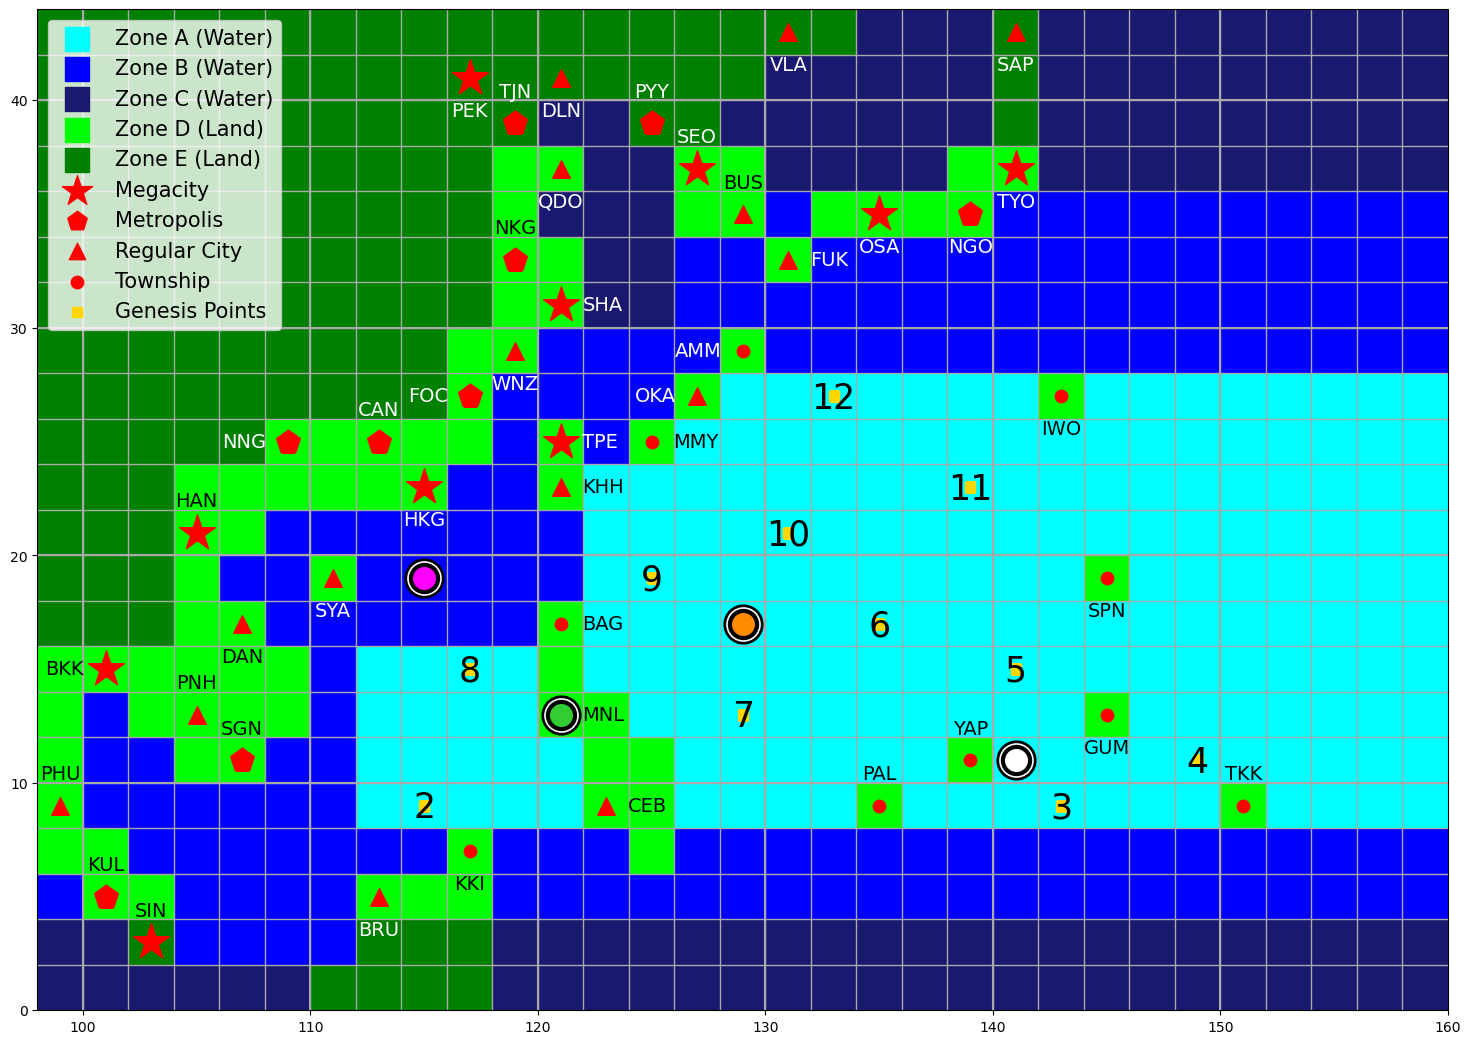


--- Round 2: Jin's playing phase ---
Cards played this round: 1 / 3
Hand:
0: W/E 1
1: N 1
2: +5 W/m^2
3: +10 W/m^2
4: Random Teleportation
5: Extra Time
6: E 1 S 1
7: Wrong Way Round (cannot play)
Enter 'p' to pass.


Choose a card by index to play:  3


Jin played: +10 W/m^2

Jin has intensified to 75 knots!

--- Round 2: Jin's playing phase ---
Cards played this round: 2 / 3
Hand:
0: W/E 1
1: N 1
2: +5 W/m^2
3: Random Teleportation
4: Extra Time
5: E 1 S 1
6: Wrong Way Round (cannot play)
Enter 'p' to pass.


Choose a card by index to play:  1


Jin played: N 1



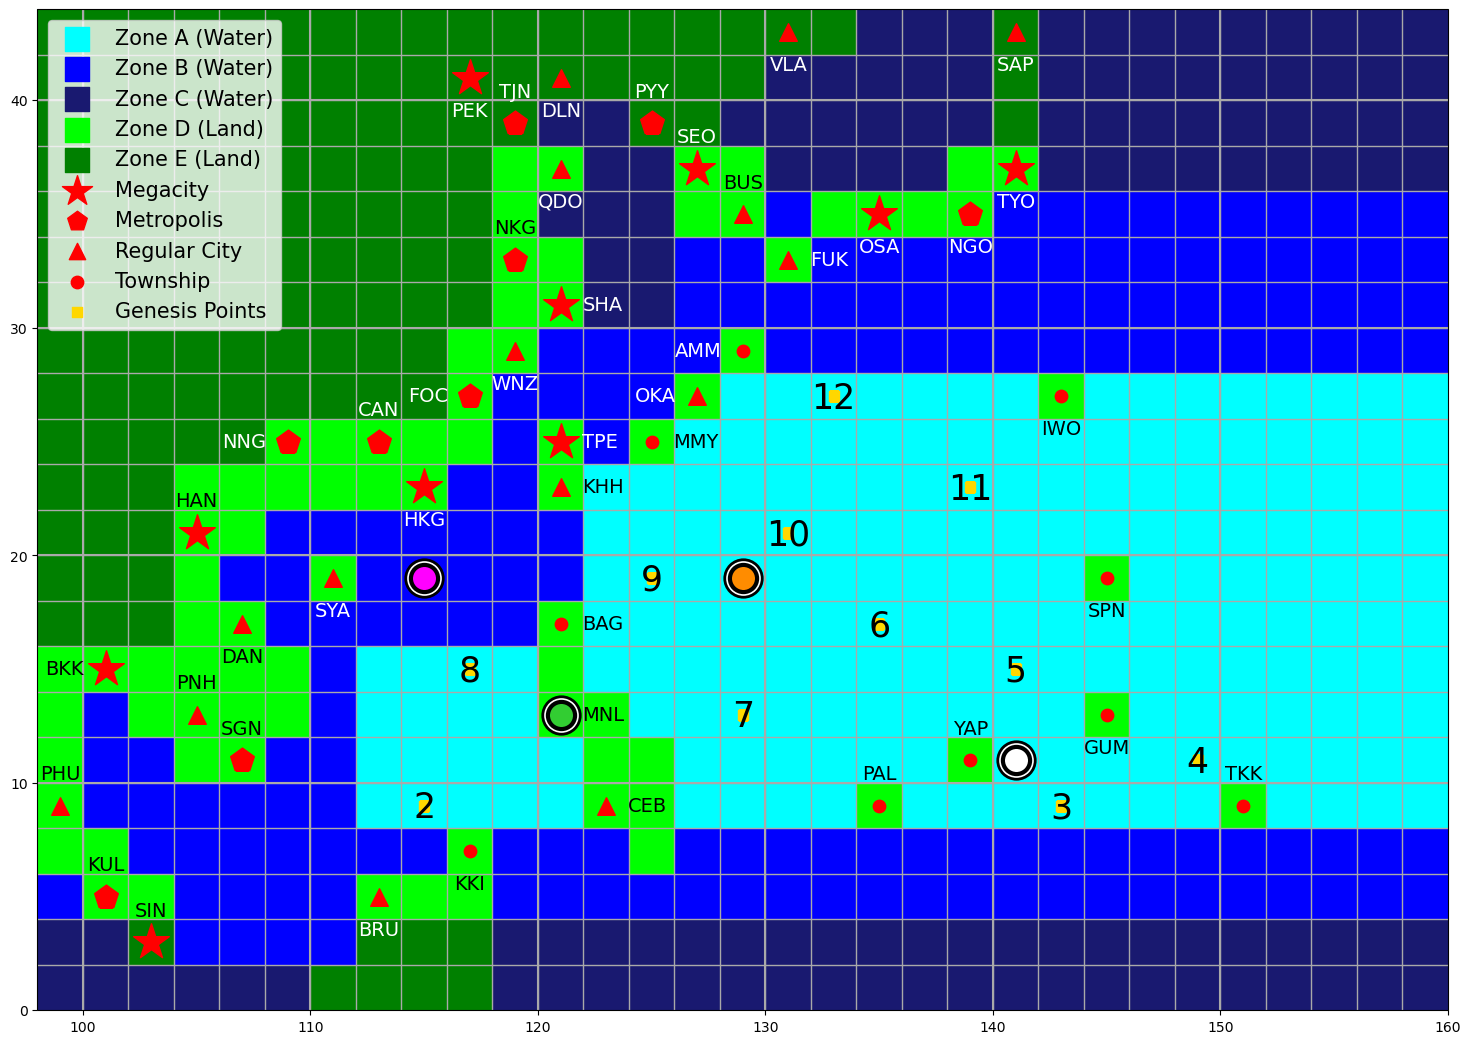


--- End of Jin's turn ---
Jin's current intensity: 75 knots.
Jin has gained 20 kJ. Current ACE: 40 kJ.
The ocean has 840 kJ of energy remaining.


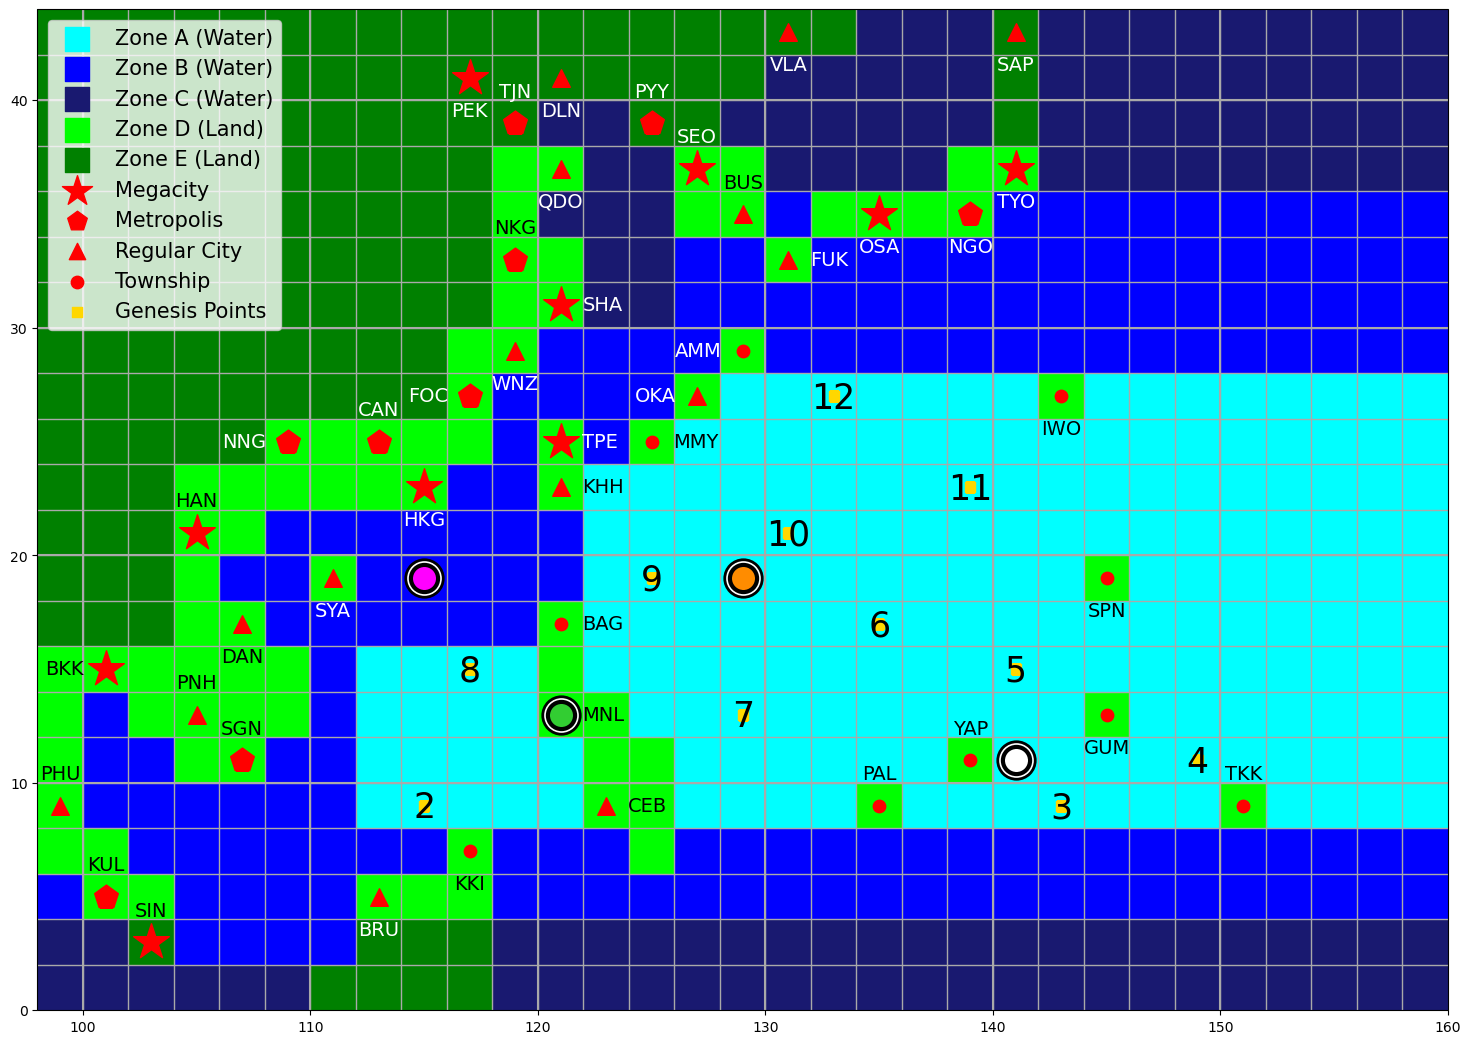

In [58]:
Run_Round(2, 3, Player_Data, Game_State, Player_Data_History, Game_State_History)


--- Round 2: Jason's turn ---


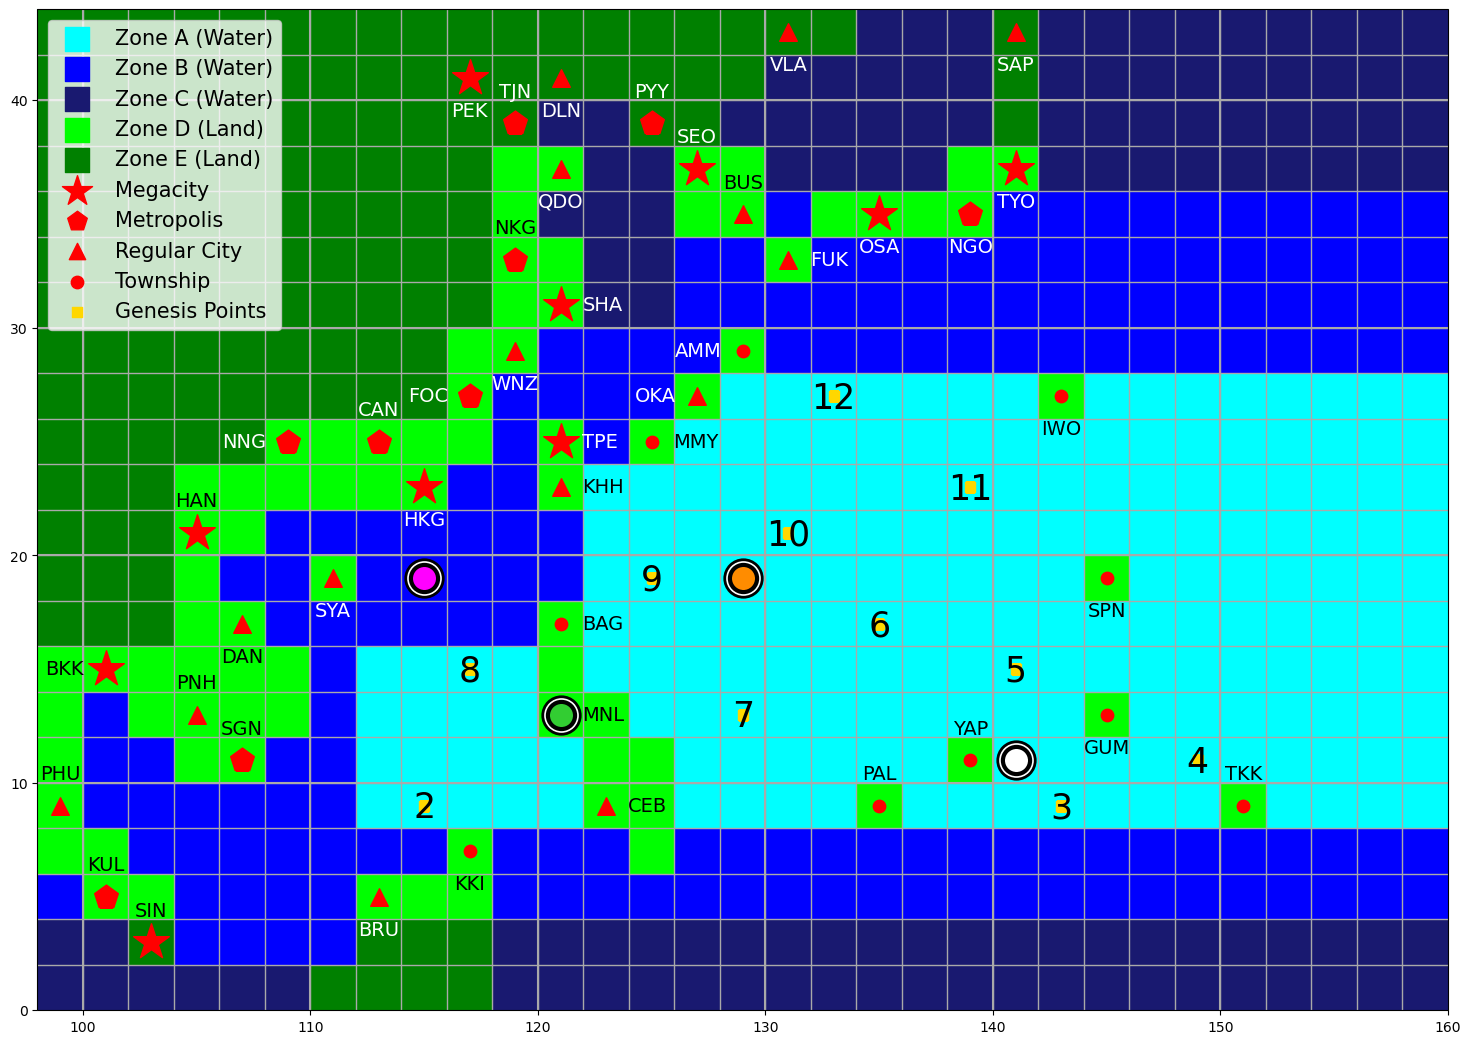

Intensity: 45 knots
ACE: 10 kJ
Landfall Costs: $0 M
Hand:
E 1
W/E/N/S 1
E 1
+5 W/m^2
+5 W/m^2
Cyclone Express
Rapid Intensification

--- Round 2: Jason's draw phase ---
0: Movement Deck (54 cards left)
1: Intensity Deck (59 cards left)
2: Action Deck (21 cards left)


Choose a deck by index: 1


Jason drew: +15 W/m^2 from Intensity Deck.

0: Movement Deck (54 cards left)
1: Intensity Deck (58 cards left)
2: Action Deck (21 cards left)


Choose a deck by index: 1


Jason drew: +5 W/m^2 from Intensity Deck.


--- Round 2: Jason's playing phase ---
Cards played this round: 0 / 3
Hand:
0: E 1
1: W/E/N/S 1
2: E 1
3: +5 W/m^2
4: +5 W/m^2
5: Cyclone Express (cannot play)
6: Rapid Intensification (cannot play)
7: +15 W/m^2
8: +5 W/m^2


...

Jason played: +15 W/m^2

Jason has intensified to 60 knots!

--- Round 2: Jason's playing phase ---
Cards played this round: 1 / 3
Hand:
0: E 1
1: W/E/N/S 1
2: E 1
3: +5 W/m^2
4: +5 W/m^2
5: Cyclone Express (cannot play)
6: Rapid Intensification
7: +5 W/m^2
Enter 'p' to pass.


Choose a card by index to play:  7


Jason played: +5 W/m^2

Jason has intensified to 65 knots!

--- Round 2: Jason's playing phase ---
Cards played this round: 2 / 3
Hand:
0: E 1
1: W/E/N/S 1
2: E 1
3: +5 W/m^2
4: +5 W/m^2
5: Cyclone Express (cannot play)
6: Rapid Intensification
Enter 'p' to pass.


Choose a card by index to play:  4


Jason played: +5 W/m^2

Jason has intensified to 70 knots!

--- End of Jason's turn ---
Jason's current intensity: 70 knots.
Jason has gained 20 kJ. Current ACE: 30 kJ.
The ocean has 820 kJ of energy remaining.


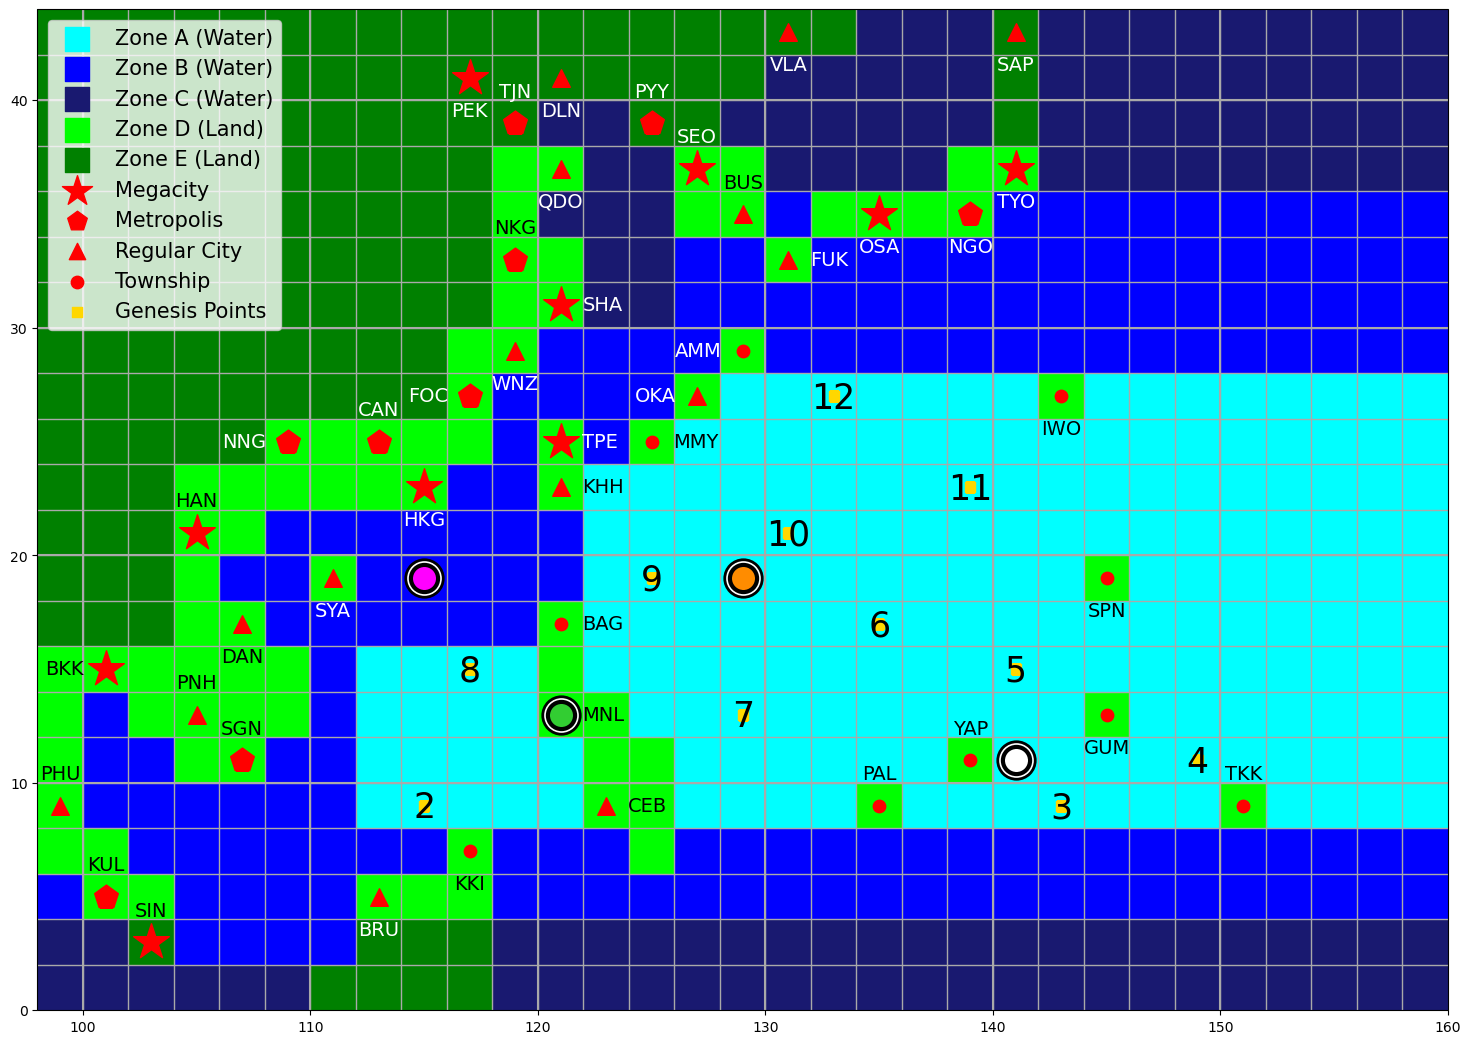

In [59]:
Run_Round(2, 4, Player_Data, Game_State, Player_Data_History, Game_State_History)


--- Round 3: Demi's turn ---


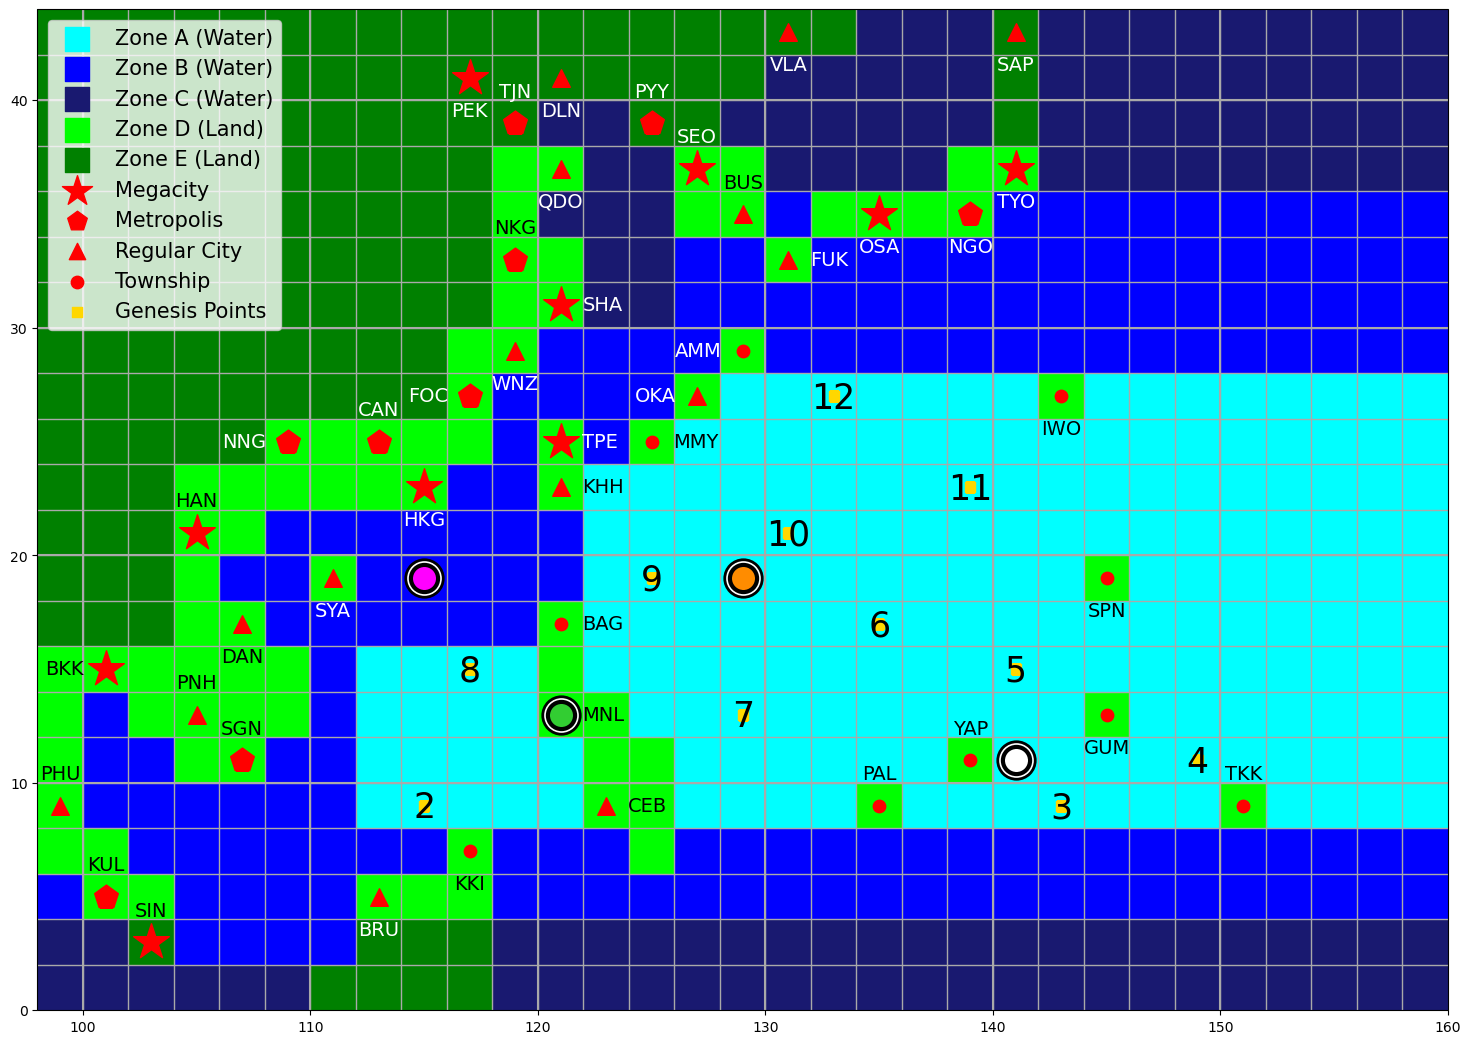

Intensity: 65 knots
ACE: 40 kJ
Landfall Costs: $130 M
Hand:
E 1 N 1
W 1 S 1
N ?
+5 W/m^2
City Fortress
Survival of the Fittest

--- Round 3: Demi's draw phase ---
0: Movement Deck (54 cards left)
1: Intensity Deck (57 cards left)
2: Action Deck (21 cards left)


Choose a deck by index: 1


Demi drew: +5 W/m^2 from Intensity Deck.

0: Movement Deck (54 cards left)
1: Intensity Deck (56 cards left)
2: Action Deck (21 cards left)


Choose a deck by index: 0


Demi drew: S ? from Movement Deck.


--- Round 3: Demi's playing phase ---
Cards played this round: 0 / 3
Hand:
0: E 1 N 1
1: W 1 S 1
2: N ?
3: +5 W/m^2
4: City Fortress
5: Survival of the Fittest
6: +5 W/m^2
7: S ?


Choose a card by index to play:  2


Demi played: N ?

Demi rolled 2: N 2


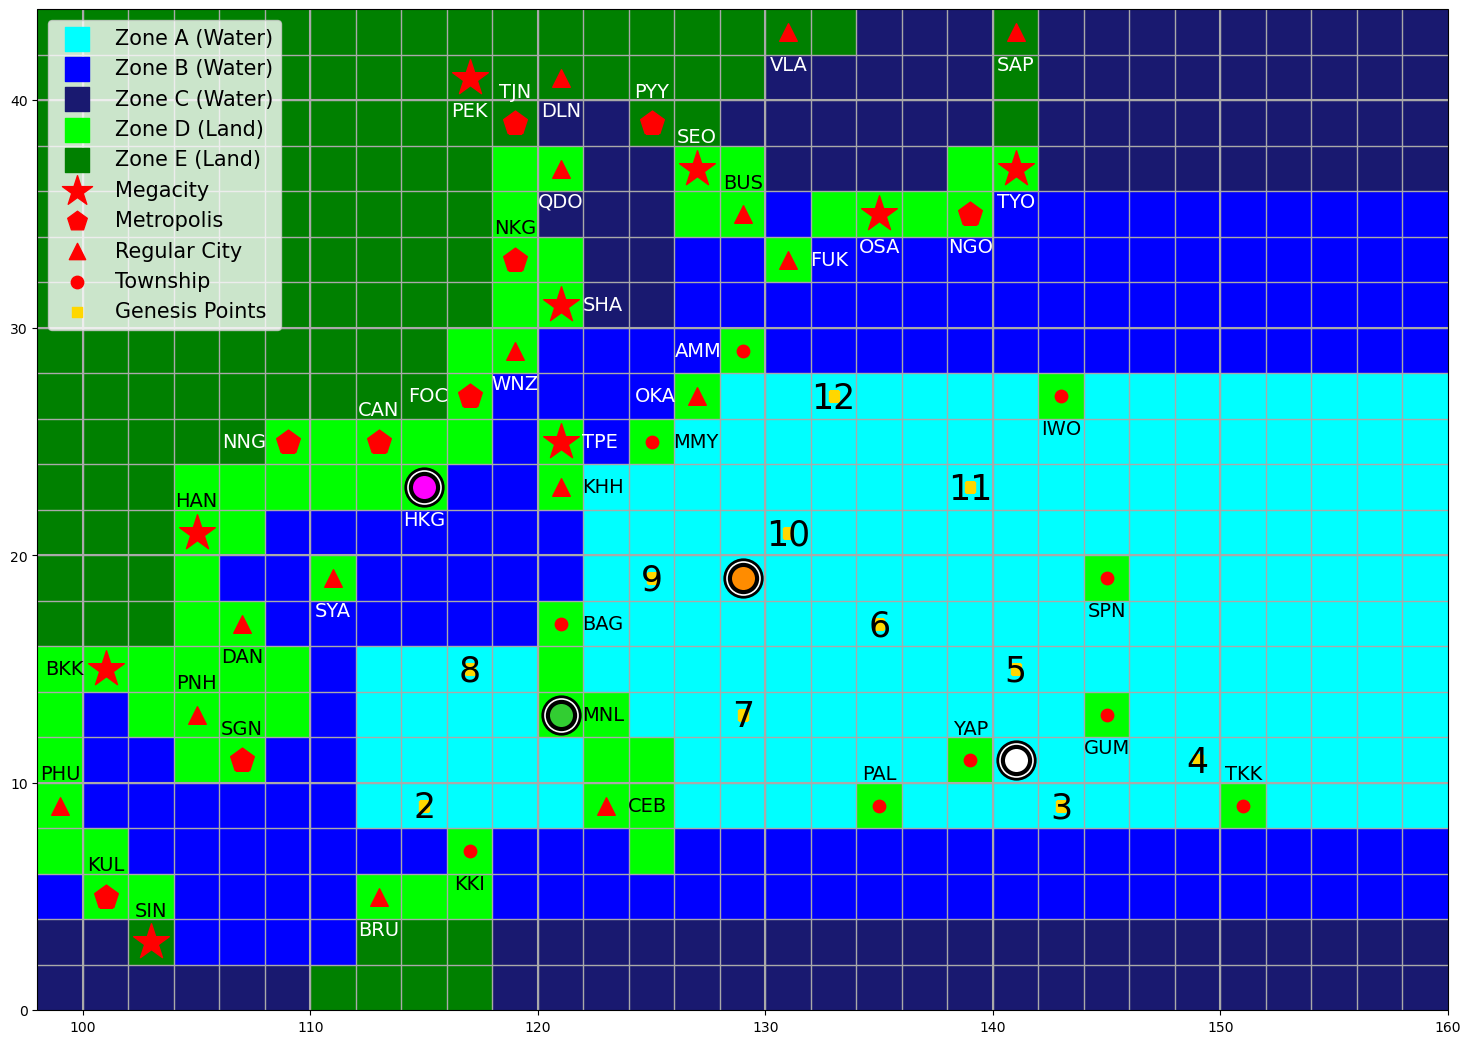

Demi has made landfall at HKG (Hong Kong) and gains $325M!
Remaining budget of HKG (Hong Kong): $1175M

--- Round 3: Demi's playing phase ---
Cards played this round: 1 / 3
Hand:
0: E 1 N 1
1: W 1 S 1
2: +5 W/m^2 (cannot play)
3: City Fortress
4: Survival of the Fittest
5: +5 W/m^2 (cannot play)
6: S ?
Enter 'p' to pass.


Choose a card by index to play:  4


Demi played: Survival of the Fittest

Demi is immune from any weakening for the next 3 rounds.

--- Round 3: Demi's playing phase ---
Cards played this round: 2 / 3
Hand:
0: E 1 N 1
1: W 1 S 1
2: +5 W/m^2 (cannot play)
3: City Fortress
4: +5 W/m^2 (cannot play)
5: S ?
Enter 'p' to pass.


Choose a card by index to play:  0


Demi played: E 1 N 1



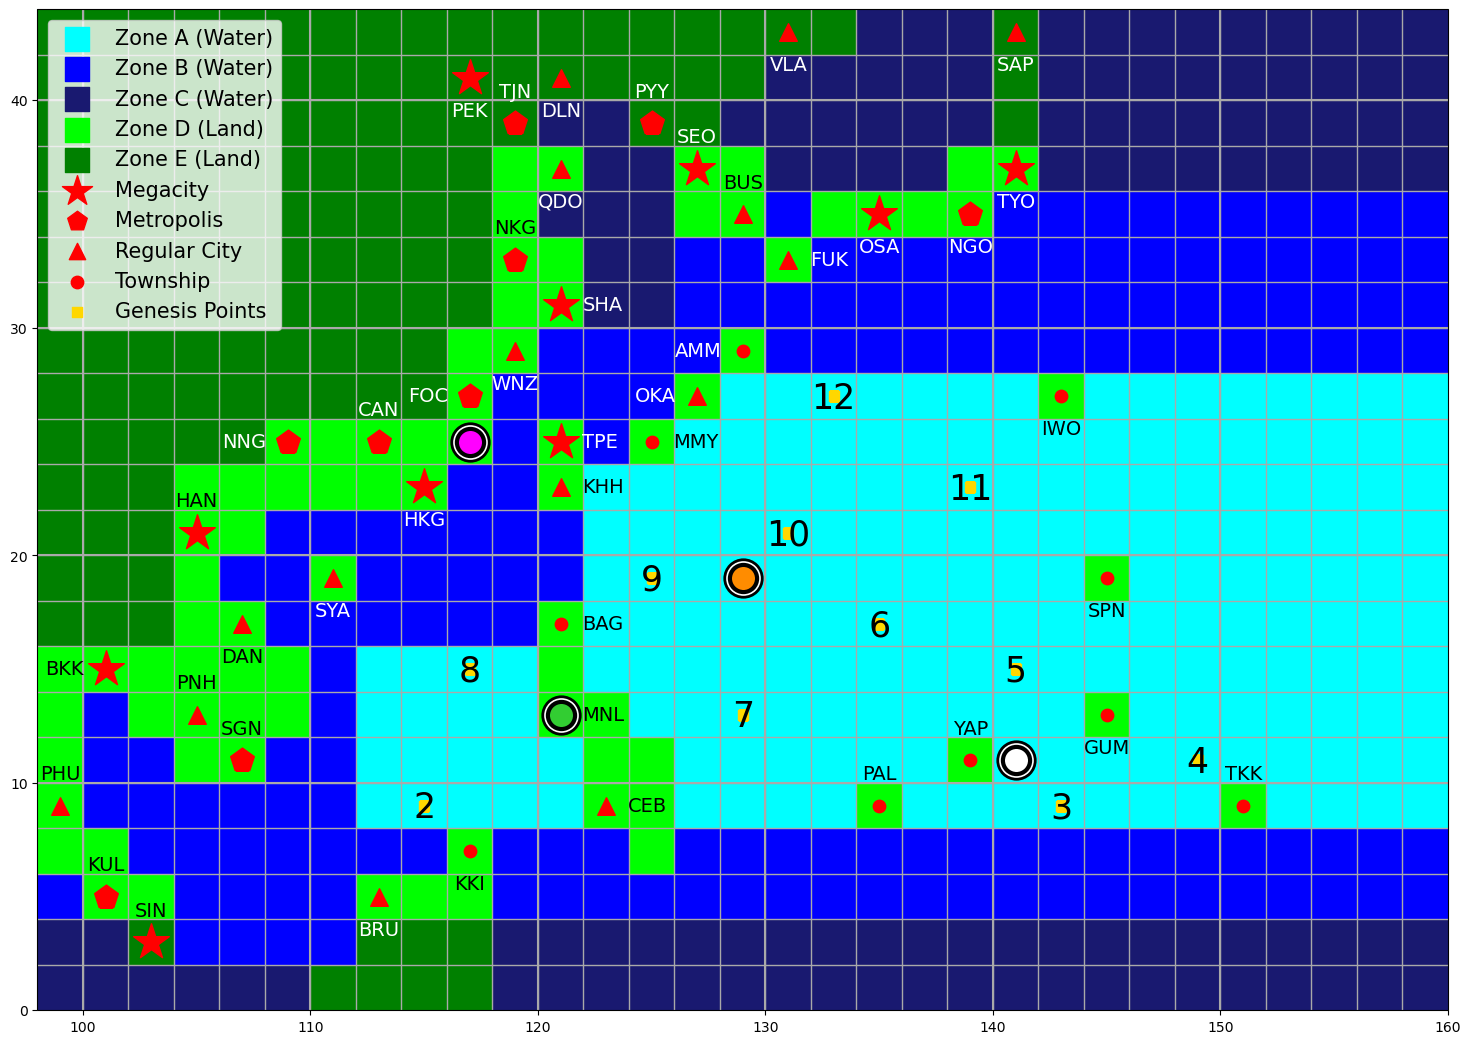


--- End of Demi's turn ---
Demi's current intensity: 65 knots.
Demi has gained 20 kJ. Current ACE: 60 kJ.
The ocean has 800 kJ of energy remaining.


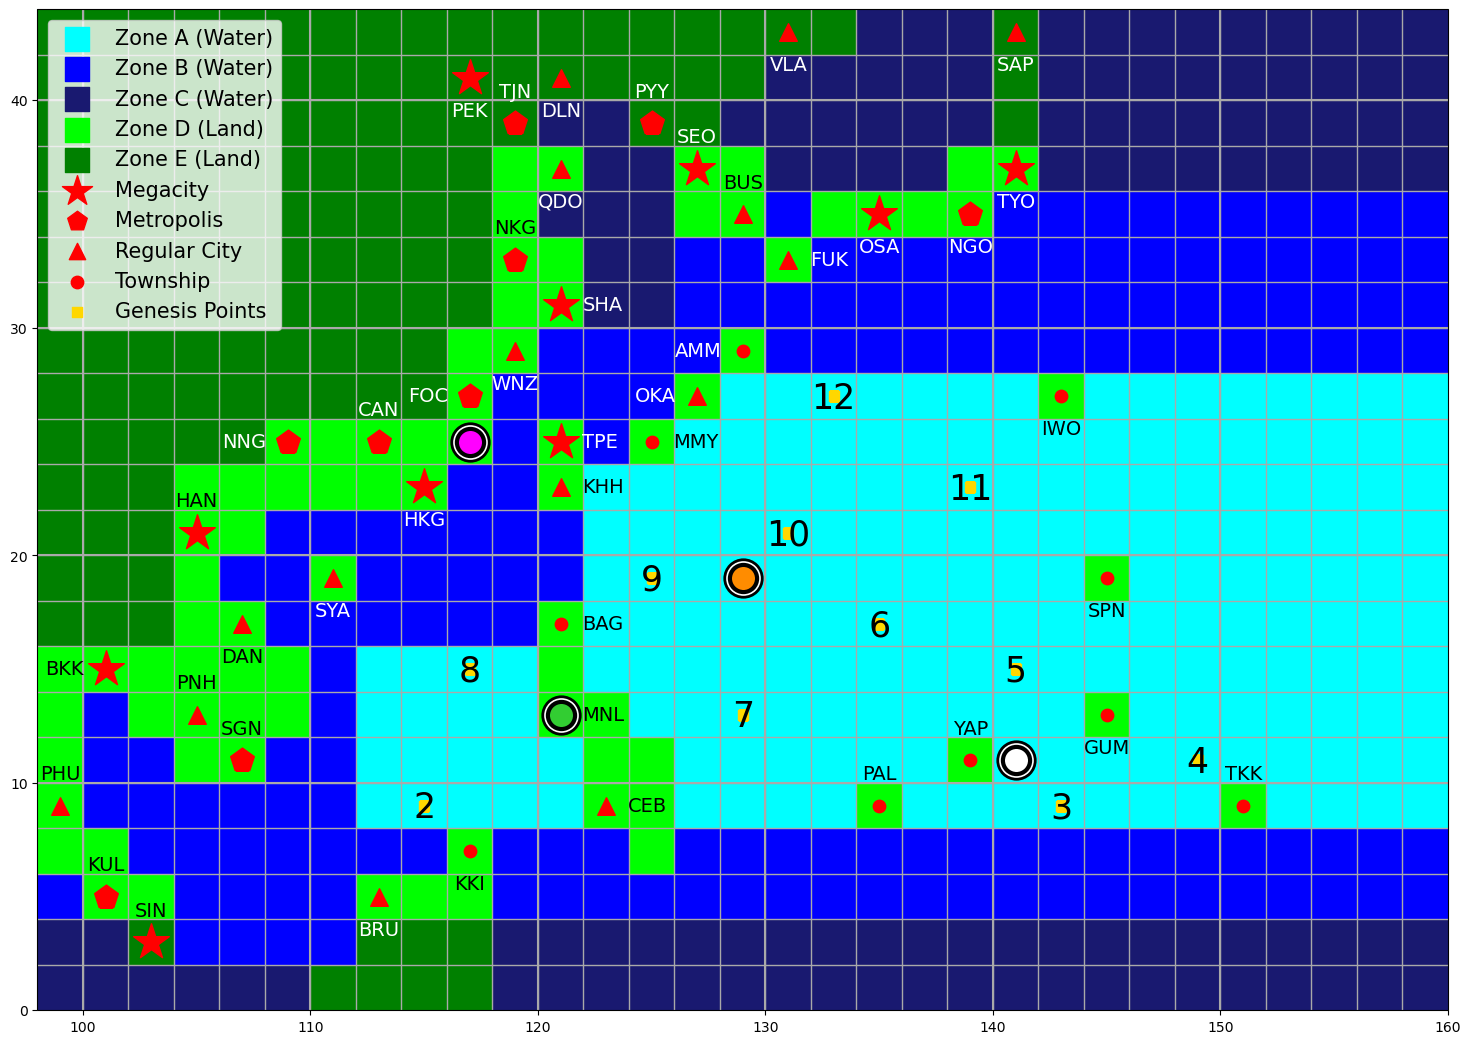

In [60]:
Run_Round(3, 1, Player_Data, Game_State, Player_Data_History, Game_State_History)


--- Round 3: Kinen's turn ---


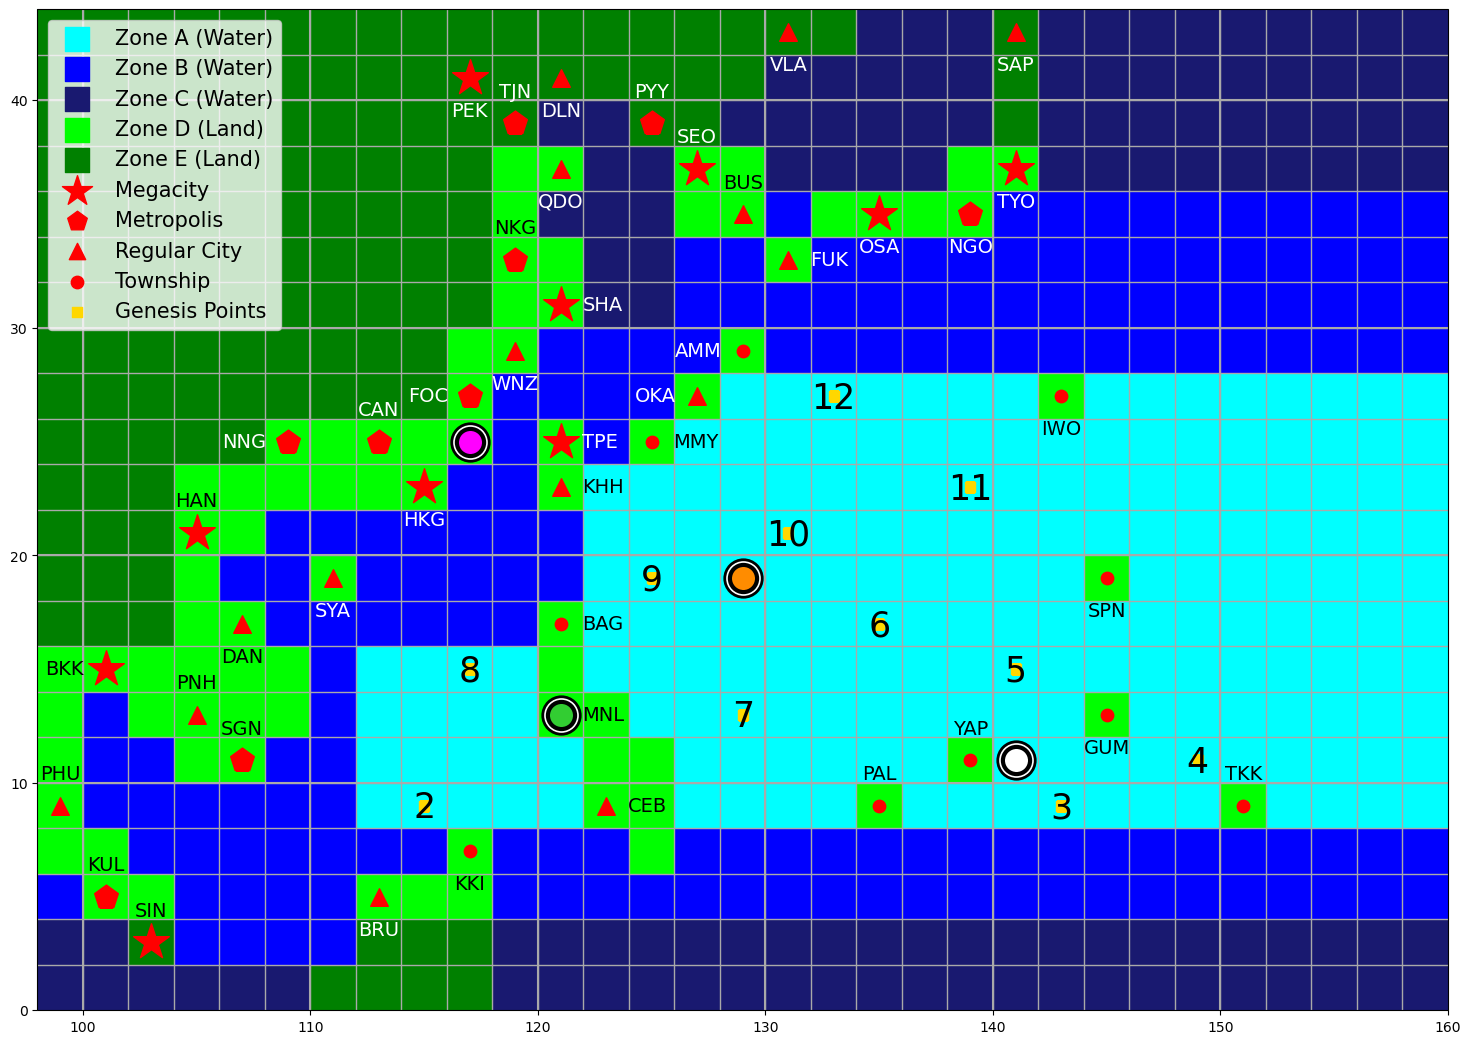

Intensity: 95 knots
ACE: 70 kJ
Landfall Costs: $300 M
Hand:
N 5
N 1
E 1 N 1
+20 W/m^2
Factory Reset
E 2 S 1

--- Round 3: Kinen's draw phase ---
0: Movement Deck (53 cards left)
1: Intensity Deck (56 cards left)
2: Action Deck (21 cards left)


Choose a deck by index: 0


Kinen drew: E 3 from Movement Deck.

0: Movement Deck (52 cards left)
1: Intensity Deck (56 cards left)
2: Action Deck (21 cards left)


Choose a deck by index: 0


Kinen drew: W 1 N 1 from Movement Deck.


--- Round 3: Kinen's playing phase ---
Cards played this round: 0 / 3
Hand:
0: N 5
1: N 1
2: E 1 N 1
3: +20 W/m^2 (cannot play)
4: Factory Reset
5: E 2 S 1
6: E 3
7: W 1 N 1


Choose a card by index to play:  0


Kinen played: N 5



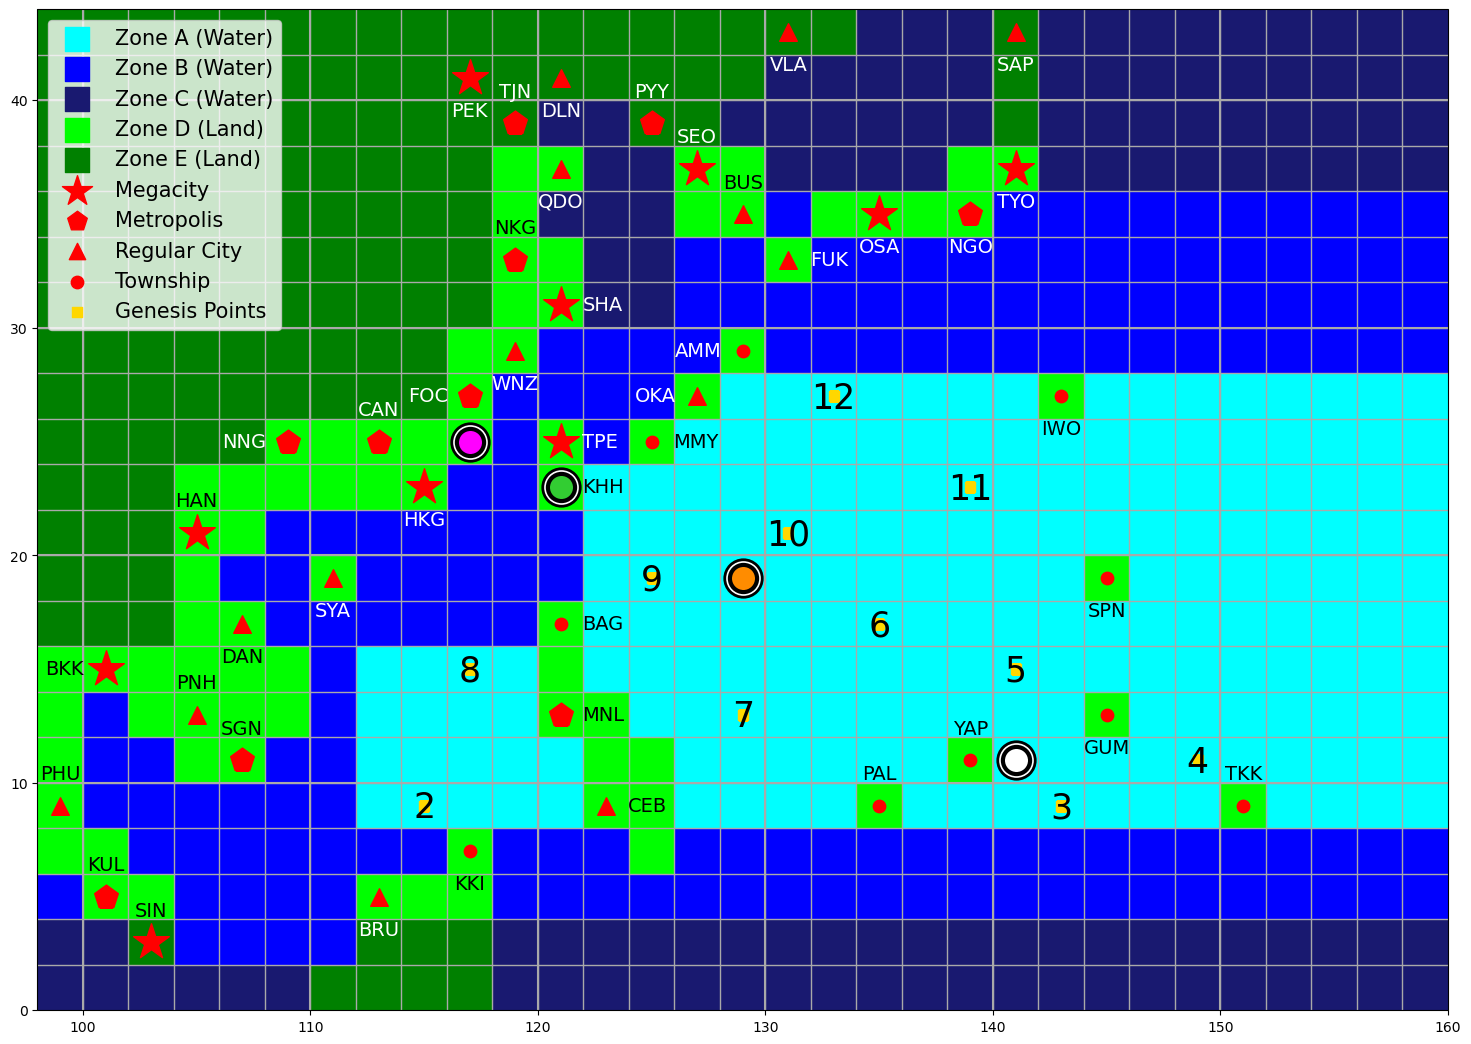

Kinen has made landfall at KHH (Kaohsiung) and gains $190M!
Remaining budget of KHH (Kaohsiung): $210M

--- Round 3: Kinen's playing phase ---
Cards played this round: 1 / 3
Hand:
0: N 1
1: E 1 N 1
2: +20 W/m^2 (cannot play)
3: Factory Reset
4: E 2 S 1
5: E 3
6: W 1 N 1
Enter 'p' to pass.


Choose a card by index to play:  0


Kinen played: N 1



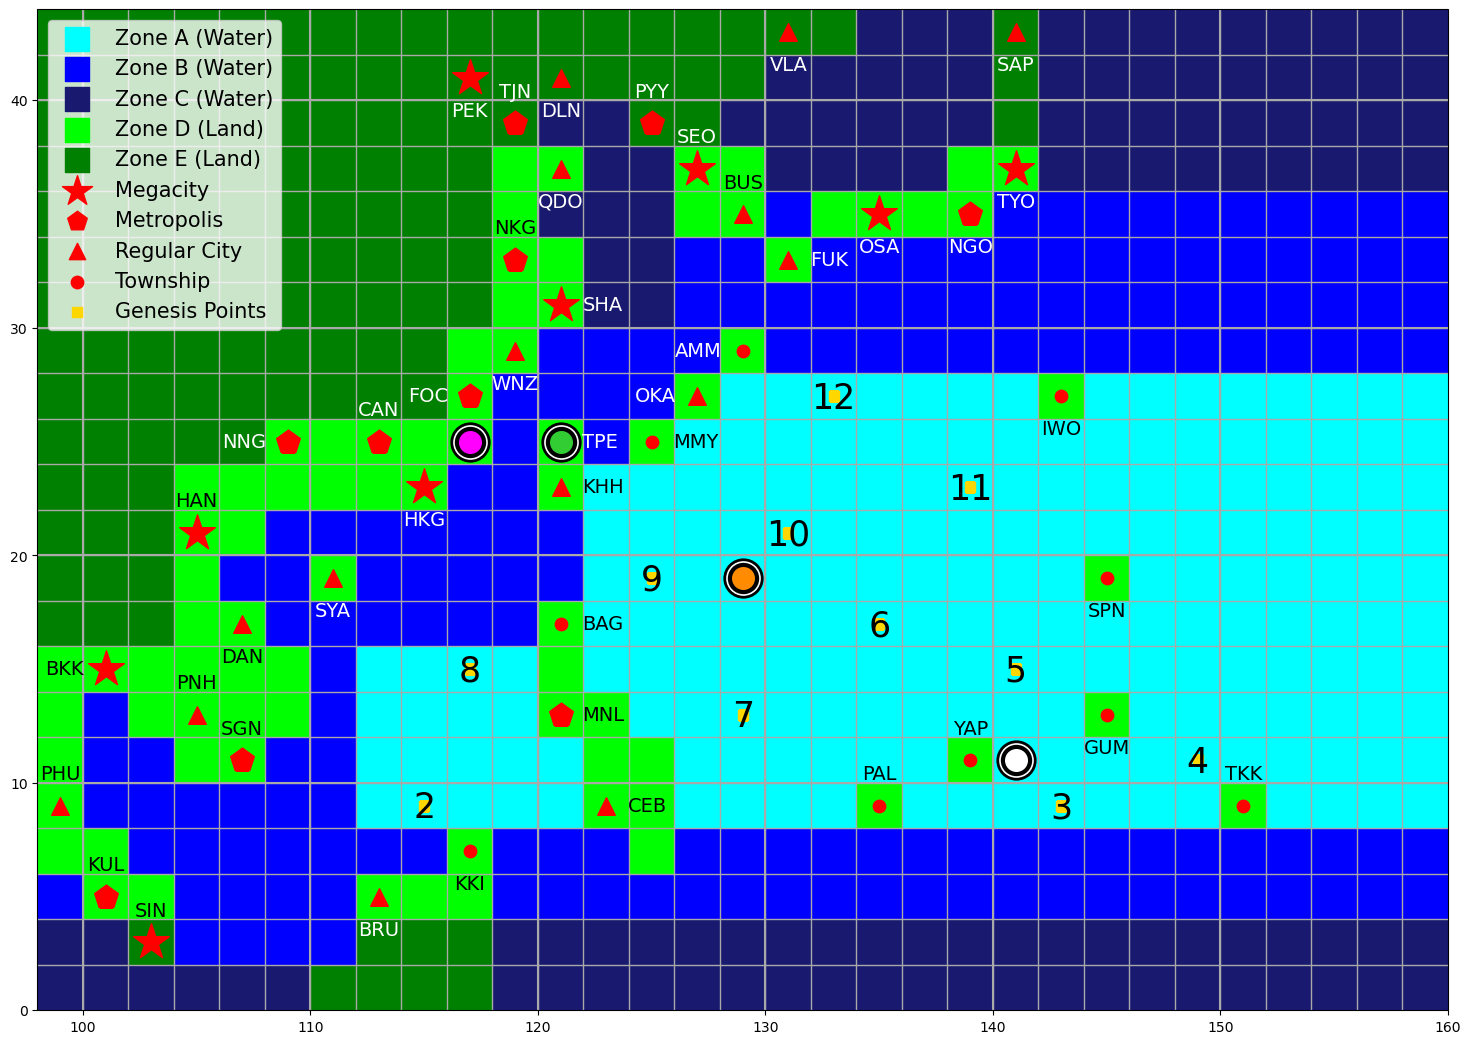

Kinen has made landfall at TPE (Taipei) and gains $475M!
Remaining budget of TPE (Taipei): $1025M

--- Round 3: Kinen's playing phase ---
Cards played this round: 2 / 3
Hand:
0: E 1 N 1
1: +20 W/m^2 (cannot play)
2: Factory Reset
3: E 2 S 1
4: E 3
5: W 1 N 1
Enter 'p' to pass.


Choose a card by index to play:  4


Kinen played: E 3



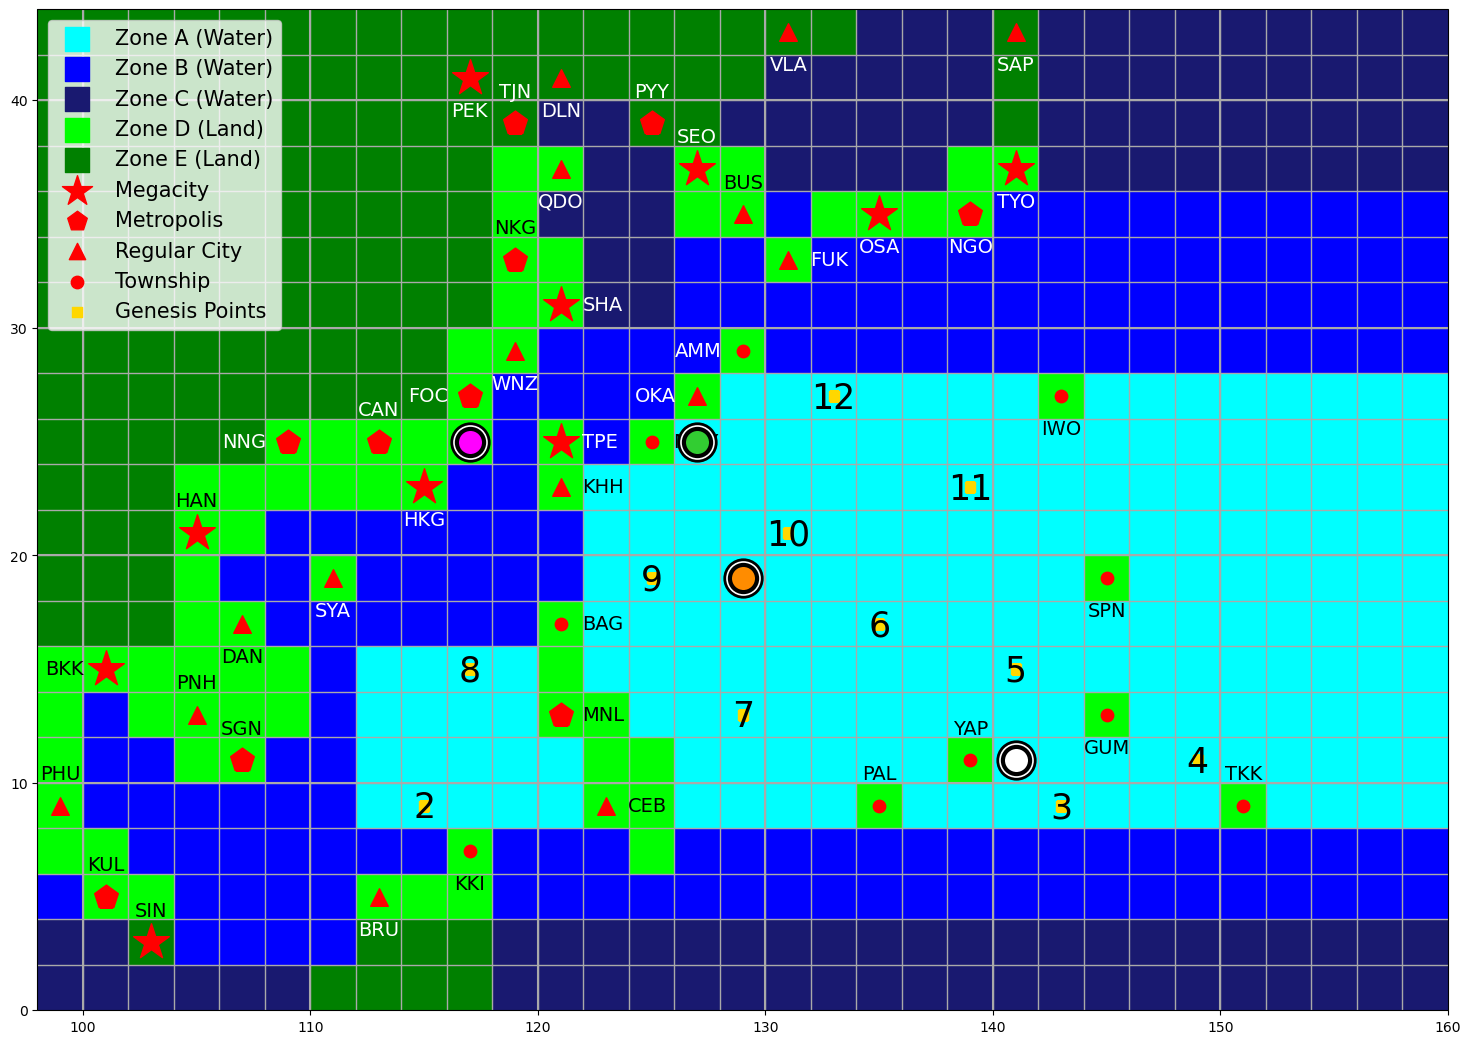


--- End of Kinen's turn ---
Kinen's current intensity: 95 knots.
Kinen has gained 30 kJ. Current ACE: 100 kJ.
The ocean has 770 kJ of energy remaining.


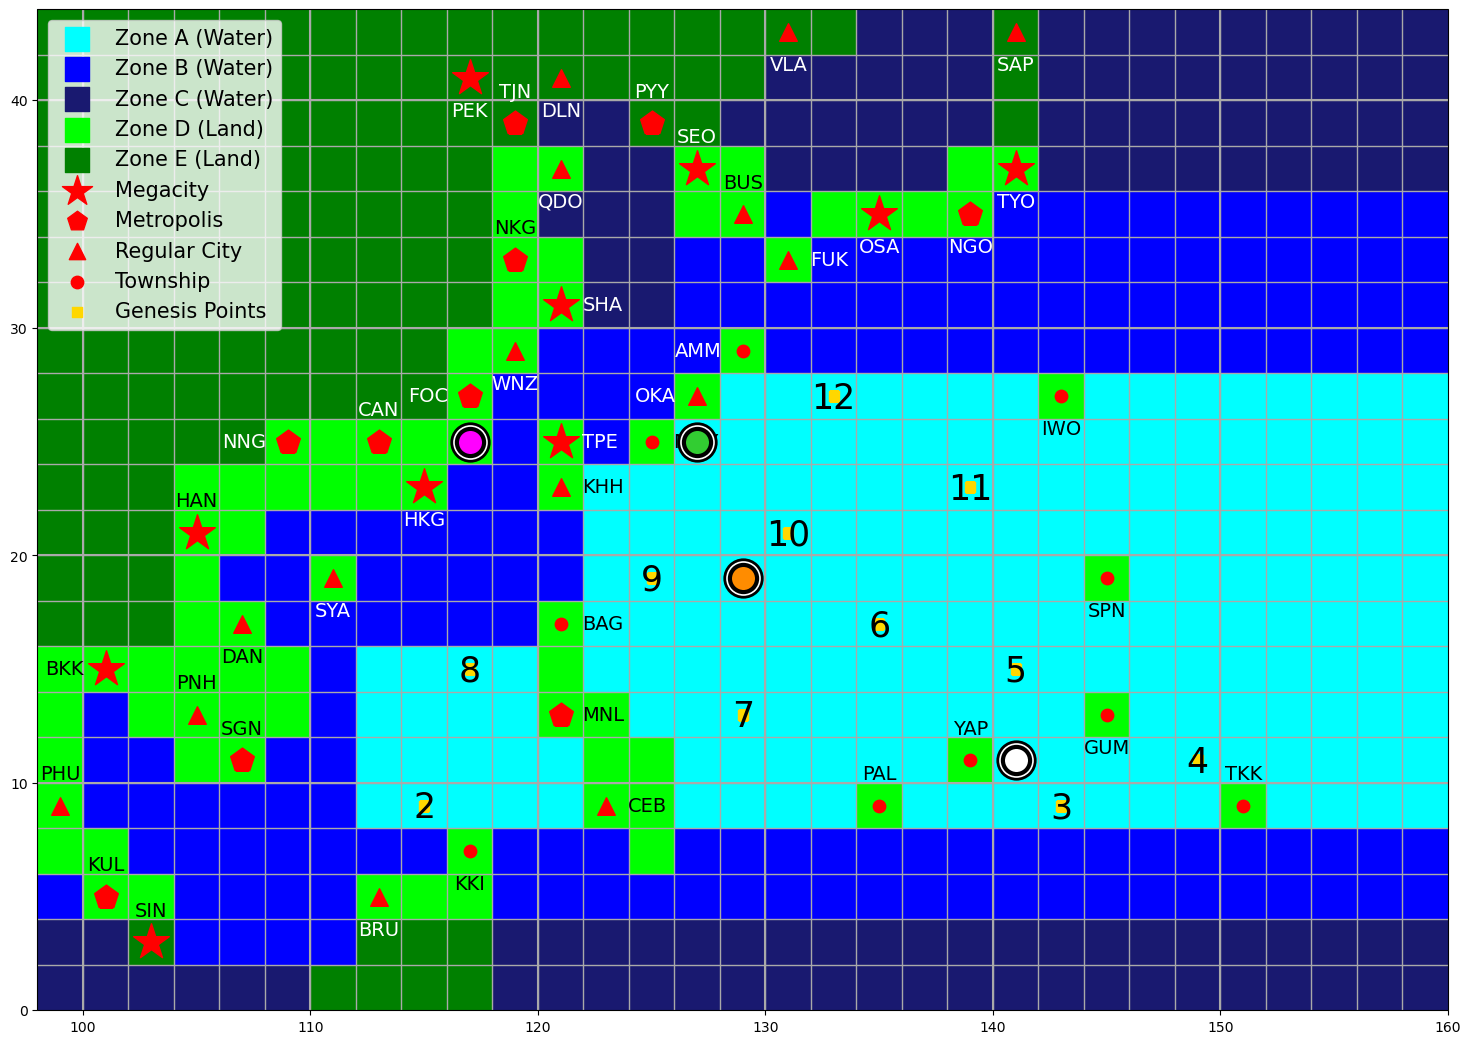

In [61]:
Run_Round(3, 2, Player_Data, Game_State, Player_Data_History, Game_State_History)


--- Round 3: Jin's turn ---


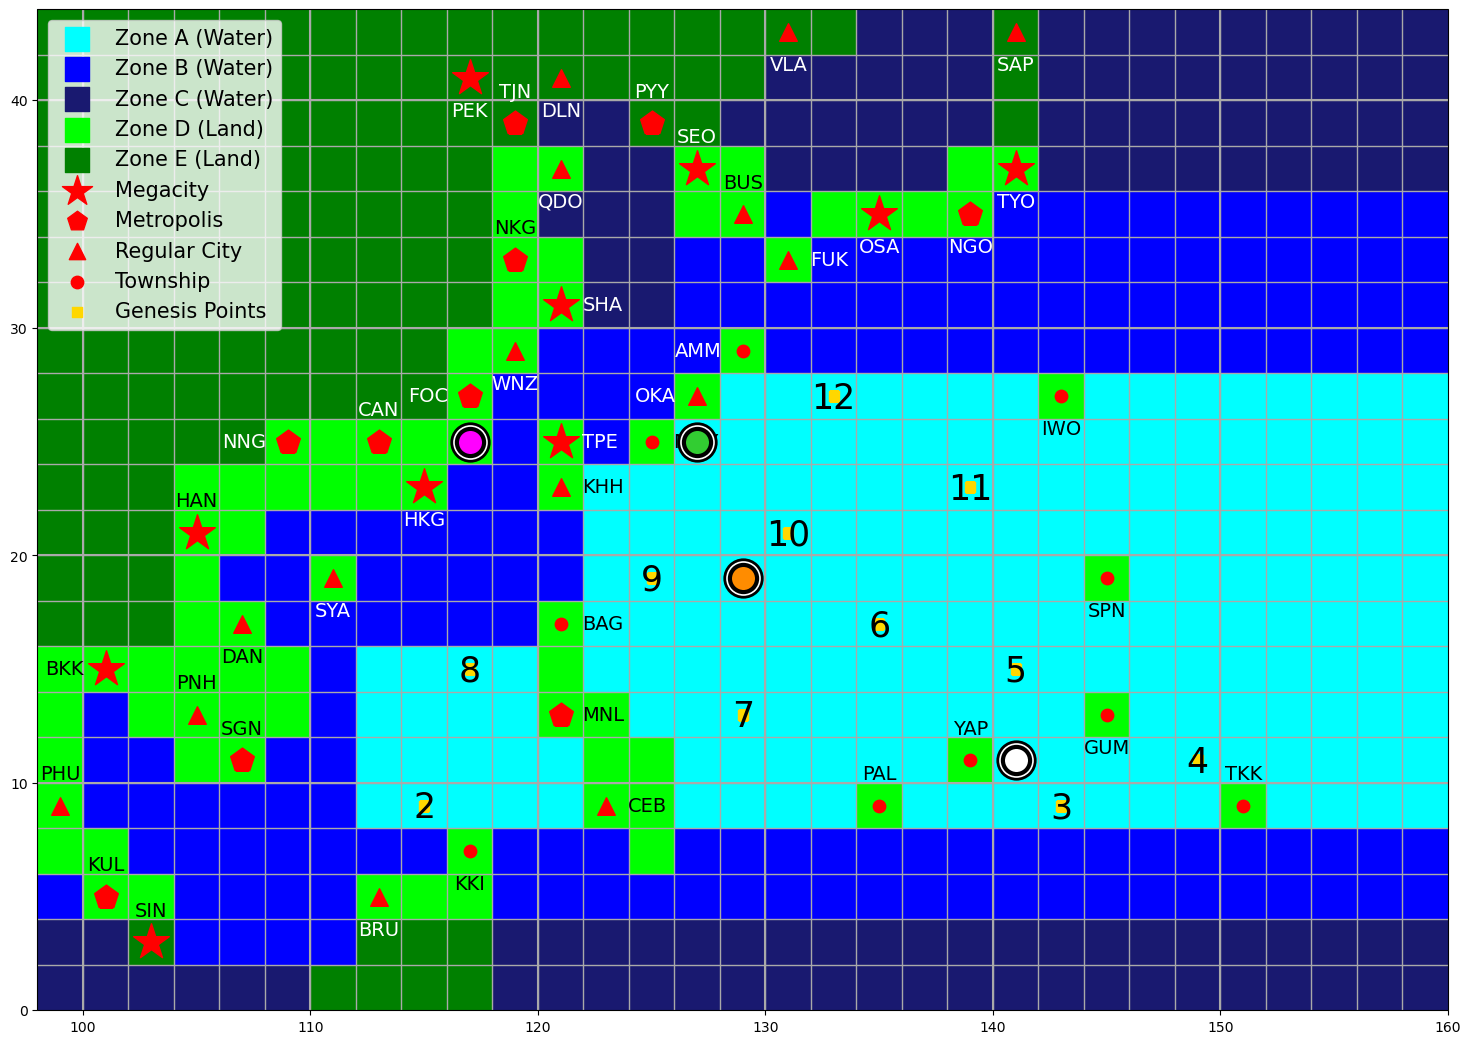

Intensity: 75 knots
ACE: 40 kJ
Landfall Costs: $0 M
Hand:
W/E 1
+5 W/m^2
Random Teleportation
Extra Time
E 1 S 1
Wrong Way Round

--- Round 3: Jin's draw phase ---
0: Movement Deck (51 cards left)
1: Intensity Deck (56 cards left)
2: Action Deck (21 cards left)


Choose a deck by index: 0


Jin drew: E 1 from Movement Deck.

0: Movement Deck (50 cards left)
1: Intensity Deck (56 cards left)
2: Action Deck (21 cards left)


Choose a deck by index: 1


Jin drew: +25 W/m^2 from Intensity Deck.


--- Round 3: Jin's playing phase ---
Cards played this round: 0 / 3
Hand:
0: W/E 1
1: +5 W/m^2
2: Random Teleportation
3: Extra Time
4: E 1 S 1
5: Wrong Way Round (cannot play)
6: E 1
7: +25 W/m^2


Choose a card by index to play:  7


Jin played: +25 W/m^2

Jin has intensified to 100 knots!

--- Round 3: Jin's playing phase ---
Cards played this round: 1 / 3
Hand:
0: W/E 1
1: +5 W/m^2
2: Random Teleportation
3: Extra Time
4: E 1 S 1
5: Wrong Way Round (cannot play)
6: E 1
Enter 'p' to pass.


Choose a card by index to play:  0


Jin played: W/E 1



Choose W or E:  W


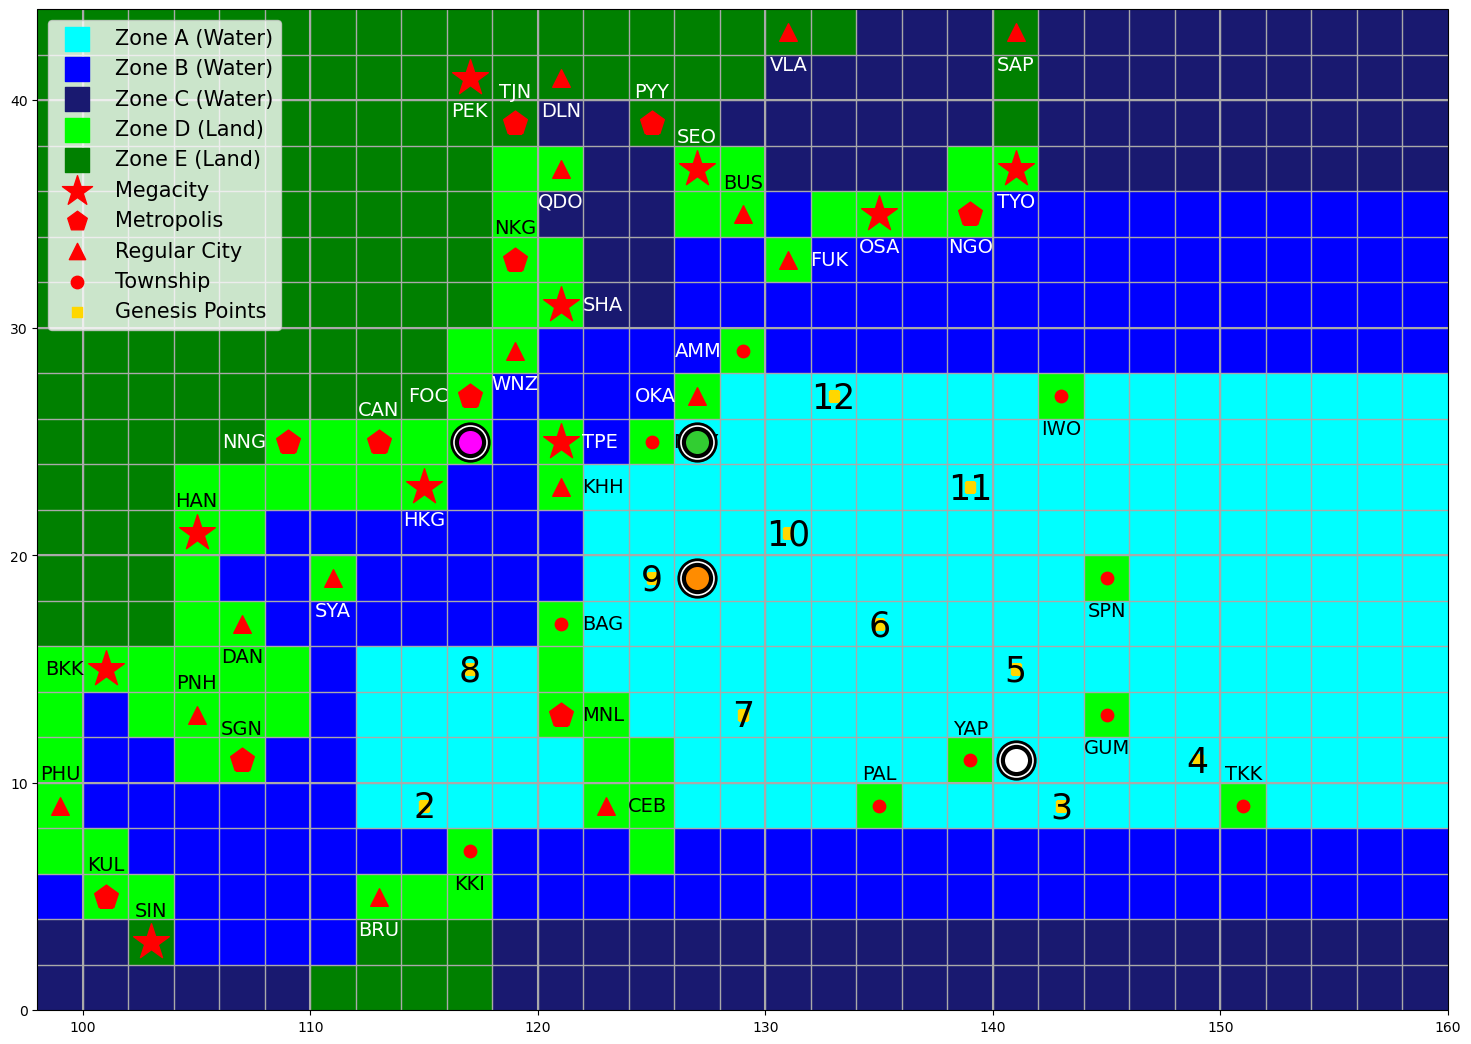


--- Round 3: Jin's playing phase ---
Cards played this round: 2 / 3
Hand:
0: +5 W/m^2
1: Random Teleportation
2: Extra Time
3: E 1 S 1
4: Wrong Way Round (cannot play)
5: E 1
Enter 'p' to pass.


Choose a card by index to play:  p


Jin passes.

--- End of Jin's turn ---
Jin's current intensity: 100 knots.
Jin has gained 50 kJ. Current ACE: 90 kJ.
The ocean has 720 kJ of energy remaining.


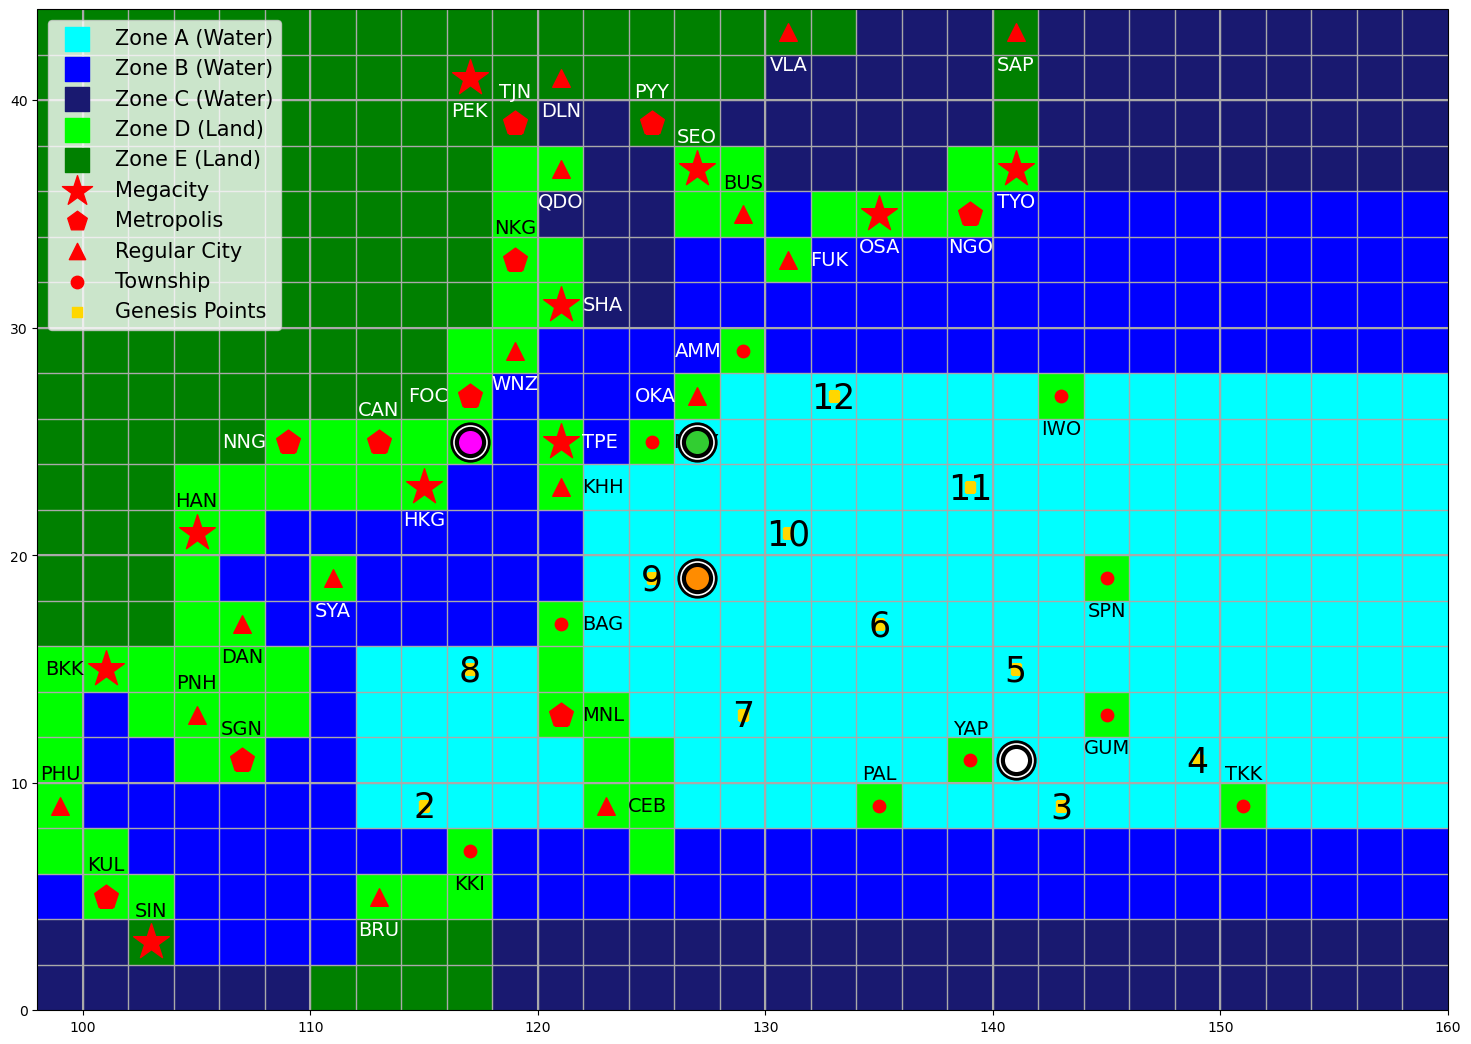

In [62]:
Run_Round(3, 3, Player_Data, Game_State, Player_Data_History, Game_State_History)


--- Round 3: Jason's turn ---


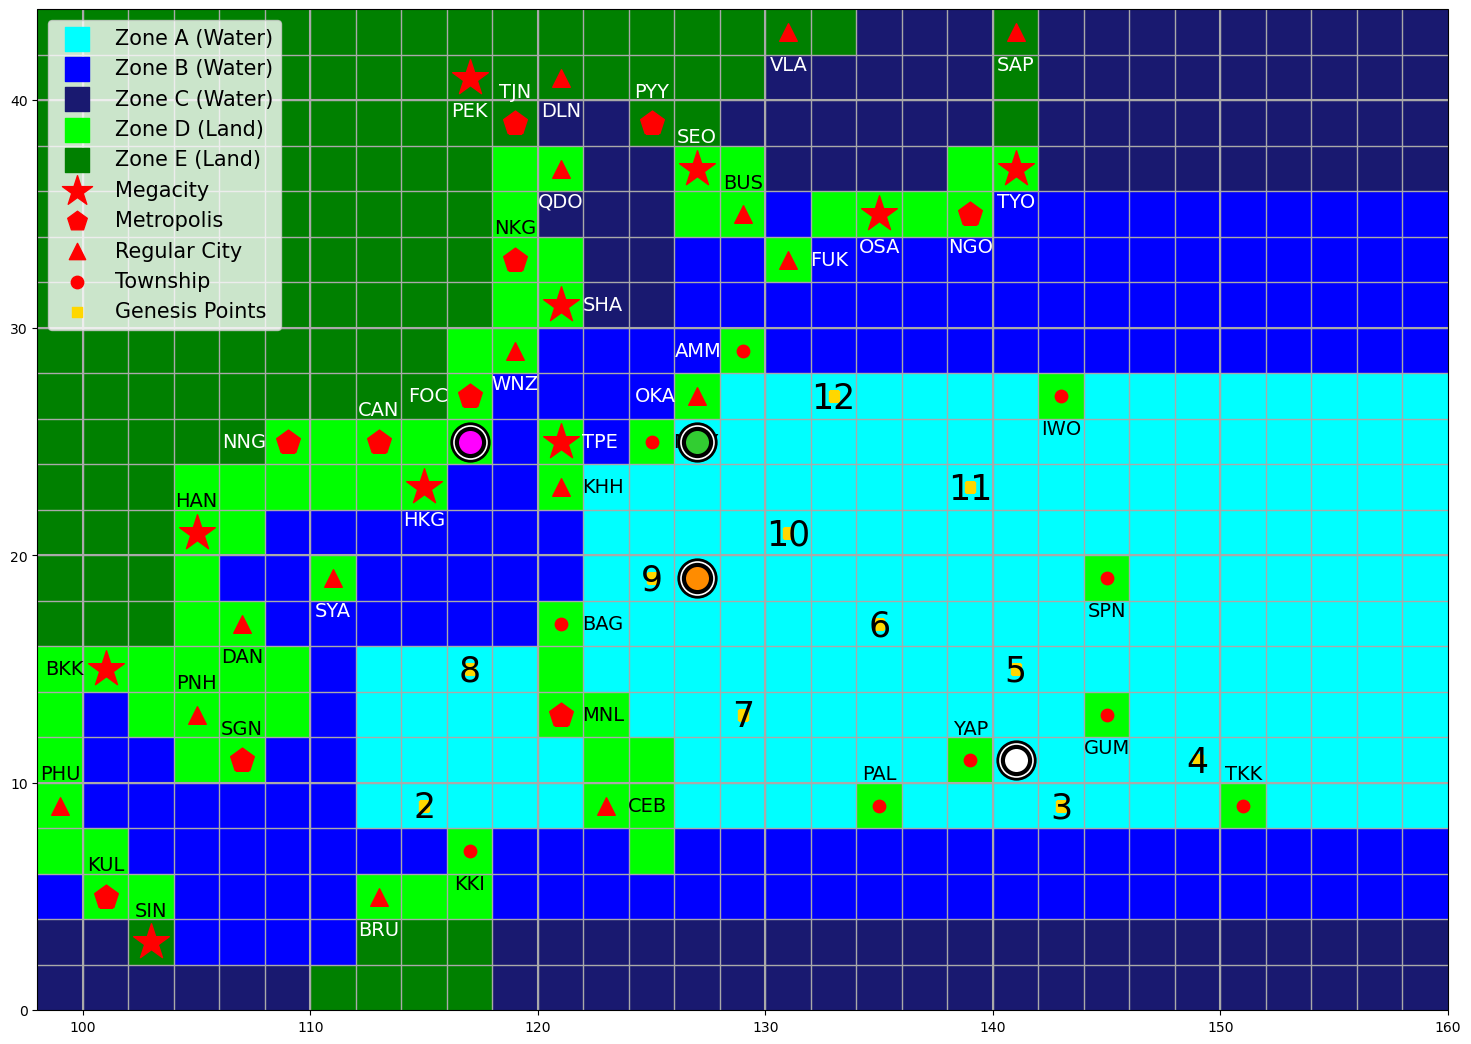

Intensity: 70 knots
ACE: 30 kJ
Landfall Costs: $0 M
Hand:
E 1
W/E/N/S 1
E 1
+5 W/m^2
Cyclone Express
Rapid Intensification

--- Round 3: Jason's draw phase ---
0: Movement Deck (50 cards left)
1: Intensity Deck (55 cards left)
2: Action Deck (21 cards left)


Choose a deck by index: 1


Jason drew: +15 W/m^2 from Intensity Deck.

0: Movement Deck (50 cards left)
1: Intensity Deck (54 cards left)
2: Action Deck (21 cards left)


Choose a deck by index: 1


Jason drew: +20 W/m^2 from Intensity Deck.


--- Round 3: Jason's playing phase ---
Cards played this round: 0 / 3
Hand:
0: E 1
1: W/E/N/S 1
2: E 1
3: +5 W/m^2
4: Cyclone Express (cannot play)
5: Rapid Intensification (cannot play)
6: +15 W/m^2
7: +20 W/m^2


...

Jason played: +20 W/m^2

Jason has intensified to 90 knots!

--- Round 3: Jason's playing phase ---
Cards played this round: 1 / 3
Hand:
0: E 1
1: W/E/N/S 1
2: E 1
3: +5 W/m^2
4: Cyclone Express (cannot play)
5: Rapid Intensification
6: +15 W/m^2
Enter 'p' to pass.


Choose a card by index to play:  5


Jason played: Rapid Intensification

Jason has intensified to 105 knots!

--- Round 3: Jason's playing phase ---
Cards played this round: 2 / 3
Hand:
0: E 1
1: W/E/N/S 1
2: E 1
3: +5 W/m^2
4: Cyclone Express (cannot play)
5: +15 W/m^2
Enter 'p' to pass.


Choose a card by index to play:  5


Jason played: +15 W/m^2

Jason has intensified to 110 knots!

--- End of Jason's turn ---
Jason's current intensity: 110 knots.
Jason has gained 50 kJ. Current ACE: 80 kJ.
The ocean has 670 kJ of energy remaining.


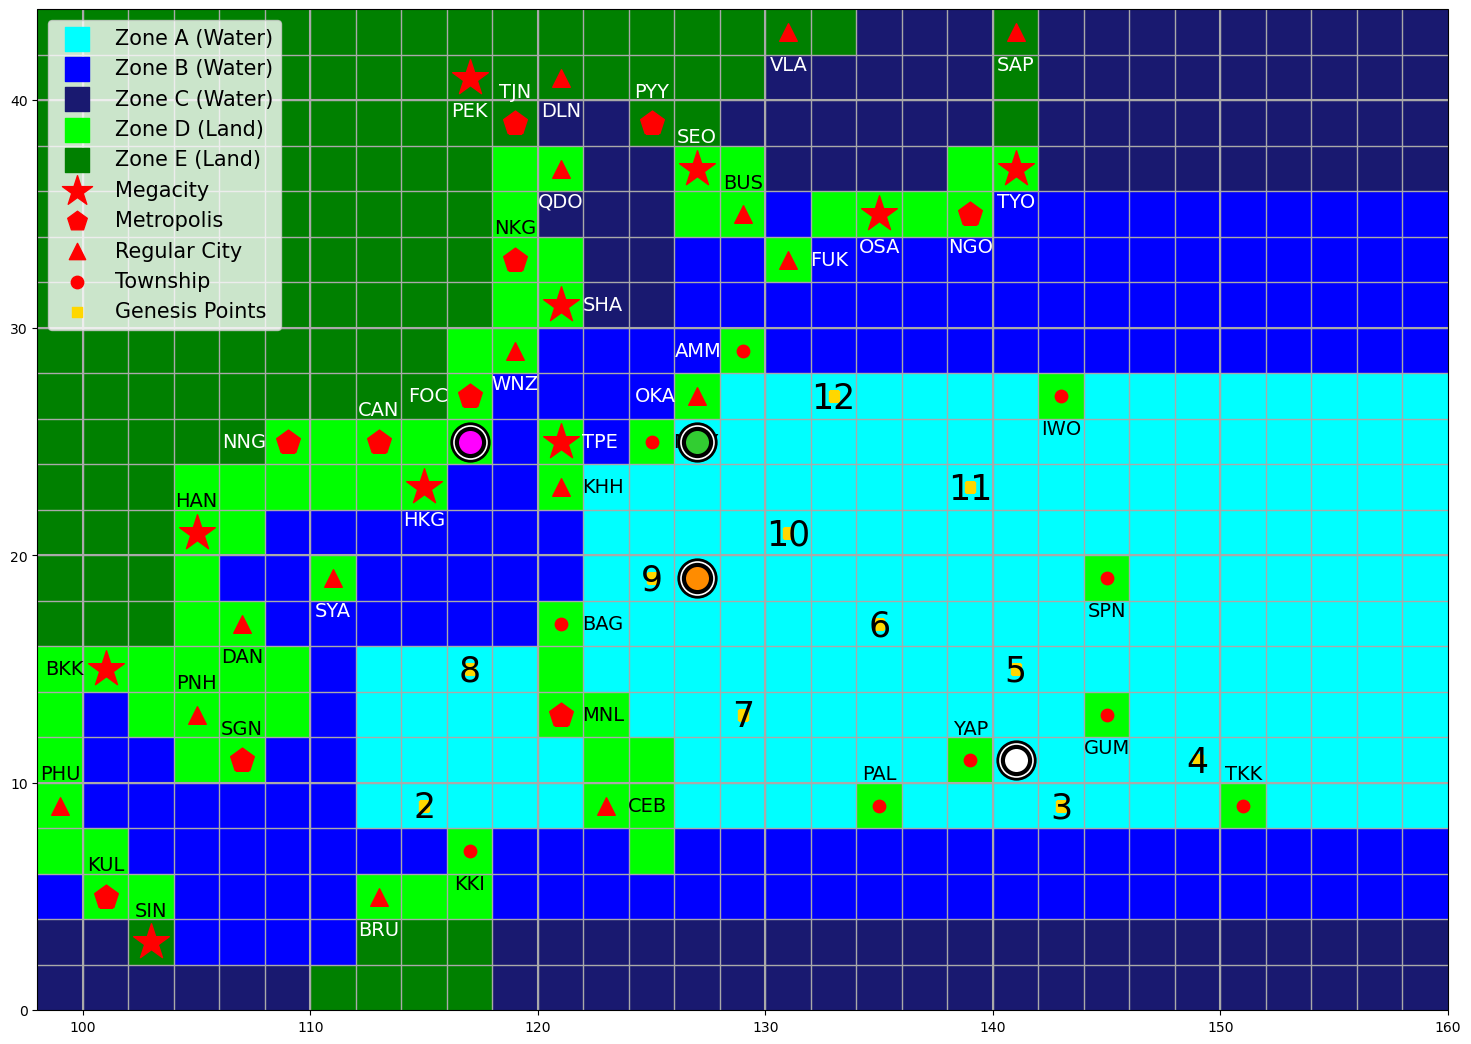

In [63]:
Run_Round(3, 4, Player_Data, Game_State, Player_Data_History, Game_State_History)

In [ ]:
Run_Round(4, 1, Player_Data, Game_State, Player_Data_History, Game_State_History)

In [ ]:
Run_Round(4, 2, Player_Data, Game_State, Player_Data_History, Game_State_History)

In [ ]:
Run_Round(4, 3, Player_Data, Game_State, Player_Data_History, Game_State_History)

In [ ]:
Run_Round(4, 4, Player_Data, Game_State, Player_Data_History, Game_State_History)